# CNN2 pigmentation classifier: DITA alignment & mask-value comparison

Compares five CNN2 pigmentation-binary checkpoints, all trained on the exact same
dataset/architecture (up to the input-row count) and hyperparameters, differing only in how the
input tensor is built:

- **No alignment** (`tensor_layout="raw_center_crop"`): each individual's AlphaGenome
  prediction is simply center-cropped at the same reference-relative window position for
  everyone -- no per-individual or cohort-wide INDEL coordinate correction at all
  (`configs/predictors/genotype_based/pigmentation/pigmentation_binary_no_alignment.yaml`).
- **DITA masks 0/1** (`tensor_layout="haplotype_channels"`, `alignment_mapping="bcftools_chain"`,
  `feature_mode="signals_and_masks"`, `indel_mask_positive_value=1.0`): DITA (Dynamic INDEL
  Tensor Alignment) -- a cohort-wide "expanded axis" built once per gene across the whole
  selected sample set, wide enough to fit every INDEL seen in the cohort -- plus 4 explicit
  INDEL/SNP location mask channels per gene per haplotype (insertion, deletion, valid, SNP) on
  top of the aligned signal, marked at the default binary value 1.0
  (`configs/predictors/genotype_based/pigmentation/pigmentation_binary_all_masks.yaml`).
- **DITA masks 0/0.5**, **DITA masks 0/0.25** -- identical to DITA masks 0/1 except the 4 mask
  channels mark positions with 0.5/0.25 instead of 1.0 (unmarked positions always stay at 0.0),
  via the new `indel_mask_positive_value` config field
  (`configs/predictors/genotype_based/pigmentation/pigmentation_binary_dita_masks_0_5.yaml`,
  `..._0_25.yaml`). A mask-magnitude sweep: does softening the explicit variant-location channels
  relative to the (post-log-normalization) AlphaGenome signal change accuracy or what the CNN
  attends to? (A fourth value, 0/0.125, was also configured (`..._0_125.yaml`) but dropped from
  training/this comparison to save time -- the config file is still there if it's revisited.)
- **DITA no masks** (`tensor_layout="haplotype_channels"`, `alignment_mapping="bcftools_chain"`,
  `feature_mode="signals_only"`): same DITA alignment as the three models above, but with no
  INDEL/SNP mask channels at all -- only the aligned AlphaGenome signal
  (`configs/predictors/genotype_based/pigmentation/pigmentation_binary.yaml`).

"No alignment" vs. the DITA models isolates the effect of *how* (or whether) AlphaGenome
predictions get mapped onto a coordinate axis that corrects for INDELs; the DITA mask sweep
instead isolates the effect of *what* the CNN is allowed to see (raw signal only vs. signal +
explicit variant-location channels, at three different channel magnitudes), holding the DITA
alignment fixed. `bcftools_chain`'s DITA alignment was smoke-tested against an earlier
per-individual realignment method before training (see `tests/test_reference_realign_mapper.py`
and the ad hoc real-data check that found Pearson r=1.0000 between the two methods' tensors for
real samples, with divergence limited to a handful of positions exactly at INDEL loci) -- this
notebook is about comparing the *trained models*, not re-litigating the alignment math itself.

Sections:
1. Load all five configs
2. Load data + all five trained CNN2 checkpoints
3. Predictions on the held-out test split (accuracy / confusion matrix, side by side)
4. DeepLIFT attributions (per-class mean, reusing `analysis.interpretability.DeepLIFT`)
5. Visualization of each model's mean attribution map
6. Attribution comparison across the five models (the one genuinely new piece of code here --
   everything else reuses existing interpretability infra)
7. Top attribution windows, and whether they shift between models
8. DeepLIFT attribution vs. GTF exon structure -- does the model attend to exons?


In [60]:
%matplotlib inline
import io
import json
import os
import sys
from pathlib import Path

REPO_ROOT = Path("/home/breno/I2CA/genomics")
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))
os.chdir(REPO_ROOT)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
import ipywidgets as widgets
from sklearn.metrics import confusion_matrix, classification_report

from genomics.predictors.genotype_based.config import load_config, generate_experiment_name, get_experiment_runs_dir
from genomics.predictors.genotype_based.data.pipeline import prepare_data
from genomics.predictors.genotype_based.models import CNN2AncestryPredictor
from genomics.predictors.genotype_based.analysis.interpretability import (
    DeepLIFT,
    summarize_deeplift_by_track,
    find_top_deeplift_windows,
    build_haplotype_track_layout,
)
from genomics.predictors.genotype_based.analysis.run_deeplift import _plot_mean_deeplift

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [61]:
def render_carousel(figures, labels=None, dpi=140):
    """Browse a list of already-built matplotlib Figures one at a time via Prev/Next buttons.

    Renders each Figure to PNG bytes up front and drives a plain `ipywidgets.Image` by updating
    its `.value` trait on click. An earlier version pushed `display(fig)` into an
    `ipywidgets.Output()` each step instead -- that works in JupyterLab/classic notebook, but VS
    Code's notebook renderer doesn't reliably show rich display data (e.g. PNGs) added to an
    Output widget after it's already mounted, so the Prev/Next buttons and counter label appeared
    (plain widget traits) while the figure itself never did. Updating an Image widget's `.value`
    is a normal trait sync and renders correctly there. Figures must have been created with
    `plt.close(fig)` called right after building them.
    """
    if not figures:
        print("(no figures to display)")
        return
    labels = list(labels) if labels is not None else [str(i) for i in range(len(figures))]
    assert len(labels) == len(figures)

    def _to_png_bytes(fig):
        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight")
        return buf.getvalue()

    frames = [_to_png_bytes(fig) for fig in figures]

    state = {"index": 0}
    image = widgets.Image(format="png")
    counter = widgets.Label()

    def render():
        state["index"] %= len(figures)
        counter.value = f"{labels[state['index']]}  ({state['index'] + 1}/{len(figures)})"
        image.value = frames[state["index"]]

    def step(delta):
        def _handler(_):
            state["index"] += delta
            render()
        return _handler

    prev_button = widgets.Button(description="< Prev")
    next_button = widgets.Button(description="Next >")
    prev_button.on_click(step(-1))
    next_button.on_click(step(1))

    display(widgets.HBox([prev_button, counter, next_button]), image)
    render()


## Section 1 -- Load all five configs

Each experiment directory is derived from `generate_experiment_name`, which encodes the
`tensor_layout`/`alignment_mapping` tag and the `feature_mode`/mask-flags/`indel_mask_positive_value`
tag, so all five configs resolve to distinct, non-colliding on-disk directories automatically. Two
of the five (`dita_masks_1` and `dita_no_masks`) reuse checkpoints/caches that already existed
before this comparison was extended (they're exactly `pigmentation_binary_all_masks.yaml` and
`pigmentation_binary.yaml`, unchanged) -- only `no_alignment`, `dita_masks_0.5`, and
`dita_masks_0.25` are new training runs (`dita_masks_0.125` was configured but dropped from the
sweep before training to save time).


In [62]:
CONFIG_PATHS = {
    "no_alignment": REPO_ROOT / "configs/predictors/genotype_based/pigmentation/pigmentation_binary_no_alignment.yaml",
    "dita_masks_1": REPO_ROOT / "configs/predictors/genotype_based/pigmentation/pigmentation_binary_all_masks.yaml",
    "dita_masks_0.5": REPO_ROOT / "configs/predictors/genotype_based/pigmentation/pigmentation_binary_dita_masks_0_5.yaml",
    "dita_masks_0.25": REPO_ROOT / "configs/predictors/genotype_based/pigmentation/pigmentation_binary_dita_masks_0_25.yaml",
    "dita_no_masks": REPO_ROOT / "configs/predictors/genotype_based/pigmentation/pigmentation_binary.yaml",
}

configs = {name: load_config(path) for name, path in CONFIG_PATHS.items()}

# Every shipped config uses loading_strategy="preload" (right for training -- avoids per-batch
# disk I/O), but that means fully materializing train+val+test in RAM. Summed across all 5
# configs that's ~120GB on disk, right at this machine's 121GB of RAM -- loading them one at a
# time still peaks there since datasets/loaders below keep every model's data resident for the
# rest of the notebook, and it OOM-killed the kernel with no traceback partway through Section 3.
# This notebook only ever needs the (much smaller) test split, so force "lazy" loading here --
# in-memory only, the YAML training configs on disk are untouched.
for _config in configs.values():
    _config.data_loading.loading_strategy = "lazy"

EXPERIMENT_DIRS = {
    name: get_experiment_runs_dir(config) / generate_experiment_name(config)
    for name, config in configs.items()
}

for name, config in configs.items():
    di = config.dataset_input
    print(f"{name}: tensor_layout={di.tensor_layout!r} alignment_mapping={di.alignment_mapping!r} "
          f"feature_mode={di.feature_mode!r} indel_mask_positive_value={di.indel_mask_positive_value}")
    print(f"  experiment_dir={EXPERIMENT_DIRS[name]}")
    print(f"  checkpoint exists: {(EXPERIMENT_DIRS[name] / 'models' / 'best_accuracy.pt').exists()}")


no_alignment: tensor_layout='raw_center_crop' alignment_mapping='bcftools_chain' feature_mode='signals_only' indel_mask_positive_value=1.0
  experiment_dir=results/genotype_based_predictor/runs/cnn2_pigmentation_rna_seq_H1+H2_raw_center_crop_32768_log_s1k6x32f16_s2f32_s3f64_gpavg_fc256_L100-40_relu_0.5_adam
  checkpoint exists: True
dita_masks_1: tensor_layout='haplotype_channels' alignment_mapping='bcftools_chain' feature_mode='signals_and_masks' indel_mask_positive_value=1.0
  experiment_dir=results/genotype_based_predictor/runs/cnn2_pigmentation_rna_seq_H1+H2_haplotype_channels_signals_and_masks-valid-snp_32768_log_s1k10x32f16_s2f32_s3f64_gpavg_fc256_L100-40_relu_0.5_adam
  checkpoint exists: True
dita_masks_0.5: tensor_layout='haplotype_channels' alignment_mapping='bcftools_chain' feature_mode='signals_and_masks' indel_mask_positive_value=0.5
  experiment_dir=results/genotype_based_predictor/runs/cnn2_pigmentation_rna_seq_H1+H2_haplotype_channels_signals_and_masks-valid-snp-val0p5_

## Section 2 -- Load data + all five trained CNN2 checkpoints

`prepare_data` transparently reuses each config's already-materialized processed-tensor cache
(each combination of `tensor_layout`/`alignment_mapping`/`feature_mode`/mask flags/
`indel_mask_positive_value` lands in a distinct cache directory automatically, since they're all
part of the cache's view hash -- no manual cache-path bookkeeping needed). Note the three
`dita_masks_*` configs have a wider input tensor (110 rows/haplotype vs. 66 for `no_alignment`/
`dita_no_masks`, since they add 4 mask channels per gene) and a different Stage1 kernel;
`no_alignment` additionally uses a different tensor layout entirely (`raw_center_crop` instead of
`haplotype_channels`), though its row count and Stage1 kernel match `dita_no_masks`'s
signals-only layout exactly (both are 2 strands x 3 ontology terms = 6 channels/gene/haplotype).
`build_model` picks up the right shape from each config independently.


In [63]:
def build_model(config, dataset):
    input_shape = dataset.get_input_shape()
    num_classes = dataset.get_num_classes()
    if config.model.type.upper() != "CNN2":
        raise ValueError(f"This notebook only compares CNN2 checkpoints, got {config.model.type}")
    return CNN2AncestryPredictor(config, input_shape, num_classes)


def load_checkpoint(model, checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    state_dict = checkpoint.get("model_state_dict", checkpoint)
    model.load_state_dict(state_dict)
    model.eval()
    return model


datasets = {}
loaders = {}
models = {}

for name, config in configs.items():
    experiment_dir = EXPERIMENT_DIRS[name]
    full_ds, train_loader, val_loader, test_loader = prepare_data(config, experiment_dir)
    datasets[name] = full_ds
    loaders[name] = {"train": train_loader, "val": val_loader, "test": test_loader}

    model = build_model(config, full_ds).to(device)
    checkpoint_path = experiment_dir / "models" / "best_accuracy.pt"
    models[name] = load_checkpoint(model, checkpoint_path)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"{name}: loaded {checkpoint_path.name} ({n_params:,} params), test set size = {len(test_loader.dataset)}")

class_names = datasets["dita_no_masks"].get_class_names()
print(f"class_names={class_names}")

# prepare_data's dataset-report step (genomics.core.metrics.save_classification_plots)
# forces the matplotlib backend to Agg (matplotlib.use("Agg", force=True)) as a side effect,
# which silently breaks plt.show() in every cell below. Re-enable the inline backend now that
# data loading is done.
%matplotlib inline


✓ Cache válido e compatível

Cache encontrado: rna_seq_H1+H2_32768_ds1_log_shuf_ont3_viewbfab64270522

Cache: 2026-08-16T11:39:41.844500 | 1072 amostras

Preparando train_data.pt...

✓ 761 samples (lazy)

...

• Stage 3: 64 filters, kernel=(1, 5), stride=(1, 2), padding=(0, 2) → 64 x 22 x 256

• Global Pool (avg): kernel=(1, 256) → 64 x 22 x 1

• FC: 1408 → 256 → 2

• Params: 377,202

dita_no_masks: loaded best_accuracy.pt (377,202 params), test set size = 162
class_names=['strong pigmentation', 'weak pigmentation']


## Section 3 -- Predictions on the held-out test split

All six models are evaluated on their own config's test split (same `random_seed`/
`family_split_mode` in every config, so the underlying individuals are the same -- only the
input tensors differ). Accuracy here should be directly comparable to each run's own
`val_best_accuracy_results.json` as a sanity cross-check.


In [64]:
def collect_predictions(model, loader):
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in loader:
            features, targets = batch[0], batch[1]
            logits = model(features.to(device))
            preds = logits.argmax(dim=1).cpu().numpy()
            y_true.extend(targets.numpy().tolist())
            y_pred.extend(preds.tolist())
    return np.array(y_true), np.array(y_pred)


predictions = {}
for name in configs:
    y_true, y_pred = collect_predictions(models[name], loaders[name]["test"])
    predictions[name] = {"y_true": y_true, "y_pred": y_pred}
    acc = (y_true == y_pred).mean()
    print(f"=== {name} (test, n={len(y_true)}) === accuracy={acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names))


=== no_alignment (test, n=162) === accuracy=0.9259
                     precision    recall  f1-score   support

strong pigmentation       0.96      0.93      0.95       115
  weak pigmentation       0.84      0.91      0.88        47

           accuracy                           0.93       162
          macro avg       0.90      0.92      0.91       162
       weighted avg       0.93      0.93      0.93       162

=== dita_masks_1 (test, n=162) === accuracy=1.0000
                     precision    recall  f1-score   support

strong pigmentation       1.00      1.00      1.00       115
  weak pigmentation       1.00      1.00      1.00        47

           accuracy                           1.00       162
          macro avg       1.00      1.00      1.00       162
       weighted avg       1.00      1.00      1.00       162

=== dita_masks_0.5 (test, n=162) === accuracy=1.0000
                     precision    recall  f1-score   support

strong pigmentation       1.00      1.00     

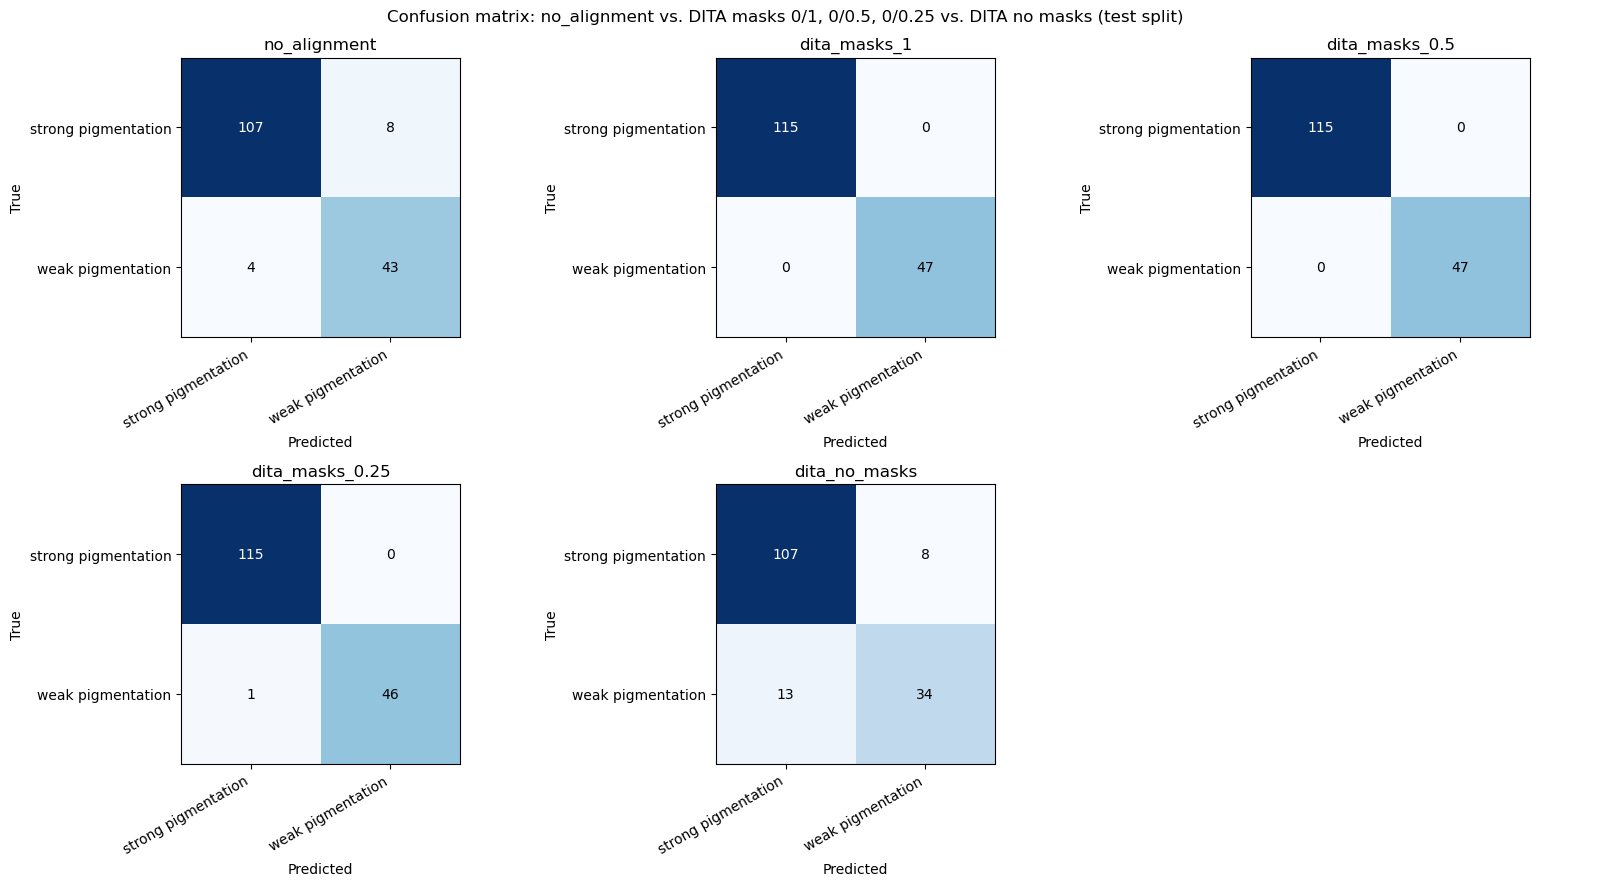

In [65]:
n_models = len(configs)
ncols = 3
nrows = -(-n_models // ncols)  # ceil
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.5 * nrows))
axes = axes.flatten()
for ax, name in zip(axes, configs):
    cm = confusion_matrix(predictions[name]["y_true"], predictions[name]["y_pred"])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(name)
    ax.set_xticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=30, ha="right")
    ax.set_yticks(range(len(class_names)))
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
for ax in axes[n_models:]:
    ax.axis("off")
fig.suptitle("Confusion matrix: no_alignment vs. DITA masks 0/1, 0/0.5, 0/0.25 vs. DITA no masks (test split)")
fig.tight_layout()
plt.show()


## Section 4 -- DeepLIFT attributions (per-class mean)

Reuses `DeepLIFT.generate_class_mean` directly (the same call `analysis/run_deeplift.py`'s CLI
makes) -- it averages DeepLIFT attributions over every test-split sample of a given true class,
in one call per (alignment method, class). `baseline_type="mean"` (the training-set mean input,
not an all-zeros tensor) is used here: this implementation is Gradient x (input - baseline), not
the true DeepLIFT Rescale rule, so with a zeros baseline the attribution collapses to
gradient(x) * x -- near-perfectly proportional to raw input magnitude, dominated by that scale
artifact rather than class-discriminative signal. Using the dataset-mean input as baseline instead
makes `delta = input - baseline` reflect deviation from a typical sample, decoupling the
attribution from pure input magnitude.


In [66]:
deeplift_results = {}  # name -> {class_idx: {"class_name":..., "mean_attr":..., "mean_input":..., "n":...}}

for name in configs:
    model = models[name]
    test_dataset = loaders[name]["test"].dataset
    deeplift = DeepLIFT(model)

    per_class = {}
    for class_idx, class_name in enumerate(class_names):
        mean_attr, mean_input, n = deeplift.generate_class_mean(
            class_idx, dataset=test_dataset, baseline_type="mean",
        )
        if n == 0:
            continue
        per_class[class_idx] = {
            "class_name": class_name,
            "mean_attr": mean_attr,
            "mean_input": mean_input,
            "n": n,
        }
        print(f"{name} / {class_name}: DeepLIFT computed over {n} test samples")
    deeplift_results[name] = per_class


Calculando baseline (média do dataset)...

/home/breno/miniforge3/envs/genomics/lib/python3.10/site-packages/captum/attr/_core/deep_lift.py:296: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/home/breno/miniforge3/envs/genomics/lib/python3.10/site-packages/captum/log/dummy_log.py:54: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  return func(*args, **kwargs)


no_alignment / strong pigmentation: DeepLIFT computed over 115 test samples
no_alignment / weak pigmentation: DeepLIFT computed over 47 test samples


Calculando baseline (média do dataset)...

dita_masks_1 / strong pigmentation: DeepLIFT computed over 115 test samples
dita_masks_1 / weak pigmentation: DeepLIFT computed over 47 test samples


...

dita_masks_0.5 / strong pigmentation: DeepLIFT computed over 115 test samples
dita_masks_0.5 / weak pigmentation: DeepLIFT computed over 47 test samples


Calculando baseline (média do dataset)...

dita_masks_0.25 / strong pigmentation: DeepLIFT computed over 115 test samples
dita_masks_0.25 / weak pigmentation: DeepLIFT computed over 47 test samples


Calculando baseline (média do dataset)...

dita_no_masks / strong pigmentation: DeepLIFT computed over 115 test samples
dita_no_masks / weak pigmentation: DeepLIFT computed over 47 test samples


## Section 5 -- Visualization of each model's mean attribution map

Reuses `analysis.run_deeplift._plot_mean_deeplift` directly (a plain-data function, no CLI-args
coupling) -- one figure per (alignment method, class).


In [67]:
FIG_DIR = REPO_ROOT / "notebooks" / ".cache" / "genotype_cnn_alignment_deeplift"
FIG_DIR.mkdir(parents=True, exist_ok=True)

for name in configs:
    config = configs[name]
    for class_idx, payload in deeplift_results[name].items():
        top_windows = find_top_deeplift_windows(payload["mean_attr"], config, window_size=512, top_k=20)
        out_path = FIG_DIR / f"deeplift_mean_{name}_{payload['class_name'].replace(' ', '_')}.png"
        _plot_mean_deeplift(
            mean_input=payload["mean_input"],
            mean_attr=payload["mean_attr"],
            top_windows=top_windows,
            config=config,
            class_label=payload["class_name"],
            split="test",
            num_samples=payload["n"],
            output_path=out_path,
        )
        print(f"saved {out_path}")


saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/deeplift_mean_no_alignment_strong_pigmentation.png
saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/deeplift_mean_no_alignment_weak_pigmentation.png
saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/deeplift_mean_dita_masks_1_strong_pigmentation.png
saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/deeplift_mean_dita_masks_1_weak_pigmentation.png
saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/deeplift_mean_dita_masks_0.5_strong_pigmentation.png
saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/deeplift_mean_dita_masks_0.5_weak_pigmentation.png
saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/deeplift_mean_dita_masks_0.25_strong_pigmentation.png
saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_dee

## Section 6 -- Attribution comparison across all five models

The one genuinely new piece of visualization in this notebook: merge each model's per-gene mean
absolute attribution (`summarize_deeplift_by_track`, aggregated per gene/haplotype) and compare
side by side across all five models. A gene where the models diverge a lot is a candidate for
having its CNN2 decision driven either by INDEL-adjacent positions (where `no_alignment` and the
DITA models genuinely disagree -- `no_alignment` has no coordinate correction at all, while DITA's
expanded axis repairs INDEL-driven coordinate drift) or by the mask channels' presence/magnitude
changing what the model attends to (`dita_masks_1`/`dita_masks_0.5`/`dita_masks_0.25` vs.
`dita_no_masks`, same DITA alignment, different input features/magnitudes).


In [68]:
def gene_level_attribution(name, class_idx):
    config = configs[name]
    payload = deeplift_results[name][class_idx]
    track_rows = summarize_deeplift_by_track(payload["mean_attr"], config)
    df = pd.DataFrame(track_rows)
    gene_df = df.groupby(["haplotype", "gene_name"], as_index=False)["mean_abs_attr"].mean()
    gene_df["model"] = name
    return gene_df


TARGET_CLASS_IDX = class_names.index("strong pigmentation") if "strong pigmentation" in class_names else 0
MODEL_NAMES = list(configs)

comparison_df = pd.concat(
    [gene_level_attribution(name, TARGET_CLASS_IDX) for name in MODEL_NAMES],
    ignore_index=True,
)

pivot_df = comparison_df.pivot_table(
    index=["gene_name", "haplotype"], columns="model", values="mean_abs_attr"
).reset_index()
pivot_df["range"] = pivot_df[MODEL_NAMES].max(axis=1) - pivot_df[MODEL_NAMES].min(axis=1)
pivot_df = pivot_df.sort_values("range", ascending=False)
pivot_df


model,gene_name,haplotype,dita_masks_0.25,dita_masks_0.5,dita_masks_1,dita_no_masks,no_alignment,range
12,SLC24A5,H1,5.467017e-07,1.038011e-06,5.960479e-07,1.721013e-07,8.840614e-06,8.668513e-06
4,HERC2,H1,3.080885e-06,2.390457e-06,1.992422e-06,1.089751e-08,7.635722e-06,7.624824e-06
14,SLC45A2,H1,8.903579e-07,2.074322e-06,2.943988e-06,4.789850e-08,3.885804e-06,3.837905e-06
7,MC1R,H2,2.792380e-06,3.806556e-06,2.928511e-06,4.358427e-08,NaN,3.762971e-06
18,TYR,H1,1.673796e-06,1.621607e-06,1.585308e-06,6.474419e-08,3.735758e-06,3.671014e-06
5,HERC2,H2,3.408451e-06,3.036784e-06,2.376221e-06,6.003283e-09,NaN,3.402448e-06
15,SLC45A2,H2,1.085137e-06,2.451710e-06,3.313944e-06,5.787018e-08,NaN,3.256073e-06
9,MFSD12,H2,2.289451e-06,3.319812e-06,1.973977e-06,8.555630e-08,NaN,3.234256e-06
8,MFSD12,H1,2.041837e-06,3.116342e-06,1.413445e-06,1.002015e-07,3.700303e-07,3.016141e-06
6,MC1R,H1,2.105174e-06,2.745157e-06,2.264648e-06,3.502878e-08,1.179484e-06,2.710128e-06


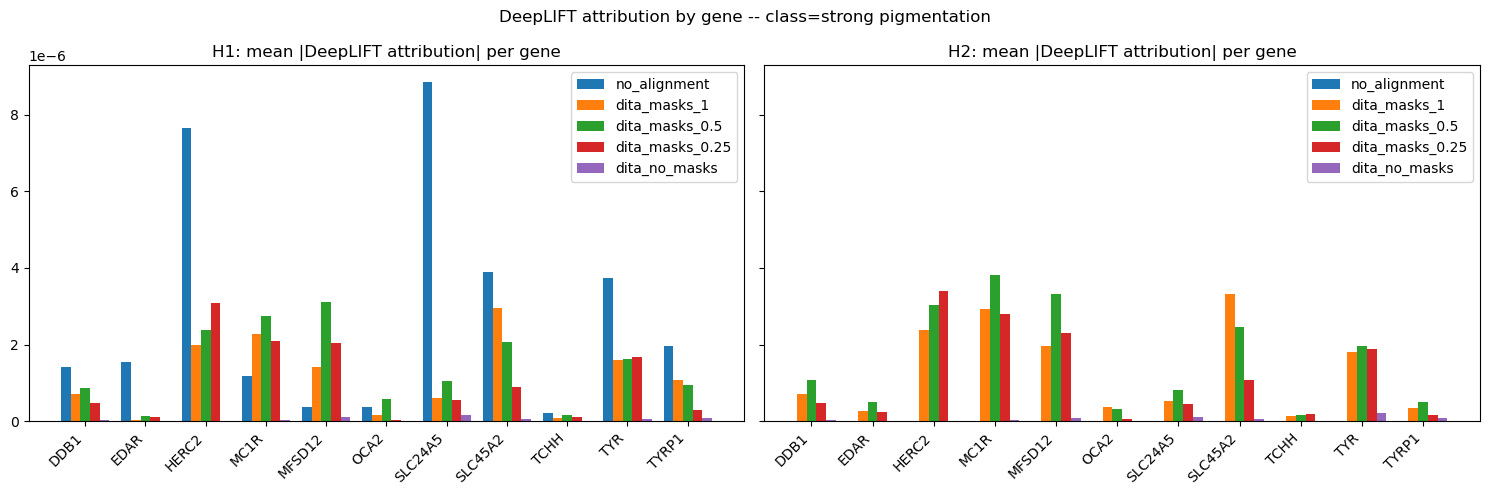

In [69]:
genes_order = sorted(pivot_df["gene_name"].unique())
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
n_models = len(MODEL_NAMES)
width = 0.8 / n_models
for ax, hap in zip(axes, ["H1", "H2"]):
    sub = pivot_df[pivot_df["haplotype"] == hap].set_index("gene_name").reindex(genes_order)
    x = np.arange(len(genes_order))
    for i, name in enumerate(MODEL_NAMES):
        offset = (i - (n_models - 1) / 2) * width
        ax.bar(x + offset, sub[name], width, label=name)
    ax.set_xticks(x)
    ax.set_xticklabels(genes_order, rotation=45, ha="right")
    ax.set_title(f"{hap}: mean |DeepLIFT attribution| per gene")
    ax.legend()
fig.suptitle(f"DeepLIFT attribution by gene -- class={class_names[TARGET_CLASS_IDX]}")
fig.tight_layout()
plt.show()


## Section 7 -- Top attribution windows: do they shift between alignment methods?

Lists each model's highest-attribution 512bp windows and flags genes where the two alignment
methods' top windows land in meaningfully different places -- most informative for INDEL-bearing
loci like `HERC2`/`OCA2`, where the two realignment strategies are expected to genuinely differ.


In [70]:
top_windows = {}
for name in configs:
    config = configs[name]
    payload = deeplift_results[name][TARGET_CLASS_IDX]
    windows = find_top_deeplift_windows(payload["mean_attr"], config, window_size=512, top_k=15)
    top_windows[name] = pd.DataFrame(windows)[["gene_name", "haplotype", "window_center", "mean_abs_attr"]]
    print(f"=== {name}: top windows, class={class_names[TARGET_CLASS_IDX]} ===")
    display(top_windows[name])


=== no_alignment: top windows, class=strong pigmentation ===


,gene_name,haplotype,window_center,mean_abs_attr
0,SLC24A5,H1,26936,0.000107
1,SLC24A5,H1,26935,0.000107
2,SLC24A5,H1,26934,0.000107
3,SLC24A5,H1,26933,0.000107
4,SLC24A5,H1,26932,0.000107
5,SLC24A5,H1,26931,0.000107
6,SLC24A5,H1,26930,0.000107
7,SLC24A5,H1,26929,0.000107
8,SLC24A5,H1,26937,0.000107
9,SLC24A5,H1,26928,0.000107


=== dita_masks_1: top windows, class=strong pigmentation ===


,gene_name,haplotype,window_center,mean_abs_attr
0,SLC45A2,H2,19452,0.000277
1,SLC45A2,H2,19449,0.000277
2,SLC45A2,H2,19451,0.000277
3,SLC45A2,H2,19453,0.000277
4,SLC45A2,H2,19445,0.000277
5,SLC45A2,H2,19454,0.000277
6,SLC45A2,H2,19450,0.000277
7,SLC45A2,H2,19455,0.000277
8,SLC45A2,H2,19446,0.000277
9,SLC45A2,H2,19447,0.000277


=== dita_masks_0.5: top windows, class=strong pigmentation ===


,gene_name,haplotype,window_center,mean_abs_attr
0,HERC2,H2,4890,0.000145
1,HERC2,H2,4879,0.000145
2,HERC2,H2,4888,0.000145
3,HERC2,H2,4889,0.000145
4,HERC2,H2,4883,0.000145
5,HERC2,H2,4891,0.000145
6,HERC2,H2,4887,0.000145
7,HERC2,H2,4892,0.000145
8,HERC2,H2,4884,0.000145
9,HERC2,H2,4885,0.000145


=== dita_masks_0.25: top windows, class=strong pigmentation ===


,gene_name,haplotype,window_center,mean_abs_attr
0,SLC45A2,H2,19452,0.00025
1,SLC45A2,H2,19449,0.00025
2,SLC45A2,H2,19451,0.00025
3,SLC45A2,H2,19453,0.00025
4,SLC45A2,H2,19445,0.00025
5,SLC45A2,H2,19454,0.00025
6,SLC45A2,H2,19450,0.00025
7,SLC45A2,H2,19455,0.00025
8,SLC45A2,H2,19446,0.00025
9,SLC45A2,H2,19447,0.00025


=== dita_no_masks: top windows, class=strong pigmentation ===


,gene_name,haplotype,window_center,mean_abs_attr
0,SLC24A5,H1,18983,0.000005
1,SLC24A5,H1,18982,0.000005
2,SLC24A5,H1,18980,0.000005
3,SLC24A5,H1,18981,0.000005
4,SLC24A5,H1,18984,0.000005
5,SLC24A5,H1,18979,0.000005
6,SLC24A5,H1,18974,0.000005
7,SLC24A5,H1,18977,0.000005
8,SLC24A5,H1,18978,0.000005
9,SLC24A5,H1,18985,0.000005


## Section 8 -- DeepLIFT attribution vs. GTF exon structure

Does the model actually weight exon positions more than intronic/UTR positions, or is it just
picking up on some other pattern (e.g. coverage-level shifts unrelated to exon/intron structure)?
This overlays the mean **signed** DeepLIFT attribution curve of the model with the exact
reference-coordinate axis (`no_alignment` -- signal tracks only, see the coordinate-mapping note
below for why) against the gene's GENCODE v46 exon structure.

**Sign convention.** Each curve is `attrs.mean(dim=(haplotype, signal_track))` with no `.abs()`
applied at any stage -- signed, cross-sample-averaged attribution, just reduced over
haplotypes/tracks instead of taking a magnitude first (see Section 4's markdown for the
Rescale-rule derivation). A region sitting **above** the zero line consistently pushes the
model's output *toward* the curve's labeled class; **below** zero pushes *away* from it; near
zero means the model's output for that class isn't sensitive to that position (either because the
input there is near-baseline/zero coverage, or because the model genuinely doesn't weight it).
Because sign survived the per-sample averaging, a non-trivial value here (positive or negative)
reflects a *consistent* effect across the underlying population, not per-sample noise.

**Coordinate mapping and its limits.** `no_alignment` crops each individual's raw AlphaGenome
prediction at the same reference-relative window position for everyone (`_extract_center_raw` in
`data/processed_dataset.py`) -- it does no per-individual or cohort-wide indel-driven axis
correction at all, so position *i* in its window maps *exactly* onto a known reference position,
no approximation. The DITA models (`dita_masks_1`/`dita_masks_0.5`/`dita_masks_0.25`/`dita_no_masks`) instead sit
on a cohort-wide "expanded axis" that's stretched
wherever any selected individual carries an INSERTION, so their window positions drift from true
reference coordinates by a few bp per INDEL locus. `no_alignment`'s crop and the DITA axis both
start from the identical reference window per gene and use the same centering math (see
`window_genomic_axis` below), and the notebook-level pre-training smoke test found the
aligned/unaligned tensors match almost exactly except at a handful of INDEL-adjacent positions --
so this section plots only `no_alignment`'s attribution curve, on a nominal reference-coordinate
x-axis that is exact for it by construction. The DITA models' curves would sit on that same axis
only approximately (drifting near INDELs), so they're left out here to avoid implying a precision
the DITA alignment doesn't actually have at this per-base resolution.

Reuses `build_haplotype_track_layout` (the same per-gene/track row map `summarize_deeplift_by_track`
uses internally) to pick out just the signal-track rows for one gene, averaged over both
haplotypes (but *not* averaged across tracks -- each of the 3 ontology terms x 2 strands gets its
own set of panels, since collapsing them together would hide track-specific patterns), then
lightly smoothed (centered moving average, matching the `window_size=512` granularity Section 7
already uses) for legibility -- raw per-base values are too noisy to eyeball directly.

**Each track gets two stacked panels**: the actual (normalized, log1p-transformed) RNA-seq signal
fed to the model on top, and its signed DeepLIFT attribution directly below -- so it's possible to
see, for example, whether an attribution peak lines up with real coverage or with a near-zero
input region (relevant to the "AlphaGenome's RNA-seq input is itself exon-biased" caveat discussed
earlier: intronic positions have little real coverage to begin with, so DeepLIFT has little to
attribute there regardless of what the model "chooses" to weight).

**Exon overlay only on the sense strand.** A gene's exons are annotated on one specific strand
(from GENCODE); overlaying them on the antisense-strand panels too would imply an exon/intron
structure that doesn't exist for that strand's transcription. So the green exon shading (and the
exon-location row at the bottom of each column) is drawn only under the column matching the
gene's own annotated strand -- the other column is left unshaded.


**Update -- three-way class comparison on the signal panels.** The RNA-seq signal panels plot
three curves: the class-mean of `class_names[TARGET_CLASS_IDX]` individuals (dark), the class-mean
of the other class (light) -- both already computed in Section 4's
`deeplift_results[...]["mean_input"]`, no extra data pass -- and their n-weighted combination
across the whole test split (black, dashed). Wherever the two class means visually overlap (a real
risk: RNA-seq coverage shape is driven mostly by the underlying exon structure, which both classes
share), the gap between them is also shaded directly on the panel (dark where the
`strong pigmentation` mean sits above `weak pigmentation`, light the other way) so a difference too
small to see as two overlapping lines is still visible as a colored sliver. Green dotted/dash-dot
vertical lines mark the gene's transcription start/end (`TSS`/`TES`, from the same MANE-transcript
exon extraction as the exon shading -- the first/last exon boundary, flipped for the `-` strand
since transcription then runs right-to-left), on the sense-strand column only, for the same reason
the exon shading is sense-only.

**If the shaded difference is still too subtle to read at this panel's y-scale**, other options
worth trying (not implemented here, to keep this section's output size manageable): a zoomed
sub-window around Section 7's top-attribution windows for the gene in question, a separate
difference-only subplot with its own y-scale instead of sharing the signal panel's, or normalizing
the difference curve by the population's own variability at each position -- which is exactly what
Section 8.1 below does instead, by plotting each class's mean with a hatched +/-1 SD band: a
difference smaller than where the shaded bands overlap reads as "not clearly separated at this
position", while a difference the bands don't overlap at all reads as a consistent, population-wide
signal rather than a class-mean shift driven by a handful of outliers.

**Update -- own-class vs. cross-class attribution, four curves on one axis.** The attribution
panel now plots four curves instead of two, all sharing one axis so they're directly comparable:

- **own-class** (solid) -- a population's attribution toward its *own* class's output logit,
  already computed in Section 4's per-class loop
  (`deeplift_results[MODEL_NAME][class_idx]["mean_attr"]`, no new DeepLIFT pass): strong individuals
  toward the strong logit (solid dark), weak individuals toward the weak logit (solid light).
- **cross-class** (dashed) -- the *same two populations*' individuals explained toward the *other*
  class's output logit instead -- e.g. what, in a weak-pigmentation individual's input, would have
  pushed the model toward predicting strong pigmentation: weak individuals toward the strong logit
  (dashed dark), strong individuals toward the weak logit (dashed light). `generate_class_mean`
  couples sample selection and attribution target to the same class, so this pairing didn't exist
  yet: it needed the new `DeepLIFT.generate_class_mean_cross(sample_class_idx, target_class_idx,
  ...)` method and two additional DeepLIFT passes over `MODEL_NAME`'s test split (computed once,
  before the per-gene loop, in the code cell below).

Color always marks which logit is being explained (dark = toward strong, light = toward weak,
matching `CLASS_COLORS` -- reused as `CAGE_DARK_COLOR`/`CAGE_LIGHT_COLOR` for the dark/light
melanocyte curves in Section 9, so strong/weak pigmentation and dark/light melanocyte read as the
same two colors throughout the notebook); linestyle marks whether that's the population's own class
(solid) or the
counterfactual (dashed). Where a solid and its same-color dashed counterpart diverge, that position
is what distinguishes the two populations' actual classes in the model's eyes; where all four track
closely, the position pushes the model's output the same way regardless of population or target
class -- i.e. it isn't class-discriminative here. The per-track correlation table
(`corr(diff_signal, own_attribution)`) reports one row per population (weak, strong) per track,
each correlating the same strong-minus-weak signal difference curve against that population's
own-class curve.

In [71]:
import requests

from alphagenome.data import genome, gene_annotation
from alphagenome.data import transcript as transcript_utils

GTF_CACHE_DIR = REPO_ROOT / "notebooks" / ".cache" / "annotations"
GTF_URL = (
    "https://storage.googleapis.com/alphagenome/reference/gencode/"
    "hg38/gencode.v46.annotation.gtf.gz.feather"
)


def load_gtf(cache_dir: Path) -> pd.DataFrame:
    # Same cache location/URL as notebooks/utils/annotations.py's load_gtf, so this reuses
    # that notebook's ~tens-of-MB download if it already ran -- reimplemented inline (rather
    # than importing notebooks.utils) to keep this notebook's only dependency on the rest of
    # the repo scoped to genomics.*, matching every other cell here.
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache_path = cache_dir / "gencode.v46.annotation.gtf.gz.feather"
    if not cache_path.exists():
        r = requests.get(GTF_URL, timeout=120)
        r.raise_for_status()
        cache_path.write_bytes(r.content)
    return pd.read_feather(cache_path)


gtf = load_gtf(GTF_CACHE_DIR)
gtf_mane = gene_annotation.filter_to_mane_select_transcript(gene_annotation.filter_protein_coding(gtf))
gtf_protein_coding = gene_annotation.filter_protein_coding(gtf)
transcript_extractor_mane = transcript_utils.TranscriptExtractor(gtf_mane)
transcript_extractor_coding = transcript_utils.TranscriptExtractor(gtf_protein_coding)
gene_id_map = gtf.drop_duplicates("gene_name").set_index("gene_name")["gene_id"]
print(f"GTF loaded: {len(gtf):,} rows -- {gtf_mane['gene_name'].nunique():,} genes with a MANE Select transcript")


GTF loaded: 3,467,156 rows -- 19,226 genes with a MANE Select transcript


In [72]:
def window_genomic_axis(gene: str, window_center_size: int):
    '''Reference-coordinate window start/length, using the same centering formula
    `no_alignment`'s `_extract_center_raw` applies when building its training tensors -- see
    Section 8's markdown for why this axis is exact for that model and approximate for the DITA
    models (bcftools_chain-based expanded axis).'''
    meta_path = DATASET_DIR / "references" / "windows" / gene / "window_metadata.json"
    meta = json.loads(meta_path.read_text())
    chrom = meta["chromosome"]
    start_1based = int(meta["start"])
    end_1based = int(meta["end"])
    full_ref_length = end_1based - start_1based + 1

    size = min(window_center_size, full_ref_length)
    center_offset = full_ref_length // 2
    crop_start = max(0, center_offset - size // 2)
    crop_end = min(full_ref_length, crop_start + size)
    if crop_end - crop_start < size:
        crop_start = max(0, crop_end - size)

    window_start_0based = (start_1based - 1) + crop_start  # alphagenome genome.Interval is 0-based half-open
    local_length = crop_end - crop_start
    return chrom, window_start_0based, local_length


def gene_exon_local_boxes(gene: str, chrom: str, window_start_0based: int, local_length: int):
    interval = genome.Interval(chrom, window_start_0based, window_start_0based + local_length)
    target_gene_id = gene_id_map.get(gene)

    transcripts = transcript_extractor_mane.extract(interval)
    matched = [t for t in transcripts if t.gene_id == target_gene_id] if target_gene_id else transcripts
    if not matched:
        # Fallback for genes without a MANE Select tag in this GENCODE release: take the
        # protein-coding transcript with the most exons for this gene within the window.
        transcripts = [t for t in transcript_extractor_coding.extract(interval) if t.gene_id == target_gene_id]
        matched = [max(transcripts, key=lambda t: len(t.exons))] if transcripts else []

    boxes, strand = [], None
    for t in matched:
        strand = t.strand
        for exon in t.exons:
            s = max(0, exon.start - window_start_0based)
            e = min(local_length, exon.end - window_start_0based)
            if e > s:
                boxes.append((s, e))
    return sorted(boxes), strand


def gene_track_curves(tensor: torch.Tensor, config, gene: str) -> dict:
    '''Per-(ontology_curie, strand) curve for one gene from a (haplotype, row, L)-shaped tensor
    (either Section 4's signed mean_attr or its mean_input), averaged over both haplotypes only
    -- {(ontology_curie, strand): 1D curve}, same length as the window. Used both for the signed
    DeepLIFT attribution (no .abs() -- positive = pushes toward the target class, see Section 8
    markdown) and for the raw model-input RNA-seq signal itself.'''
    layout = build_haplotype_track_layout(config)
    rows = [r for r in layout if r["gene_name"] == gene and r["track_type"] == "signal"]
    t = tensor.detach().cpu()
    if t.ndim == 2:
        t = t.unsqueeze(0)
    return {
        (r["ontology_curie"], r["strand"]): t[:, r["row_index"], :].mean(dim=0).numpy()
        for r in rows
    }


def smooth(x: np.ndarray, window: int = 513) -> np.ndarray:
    if window <= 1:
        return x
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="same")


_class_input_stack_cache = {}


def collect_class_input_stack(name: str, class_idx: int) -> torch.Tensor:
    """Every test-split sample's raw input tensor (no gradients) for one model/class, stacked
    on a new leading sample axis -- the same per-class population `generate_class_mean` already
    averages down to `mean_input` in Section 4, kept here unaveraged so per-position std across
    individuals can be computed for the hatched bands in Section 8.1."""
    key = (name, class_idx)
    if key not in _class_input_stack_cache:
        dataset = loaders[name]["test"].dataset
        samples = [dataset[i][0] for i in range(len(dataset)) if int(dataset[i][1]) == class_idx]
        _class_input_stack_cache[key] = torch.stack(samples)
    return _class_input_stack_cache[key]


def class_track_curves_mean_std(name: str, class_idx: int, gene: str, config) -> dict:
    """Per-(ontology_curie, strand) (mean_curve, std_curve) pair across the individuals of one
    class, haplotype-averaged per individual first (matching `gene_track_curves`'s convention)
    then reduced over the sample axis -- {(ontology_curie, strand): (mean_curve, std_curve)}."""
    stack = collect_class_input_stack(name, class_idx)
    if stack.ndim == 3:  # (n, row, L), no_alignment's haplotype-less layout
        stack = stack.unsqueeze(1)
    hap_mean = stack.mean(dim=1).numpy()  # (n, row, L)
    layout = build_haplotype_track_layout(config)
    rows = [r for r in layout if r["gene_name"] == gene and r["track_type"] == "signal"]
    return {
        (r["ontology_curie"], r["strand"]): (
            hap_mean[:, r["row_index"], :].mean(axis=0),
            hap_mean[:, r["row_index"], :].std(axis=0),
        )
        for r in rows
    }


def gene_boundary_positions(exon_boxes, strand):
    """(tss_local, tes_local) derived from the already-extracted exon boxes. Transcription runs
    left-to-right on the `+` strand (TSS at the leftmost exon start) and right-to-left on the `-`
    strand (TSS at the rightmost exon end), so which physical edge is "start" vs. "end" flips with
    strand even though the (s, e) boxes themselves are strand-agnostic."""
    if not exon_boxes:
        return None, None
    left = min(s for s, _ in exon_boxes)
    right = max(e for _, e in exon_boxes)
    return (right, left) if strand == "-" else (left, right)


DATASET_DIR = Path(configs["dita_no_masks"].dataset_input.dataset_dir)
MODEL_COLORS = {
    "no_alignment": "tab:gray",
    "dita_masks_1": "tab:red",
    "dita_masks_0.5": "tab:orange",
    "dita_masks_0.25": "tab:purple",
    "dita_no_masks": "tab:blue",
}
WINDOW_CENTER_SIZES = {name: config.dataset_input.window_center_size for name, config in configs.items()}
assert len(set(WINDOW_CENTER_SIZES.values())) == 1, f"window_center_size differs across models: {WINDOW_CENTER_SIZES}"
print(f"window_center_size shared across all models: {next(iter(WINDOW_CENTER_SIZES.values()))}")


window_center_size shared across all models: 32768


In [73]:
EXON_FIG_DIR = REPO_ROOT / "notebooks" / ".cache" / "genotype_cnn_alignment_deeplift"
EXON_FIG_DIR.mkdir(parents=True, exist_ok=True)

SELECTED_MODEL_NAMES = ["dita_no_masks"]
MODEL_NAME = SELECTED_MODEL_NAMES[0]
ONTOLOGY_TERMS_KO = list(configs["dita_no_masks"].dataset_input.ontology_terms)
STRANDS = ["+", "-"]
N_ONT = len(ONTOLOGY_TERMS_KO)

N_ROWS = 2 * N_ONT + 1  # (RNA-seq signal, DeepLIFT attribution) pair per ontology, + exon row

assert len(class_names) == 2, "the strong/weak/total 3-way signal comparison assumes a binary target"
OTHER_CLASS_IDX = next(i for i in range(len(class_names)) if i != TARGET_CLASS_IDX)
# Dark = strong pigmentation, light = weak pigmentation -- the same two colors Section 9 uses for
# dark/light melanocyte (CAGE_DARK_COLOR/CAGE_LIGHT_COLOR), so every graph in the notebook that
# distinguishes strong vs. weak pigmentation reads consistently.
CLASS_COLORS = {TARGET_CLASS_IDX: "#2b2118", OTHER_CLASS_IDX: "#d9a441"}

# Section 4 already computed each class's mean input for MODEL_NAME; the population-wide mean is
# just their n-weighted combination -- no extra data pass needed.
_n_by_class = {c: deeplift_results[MODEL_NAME][c]["n"] for c in (TARGET_CLASS_IDX, OTHER_CLASS_IDX)}
_n_total = sum(_n_by_class.values())
mean_input_total = sum(
    deeplift_results[MODEL_NAME][c]["mean_input"] * _n_by_class[c] for c in _n_by_class
) / _n_total

# Section 4's `deeplift_results[MODEL_NAME][c]["mean_attr"]` only explains samples of class c
# toward class c's own output logit ("why does the model predict this individual's own class").
# The attribution panel below also wants the counterfactual for the same individuals: their
# attribution toward the *other* class's logit ("what would push this individual toward the other
# class instead"). That pairing isn't in Section 4's cache, so it takes two new DeepLIFT passes
# here, via the cross-class `DeepLIFT.generate_class_mean_cross` -- restricted to MODEL_NAME since
# that's the only model plotted in this section.
_cross_deeplift = DeepLIFT(models[MODEL_NAME])
_cross_dataset = loaders[MODEL_NAME]["test"].dataset
cross_attr_weak_toward_strong, _, _n_weak_cross = _cross_deeplift.generate_class_mean_cross(
    OTHER_CLASS_IDX, TARGET_CLASS_IDX, dataset=_cross_dataset, baseline_type="mean",
)
cross_attr_strong_toward_weak, _, _n_strong_cross = _cross_deeplift.generate_class_mean_cross(
    TARGET_CLASS_IDX, OTHER_CLASS_IDX, dataset=_cross_dataset, baseline_type="mean",
)
print(
    f"cross attribution computed: {class_names[OTHER_CLASS_IDX]} samples -> "
    f"{class_names[TARGET_CLASS_IDX]} logit (n={_n_weak_cross}); "
    f"{class_names[TARGET_CLASS_IDX]} samples -> {class_names[OTHER_CLASS_IDX]} logit (n={_n_strong_cross})"
)

_exon_figs, _exon_labels = [], []
for gene in configs["dita_no_masks"].dataset_input.genes_to_use:
    window_center_size = WINDOW_CENTER_SIZES["no_alignment"]
    chrom, window_start_0based, local_length = window_genomic_axis(gene, window_center_size)
    exon_boxes, gene_strand = gene_exon_local_boxes(gene, chrom, window_start_0based, local_length)
    tss_local, tes_local = gene_boundary_positions(exon_boxes, gene_strand)

    # Own-class curves: each population explained toward its own output logit (Section 4, no new
    # DeepLIFT pass). Cross-class curves: the same two populations explained toward the *other*
    # class's logit instead (new passes above).
    weak_own_curves = gene_track_curves(deeplift_results[MODEL_NAME][OTHER_CLASS_IDX]["mean_attr"], configs[MODEL_NAME], gene)
    weak_cross_curves = gene_track_curves(cross_attr_weak_toward_strong, configs[MODEL_NAME], gene)
    strong_own_curves = gene_track_curves(deeplift_results[MODEL_NAME][TARGET_CLASS_IDX]["mean_attr"], configs[MODEL_NAME], gene)
    strong_cross_curves = gene_track_curves(cross_attr_strong_toward_weak, configs[MODEL_NAME], gene)

    class_signal_curves = {
        TARGET_CLASS_IDX: gene_track_curves(
            deeplift_results[MODEL_NAME][TARGET_CLASS_IDX]["mean_input"], configs[MODEL_NAME], gene
        ),
        OTHER_CLASS_IDX: gene_track_curves(
            deeplift_results[MODEL_NAME][OTHER_CLASS_IDX]["mean_input"], configs[MODEL_NAME], gene
        ),
    }
    total_signal_curves = gene_track_curves(mean_input_total, configs[MODEL_NAME], gene)

    fig, axes = plt.subplots(
        N_ROWS, 2, figsize=(13, 1.5 * N_ROWS + 1.0), sharex=True,
        gridspec_kw={"height_ratios": [2, 2] * N_ONT + [1]},
    )
    for row in range(N_ROWS - 1):
        axes[row, 0].sharey(axes[row, 1])

    corr_rows = []
    for col, strand in enumerate(STRANDS):
        is_sense = strand == gene_strand
        for i, ontology in enumerate(ONTOLOGY_TERMS_KO):
            signal_row, attr_row = 2 * i, 2 * i + 1

            ax_sig = axes[signal_row, col]
            strong_curve = class_signal_curves[TARGET_CLASS_IDX].get((ontology, strand))
            weak_curve = class_signal_curves[OTHER_CLASS_IDX].get((ontology, strand))
            total_curve = total_signal_curves.get((ontology, strand))
            diff_smoothed = None
            ax_diff = None
            if strong_curve is not None and weak_curve is not None:
                strong_s, weak_s = smooth(strong_curve), smooth(weak_curve)
                x = np.arange(len(strong_s))
                # Shade the gap between the two class means so it reads at a glance even where
                # the raw curves nearly overlap -- dark where strong pigmentation sits above weak,
                # light where it's the other way around (see Section 8 markdown addendum).
                ax_sig.fill_between(x, strong_s, weak_s, where=strong_s >= weak_s,
                                     color=CLASS_COLORS[TARGET_CLASS_IDX], alpha=0.15, interpolate=True, zorder=0)
                ax_sig.fill_between(x, strong_s, weak_s, where=strong_s < weak_s,
                                     color=CLASS_COLORS[OTHER_CLASS_IDX], alpha=0.15, interpolate=True, zorder=0)
                ax_sig.plot(x, strong_s, color=CLASS_COLORS[TARGET_CLASS_IDX], linewidth=1.0, label=class_names[TARGET_CLASS_IDX])
                ax_sig.plot(x, weak_s, color=CLASS_COLORS[OTHER_CLASS_IDX], linewidth=1.0, label=class_names[OTHER_CLASS_IDX])
                diff_smoothed = strong_s - weak_s

                # The diff is typically tiny next to the raw signal, so sharing the main axis
                # squashes it flat and makes its sign unreadable. Give it its own (per-column,
                # unshared) y-scale via a twin axis instead, anchored by a dashed zero-line.
                ax_diff = ax_sig.twinx()
                ax_diff.axhline(0, color="tab:purple", linewidth=0.6, linestyle="--", alpha=0.5, zorder=1)
                ax_diff.plot(x, diff_smoothed, color="tab:purple", linewidth=1.0, linestyle=":",
                             label=f"{class_names[TARGET_CLASS_IDX]} - {class_names[OTHER_CLASS_IDX]} (diff)")
                ax_diff.tick_params(axis="y", labelsize=6, labelcolor="tab:purple")
                if col == 1:
                    ax_diff.set_ylabel("diff\n(strong - weak)", fontsize=7, color="tab:purple")
            if total_curve is not None:
                ax_sig.plot(smooth(total_curve), color="black", linewidth=0.8, linestyle="--",
                            label="all individuals", zorder=1)
            if is_sense:
                for s, e in exon_boxes:
                    ax_sig.axvspan(s, e, color="tab:green", alpha=0.10, zorder=0)
                if tss_local is not None:
                    ax_sig.axvline(tss_local, color="tab:green", linewidth=1.0, linestyle=":", alpha=0.8)
                    ax_sig.axvline(tes_local, color="tab:green", linewidth=1.0, linestyle="-.", alpha=0.8)
                    ax_sig.text(tss_local, 1.02, "TSS", transform=ax_sig.get_xaxis_transform(),
                                fontsize=6, color="tab:green", ha="center", va="bottom")
                    ax_sig.text(tes_local, 1.02, "TES", transform=ax_sig.get_xaxis_transform(),
                                fontsize=6, color="tab:green", ha="center", va="bottom")
            if col == 0:
                ax_sig.set_ylabel(f"{ontology}\nRNA-seq signal\n(normalized)", fontsize=7)
            if signal_row == 0:
                suffix = " (sense)" if is_sense else " (antisense)"
                ax_sig.set_title(f"{strand} strand{suffix}", fontsize=9)
                if col == 0:
                    handles, labels = ax_sig.get_legend_handles_labels()
                    if ax_diff is not None:
                        diff_handles, diff_labels = ax_diff.get_legend_handles_labels()
                        handles, labels = handles + diff_handles, labels + diff_labels
                    ax_sig.legend(handles, labels, fontsize=6, loc="upper right")

            # All four attribution curves share one axis: color = which class's output logit is
            # being explained (red = toward strong, blue = toward weak, matching CLASS_COLORS),
            # linestyle = own-class (solid) vs. cross-class counterfactual (dashed) for whichever
            # population's individuals were fed in.
            ax_attr = axes[attr_row, col]
            strong_own_curve = strong_own_curves.get((ontology, strand))
            if strong_own_curve is not None:
                ax_attr.plot(smooth(strong_own_curve), color=CLASS_COLORS[TARGET_CLASS_IDX],
                             linewidth=1.0, linestyle="-",
                             label=f"{class_names[TARGET_CLASS_IDX]} indiv. toward own class")
            weak_cross_curve = weak_cross_curves.get((ontology, strand))
            if weak_cross_curve is not None:
                ax_attr.plot(smooth(weak_cross_curve), color=CLASS_COLORS[TARGET_CLASS_IDX],
                             linewidth=1.0, linestyle="--",
                             label=f"{class_names[OTHER_CLASS_IDX]} indiv. toward {class_names[TARGET_CLASS_IDX]}")
            weak_own_curve = weak_own_curves.get((ontology, strand))
            if weak_own_curve is not None:
                ax_attr.plot(smooth(weak_own_curve), color=CLASS_COLORS[OTHER_CLASS_IDX],
                             linewidth=1.0, linestyle="-",
                             label=f"{class_names[OTHER_CLASS_IDX]} indiv. toward own class")
            strong_cross_curve = strong_cross_curves.get((ontology, strand))
            if strong_cross_curve is not None:
                ax_attr.plot(smooth(strong_cross_curve), color=CLASS_COLORS[OTHER_CLASS_IDX],
                             linewidth=1.0, linestyle="--",
                             label=f"{class_names[TARGET_CLASS_IDX]} indiv. toward {class_names[OTHER_CLASS_IDX]}")
            ax_attr.axhline(0, color="black", linewidth=0.7, alpha=0.5, zorder=1)
            if is_sense:
                for s, e in exon_boxes:
                    ax_attr.axvspan(s, e, color="tab:green", alpha=0.10, zorder=0)
                if tss_local is not None:
                    ax_attr.axvline(tss_local, color="tab:green", linewidth=1.0, linestyle=":", alpha=0.8)
                    ax_attr.axvline(tes_local, color="tab:green", linewidth=1.0, linestyle="-.", alpha=0.8)
            if col == 0:
                ax_attr.set_ylabel(f"{ontology}\nsigned DeepLIFT attr", fontsize=7)
                if i == 0:
                    ax_attr.legend(fontsize=6, loc="upper right")

            # Quantify -- rather than just eyeball -- whether where the two classes' RNA-seq
            # signal differs lines up with where each population's own-class attribution is large:
            # Pearson r between the smoothed strong-minus-weak signal diff and the smoothed signed
            # own-class attribution curve for that population, evaluated over the full window.
            if diff_smoothed is not None:
                if weak_own_curve is not None:
                    r = float(np.corrcoef(diff_smoothed, smooth(weak_own_curve))[0, 1])
                    corr_rows.append({
                        "strand": strand, "ontology": ontology, "individuals": class_names[OTHER_CLASS_IDX],
                        "corr(diff_signal, own_attribution)": r,
                    })
                if strong_own_curve is not None:
                    r = float(np.corrcoef(diff_smoothed, smooth(strong_own_curve))[0, 1])
                    corr_rows.append({
                        "strand": strand, "ontology": ontology, "individuals": class_names[TARGET_CLASS_IDX],
                        "corr(diff_signal, own_attribution)": r,
                    })

        ax_exon = axes[N_ROWS - 1, col]
        if is_sense:
            for s, e in exon_boxes:
                ax_exon.add_patch(plt.Rectangle((s, 0.15), e - s, 0.7, color="tab:green", alpha=0.8))
            ax_exon.set_ylabel(f"exons\n({strand})", fontsize=7, rotation=0, labelpad=22, va="center")
        else:
            ax_exon.text(0.5, 0.5, "exons not applicable\n(antisense)", transform=ax_exon.transAxes,
                          ha="center", va="center", fontsize=7, color="gray")
        ax_exon.set_xlim(0, local_length)
        ax_exon.set_ylim(0, 1)
        ax_exon.set_yticks([])
        ax_exon.set_xlabel(f"Position in window (bp) -- start={chrom}:{window_start_0based + 1:,}", fontsize=7.5)

    fig.suptitle(
        f"{gene} -- gene strand={gene_strand} ({len(exon_boxes)} exons), "
        f"positive = pushes toward the curve's labeled class"
    )
    fig.tight_layout()
    out_path = EXON_FIG_DIR / f"exon_overlap_{gene}.png"
    fig.savefig(out_path, dpi=140)
    plt.close(fig)
    _exon_figs.append(fig)
    _exon_labels.append(gene)
    # if corr_rows:
    #     display(pd.DataFrame(corr_rows))
    print(f"saved {out_path}")

render_carousel(_exon_figs, _exon_labels)

Calculando baseline (média do dataset)...

/home/breno/miniforge3/envs/genomics/lib/python3.10/site-packages/captum/attr/_core/deep_lift.py:296: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/home/breno/miniforge3/envs/genomics/lib/python3.10/site-packages/captum/log/dummy_log.py:54: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  return func(*args, **kwargs)


cross attribution computed: weak pigmentation samples -> strong pigmentation logit (n=47); strong pigmentation samples -> weak pigmentation logit (n=115)
saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/exon_overlap_MC1R.png
saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/exon_overlap_TYRP1.png
saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/exon_overlap_TYR.png
saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/exon_overlap_SLC45A2.png
saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/exon_overlap_DDB1.png
saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/exon_overlap_EDAR.png
saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/exon_overlap_MFSD12.png
saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/exon_overlap_OCA2.png
saved /home/breno

Image(value=b'')

### Section 8.1 -- Signal separation with population variability (mean +/- 1 SD per class)

Same `no_alignment` RNA-seq signal tracks as the panel above, but replacing the DeepLIFT
attribution row entirely with a wider, dedicated view of just the class-separation question: each
class's mean curve (Section 4's `mean_input`, per class) plus a hatched band at `mean +/- 1 SD`
computed across that class's individuals. That std is *not* reused from Section 4 -- Section 4
only ever computed the mean -- so this pulls each class's raw per-individual input tensors
directly from the test-split dataset once (`collect_class_input_stack`, no gradients, cached per
model/class) and reduces them the same haplotype-averaged way `gene_track_curves` already does for
the mean tensors.

Where the two classes' hatched bands **don't overlap**, the difference is separating the classes
consistently across (most of) the population at that position. Where the bands **overlap
heavily** despite a visible gap between the mean lines, the apparent difference is more likely
driven by a handful of individuals than a true population-wide shift -- exactly the ambiguity the
plain mean-only curves above can't resolve on their own. Same TSS/TES and exon annotations as
Section 8, sense-strand column only.

In [74]:
STD_FIG_DIR = REPO_ROOT / "notebooks" / ".cache" / "genotype_cnn_alignment_deeplift"
STD_FIG_DIR.mkdir(parents=True, exist_ok=True)

STD_N_ROWS = N_ONT + 1  # RNA-seq signal row per ontology + exon row (no DeepLIFT row here)

_std_figs, _std_labels = [], []
for gene in configs["dita_no_masks"].dataset_input.genes_to_use:
    window_center_size = WINDOW_CENTER_SIZES[MODEL_NAME]
    chrom, window_start_0based, local_length = window_genomic_axis(gene, window_center_size)
    exon_boxes, gene_strand = gene_exon_local_boxes(gene, chrom, window_start_0based, local_length)
    tss_local, tes_local = gene_boundary_positions(exon_boxes, gene_strand)

    mean_std_by_class = {
        TARGET_CLASS_IDX: class_track_curves_mean_std(MODEL_NAME, TARGET_CLASS_IDX, gene, configs[MODEL_NAME]),
        OTHER_CLASS_IDX: class_track_curves_mean_std(MODEL_NAME, OTHER_CLASS_IDX, gene, configs[MODEL_NAME]),
    }
    total_signal_curves = gene_track_curves(mean_input_total, configs[MODEL_NAME], gene)

    fig, axes = plt.subplots(
        STD_N_ROWS, 2, figsize=(13, 1.6 * STD_N_ROWS + 1.0), sharex=True,
        gridspec_kw={"height_ratios": [2] * N_ONT + [1]},
    )
    for row in range(STD_N_ROWS - 1):
        axes[row, 0].sharey(axes[row, 1])

    for col, strand in enumerate(STRANDS):
        is_sense = strand == gene_strand
        for i, ontology in enumerate(ONTOLOGY_TERMS_KO):
            ax = axes[i, col]
            for class_idx in (TARGET_CLASS_IDX, OTHER_CLASS_IDX):
                pair = mean_std_by_class[class_idx].get((ontology, strand))
                if pair is None:
                    continue
                mean_curve, std_curve = pair
                mean_s, std_s = smooth(mean_curve), smooth(std_curve)
                x = np.arange(len(mean_s))
                color = CLASS_COLORS[class_idx]
                ax.plot(x, mean_s, color=color, linewidth=1.1, label=class_names[class_idx])
                # Solid, semi-transparent fill instead of a hatched outline -- where the two
                # classes' bands overlap, matplotlib's alpha compositing blends red and blue into
                # a visibly distinct mixed color, so overlap reads directly from the background
                # instead of needing to spot two crossing hatch patterns.
                ax.fill_between(x, mean_s - std_s, mean_s + std_s, color=color, alpha=0.3,
                                 linewidth=0.0, zorder=0)
            total_curve = total_signal_curves.get((ontology, strand))
            if total_curve is not None:
                ax.plot(smooth(total_curve), color="black", linewidth=0.8, linestyle="--", label="all individuals")
            if is_sense:
                for s, e in exon_boxes:
                    ax.axvspan(s, e, color="tab:green", alpha=0.10, zorder=0)
                if tss_local is not None:
                    ax.axvline(tss_local, color="tab:green", linewidth=1.0, linestyle=":", alpha=0.8)
                    ax.axvline(tes_local, color="tab:green", linewidth=1.0, linestyle="-.", alpha=0.8)
                    ax.text(tss_local, 1.02, "TSS", transform=ax.get_xaxis_transform(),
                            fontsize=6, color="tab:green", ha="center", va="bottom")
                    ax.text(tes_local, 1.02, "TES", transform=ax.get_xaxis_transform(),
                            fontsize=6, color="tab:green", ha="center", va="bottom")
            if col == 0:
                ax.set_ylabel(f"{ontology}\nRNA-seq signal\n(normalized)", fontsize=7)
            if i == 0:
                suffix = " (sense)" if is_sense else " (antisense)"
                ax.set_title(f"{strand} strand{suffix}", fontsize=9)
                if col == 0:
                    ax.legend(fontsize=6, loc="upper right")

        ax_exon = axes[STD_N_ROWS - 1, col]
        if is_sense:
            for s, e in exon_boxes:
                ax_exon.add_patch(plt.Rectangle((s, 0.15), e - s, 0.7, color="tab:green", alpha=0.8))
            ax_exon.set_ylabel(f"exons\n({strand})", fontsize=7, rotation=0, labelpad=22, va="center")
        else:
            ax_exon.text(0.5, 0.5, "exons not applicable\n(antisense)", transform=ax_exon.transAxes,
                          ha="center", va="center", fontsize=7, color="gray")
        ax_exon.set_xlim(0, local_length)
        ax_exon.set_ylim(0, 1)
        ax_exon.set_yticks([])
        ax_exon.set_xlabel(f"Position in window (bp) -- start={chrom}:{window_start_0based + 1:,}", fontsize=7.5)

    fig.suptitle(
        f"{gene} -- RNA-seq signal: {class_names[TARGET_CLASS_IDX]} vs. {class_names[OTHER_CLASS_IDX]} "
        f"(shaded = mean +/-1 SD across individuals, mixed color = overlap), gene strand={gene_strand}"
    )
    fig.tight_layout()
    out_path = STD_FIG_DIR / f"signal_std_band_{gene}.png"
    fig.savefig(out_path, dpi=140)
    plt.close(fig)
    _std_figs.append(fig)
    _std_labels.append(gene)
    print(f"saved {out_path}")

render_carousel(_std_figs, _std_labels)

saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/signal_std_band_MC1R.png
saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/signal_std_band_TYRP1.png
saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/signal_std_band_TYR.png
saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/signal_std_band_SLC45A2.png
saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/signal_std_band_DDB1.png
saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/signal_std_band_EDAR.png
saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/signal_std_band_MFSD12.png
saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/signal_std_band_OCA2.png
saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/signal_std_band_HERC2.png
saved /home/breno/I2CA/genomics/notebook

Image(value=b'')

## Section 9 -- In-silico promoter/enhancer knockout: does perturbing regulation change the prediction?

Sections 4-8 asked *where* the trained CNN2 attends within each gene. This section asks a more
causal question for one real individual: if we actually disrupt a gene's promoter/enhancer with a
single-nucleotide edit -- something a base-editing CRISPR experiment could plausibly do in
vitro/in vivo -- and let **AlphaGenome itself re-predict** the resulting RNA-seq track (not just
edit the track by hand), does the CNN's "strong pigmentation" logit move the way we'd expect?

**Scope.** Only the DITA no-masks model (`dita_no_masks` -- DITA alignment, no explicit INDEL/SNP
mask channels, the original run this section was first built against) is used here -- extending
this to every model in the six-way comparison would multiply the AlphaGenome API cost six-fold
for a question that isn't about alignment method or mask channels. All other genes/haplotypes
keep this individual's real, unmodified predictions; only the targeted gene's block is replaced.

**Four ways to locate the promoter/enhancer** (only two are wired into the actual knockout
experiment below -- see the ATAC note in bullet 2 and the scope note in Path 4's own markdown):

1. **Biology-database path** -- the gene's GENCODE v46 MANE Select transcription start site
   (`alphagenome.data.gene_annotation.extract_tss`), i.e. where a molecular biologist would look
   first (`get_gene_tss` below).
2. **AlphaGenome-functional-signal path (ATAC)** -- an unfiltered-ontology `ATAC` prediction
   across the full 524,288 bp reference window, taking the position of peak accessibility across
   *any* of AlphaGenome's ~167 profiled biosamples within 5 kb of the TSS (`find_atac_summit`
   below). **Ontology caveat** (already established empirically in
   `pigmentation_alphagenome_cnn_variant_scoring.ipynb`, Section 3 there): AlphaGenome's
   ENCODE-derived catalog has **zero** ATAC/DNase/CAGE/ChIP tracks for the pigmentation config's 3
   melanocyte/hair-follicle ontology terms -- only `RNA_SEQ`/splice tracks exist for those. So the
   accessibility signal used here is a general "is this regulatory in *any* known cell type" proxy,
   not melanocyte-specific. Treat it as a plausible candidate location, not a melanocyte-validated
   one. **Disabled.** Given that ontology mismatch, this path -- and everything derived from it
   (`find_atac_summit`, the location-comparison plot, the `alphagenome_atac` knockout method) -- is
   commented out throughout this notebook; only Path 1 and Path 3 are run.
3. **AlphaGenome-functional-signal path (CAGE, melanocyte-specific, per individual)** -- CAGE (Cap
   Analysis of Gene Expression) directly measures active transcription initiation, arguably a
   sharper promoter-finding signal than ATAC's general accessibility proxy. Unlike ATAC/DNase/ChIP,
   AlphaGenome *does* profile CAGE for two melanocyte subtypes directly relevant to pigmentation:
   `CL:0002566` (dark melanocyte) and `CL:0002567` (light melanocyte) -- so this path is
   melanocyte-specific, not a generic proxy (`find_cage_promoter_individual` below). **Updated to
   be individual- and haplotype-specific**: instead of locating the summit once on the *reference*
   genome and treating it as the same for everyone, it's now found separately on each haplotype's
   own re-predicted consensus sequence -- see Path 3's own markdown for why.
4. **AlphaGenome-functional-signal path (CAGE, no TSS prior)** -- same individual/haplotype CAGE
   signal as Path 3, but centered on the gene's raw genomic start coordinate instead of the
   annotated TSS, i.e. deliberately without assuming we already know where transcription begins
   (`find_cage_promoter_no_tss_individual` below). Location-finding and comparison plots only --
   not wired into the knockout experiment itself (see that path's own markdown for why).

**The knockout itself.** *(Revised from an earlier single-base transversion -- that turned out to
be too weak a perturbation for most genes: single-nucleotide sensitivity in AlphaGenome is sparse,
and a generic TSS/ATAC/CAGE-derived position isn't guaranteed to be the one specific base that
matters.)* Instead, a `window_size`-bp window (default 100 bp) centered on the located position is
**scrambled** -- the existing bases are shuffled in place (`apply_scramble` below), destroying any
motif/positional structure in that window (known or unknown) while preserving its exact base
composition, so an observed effect isn't just a GC-content artifact. This is a much closer analog
to how promoter/enhancer knockouts are actually done experimentally (CRISPR deletion of the core
element), while keeping the sequence's total length fixed, as `predict_sequence` requires. Applied
**homozygously** (same scramble on both H1 and H2), matching the "both copies carry the variant"
convention already used in `pigmentation_alphagenome_cnn_variant_scoring.ipynb`, to simulate a
full loss-of-function rather than a heterozygous partial effect.

**Mechanics.** For the target gene+haplotype: load the individual's own real consensus FASTA
(`<sample>.<hap>.window.fixed.fa` -- the exact sequence AlphaGenome originally scored to produce
the cached `predictions_H{1,2}/rna_seq.npz` this individual's real input tensor was built from),
scramble the window, call `client.predict_sequence(...)` on the edited sequence, then feed the
resulting track through the *same* `ProcessedGenomicDataset._process_window_haplotype_channels` method
training used (so the individual's own real DITA/bcftools_chain alignment entry is reused
unchanged -- a pure SNV doesn't shift any downstream coordinate) to get a properly aligned,
normalized block, substituted into that individual's otherwise-real input tensor.

In [75]:
from dotenv import load_dotenv
from alphagenome.models import dna_client

load_dotenv(Path.home() / ".env")
API_KEY = os.environ.get("ALPHAGENOME_API_KEY")
if not API_KEY:
    raise RuntimeError("ALPHAGENOME_API_KEY not found in the environment or ~/.env.")

ag_client = dna_client.create(api_key=API_KEY)
ORGANISM = dna_client.Organism.HOMO_SAPIENS
KO_CONFIG = configs["dita_no_masks"]
KO_GENES = list(KO_CONFIG.dataset_input.genes_to_use)
KO_ONTOLOGY_TERMS = list(KO_CONFIG.dataset_input.ontology_terms)
KO_MODEL = models["dita_no_masks"]
print("AlphaGenome client ready. Section 9 uses the dita_no_masks model only.")


AlphaGenome client ready. Section 9 uses the dita_no_masks model only.


In [76]:
from genomics.predictors.genotype_based.data.pipeline import (
    _make_runtime_processed_datasets, _resolve_runtime_dataset_dir, _load_split_index,
)
from genomics.predictors.genotype_based.config import get_dataset_cache_dir
from genomics.predictors.genotype_based.data.normalization import apply_normalization

KO_CACHE_DIR = get_dataset_cache_dir(KO_CONFIG)
ko_runtime_dataset_dir = _resolve_runtime_dataset_dir(KO_CONFIG)
# A *real* ProcessedGenomicDataset (not the CachedProcessedDataset Section 2 loaded), needed for
# its low-level _process_window_haplotype_channels + bcftools_chain_mapper/dynamic_indel_aligner
# -- Section 2's dataset is a tensor-cache reader with no per-gene builder methods.
ko_full_ds, _ko_train_ds, _ko_val_ds, _ko_test_ds = _make_runtime_processed_datasets(
    ko_runtime_dataset_dir, KO_CACHE_DIR, KO_CONFIG,
)
ko_normalization_params = ko_full_ds.normalization_params
ko_idx_to_target = ko_full_ds.idx_to_target
ko_strong_idx = [i for i, name in ko_idx_to_target.items() if name == "strong pigmentation"][0]
print(f"idx_to_target={ko_idx_to_target}, strong_idx={ko_strong_idx}")


Output()

[INFO] GenomicLongevityDataset inicializado:
  • Dataset: non_longevous_dataset_genes
  • Indivíduos: 3202
  • Load predictions: True
  • Load sequences: False
  • Cache sequences: False


idx_to_target={0: 'strong pigmentation', 1: 'weak pigmentation'}, strong_idx=0


### Select the individual

`INDIVIDUAL_ID` is a plain variable -- change it to analyze a different person. Restricted to the
**test split** (consistent with every other section) and to samples whose population maps to
`"strong pigmentation"` in the config's `class_map` (`YRI`/`ESN`/`LWK`/`MSL`/`GWD`).


In [77]:
ko_split_index = _load_split_index(KO_CACHE_DIR)
ko_test_sample_ids = ko_split_index["test"]
ko_pedigree = ko_full_ds.dataset_metadata.get("individuals_pedigree", {})
STRONG_PIGMENTATION_POPS = {"YRI", "ESN", "LWK", "MSL", "GWD"}
strong_pigmentation_test_ids = sorted(
    sid for sid in ko_test_sample_ids
    if ko_pedigree.get(sid, {}).get("population") in STRONG_PIGMENTATION_POPS
)
print(f"{len(strong_pigmentation_test_ids)} 'strong pigmentation' individuals in the test split")

INDIVIDUAL_ID = strong_pigmentation_test_ids[0]  # <-- change this to analyze a different individual
print(f"INDIVIDUAL_ID = {INDIVIDUAL_ID!r} (population={ko_pedigree[INDIVIDUAL_ID]['population']!r})")


115 'strong pigmentation' individuals in the test split
INDIVIDUAL_ID = 'HG02461' (population='GWD')


### Path 1 -- biology-database promoter location (GENCODE TSS)

Reuses Section 8's already-loaded `gtf_mane`/`gtf_protein_coding`.


In [78]:
tss_df_mane = gene_annotation.extract_tss(gtf_mane)
tss_df_coding = gene_annotation.extract_tss(gtf_protein_coding)


def get_gene_tss(gene: str):
    '''Returns (chrom, tss_pos_0based, strand) from the MANE Select transcript, falling back to
    any protein-coding transcript's TSS if no MANE Select tag exists for this gene.'''
    rows = tss_df_mane[tss_df_mane["gene_name"] == gene]
    if rows.empty:
        rows = tss_df_coding[tss_df_coding["gene_name"] == gene]
    if rows.empty:
        raise ValueError(f"No TSS found for gene {gene!r}")
    row = rows.iloc[0]
    return row["Chromosome"], int(row["Start"]), row["Strand"]


for _g in KO_GENES:
    _chrom, _tss, _strand = get_gene_tss(_g)
    print(f"{_g:>8}: {_chrom}:{_tss} ({_strand})")


    MC1R: chr16:89918861 (+)
   TYRP1: chr9:12693384 (+)
     TYR: chr11:89177874 (+)
 SLC45A2: chr5:33984693 (-)
    DDB1: chr11:61333105 (-)
    EDAR: chr2:108989220 (-)
  MFSD12: chr19:3557586 (-)
    OCA2: chr15:28099315 (-)
   HERC2: chr15:28322179 (-)
 SLC24A5: chr15:48120989 (+)
    TCHH: chr1:152115444 (-)


### Path 2 -- AlphaGenome-functional-signal promoter/enhancer location (ATAC) -- **disabled**

Commented out: AlphaGenome has no ontology-matched ATAC/DNase/CAGE/ChIP tracks for this
pigmentation config's melanocyte/hair-follicle ontology terms (see the "Ontology caveat" in
Section 9's intro markdown above), so this path never had a melanocyte-specific signal the way
Path 1 (TSS) and Path 3 (CAGE) do. Kept here, commented out, for reference.

<!--
One `predict_interval` call per gene (reference genome, not individual-specific -- the *location*
of a regulatory element is treated as roughly individual-invariant; only the later knockout
prediction uses the individual's own sequence), cached to disk since it's the same call regardless
of which individual gets analyzed.
-->


In [79]:
ATAC_SUMMIT_CACHE_DIR = REPO_ROOT / "notebooks" / ".cache" / "promoter_knockout_predictions"
ATAC_SUMMIT_CACHE_DIR.mkdir(parents=True, exist_ok=True)


# ATAC is commented out: AlphaGenome's ENCODE-derived catalog has zero ATAC/DNase/CAGE/ChIP tracks
# for the pigmentation config's 3 melanocyte/hair-follicle ontology terms (see the "Ontology
# caveat" in the Section 9 markdown above), so Path 2 (ATAC) has no ontology-matched signal the way
# Path 1 (TSS) and Path 3 (CAGE, melanocyte-specific) do. Only Path 1/Path 3 are used below.
# def find_atac_summit(gene: str, search_radius: int = 5000) -> dict:
#     json_cache_path = ATAC_SUMMIT_CACHE_DIR / f"atac_summit_{gene}.json"
#     curve_cache_path = ATAC_SUMMIT_CACHE_DIR / f"atac_summit_{gene}_curve.npy"
#     if json_cache_path.exists() and curve_cache_path.exists():
#         result = json.loads(json_cache_path.read_text())
#         result["max_per_position"] = np.load(curve_cache_path)
#         return result
#
#     window_meta = json.loads((DATASET_DIR / "references" / "windows" / gene / "window_metadata.json").read_text())
#     chrom = window_meta["chromosome"]
#     start_1based = int(window_meta["start"])
#     full_ref_length = int(window_meta["end"]) - start_1based + 1
#     assert full_ref_length == dna_client.SEQUENCE_LENGTH_500KB
#
#     _, tss_pos_0based, _ = get_gene_tss(gene)
#     tss_local_idx = tss_pos_0based - (start_1based - 1)
#
#     interval = genome.Interval(chromosome=chrom, start=start_1based - 1, end=start_1based - 1 + full_ref_length)
#     atac_output = ag_client.predict_interval(
#         interval, organism=ORGANISM, requested_outputs=[dna_client.OutputType.ATAC], ontology_terms=None,
#     )
#     atac_values = atac_output.atac.values  # (524288, n_biosamples), all biosamples (ontology unfiltered)
#     lo = max(0, tss_local_idx - search_radius)
#     hi = min(full_ref_length, tss_local_idx + search_radius)
#     # Max across all biosamples at each position -- the same reduction used to pick the summit,
#     # cached here (search-window only, not the full 524,288 bp) so Section 9's location-comparison
#     # plot can reuse it without a second AlphaGenome call.
#     window_max_per_pos = atac_values[lo:hi, :].max(axis=1)
#     summit_local_idx = lo + int(np.argmax(window_max_per_pos))
#
#     result = {
#         "gene": gene, "chrom": chrom, "start_1based": start_1based,
#         "tss_local_idx": tss_local_idx, "summit_local_idx": summit_local_idx,
#         "search_lo": lo, "search_hi": hi,
#         "peak_value": float(window_max_per_pos.max()),
#     }
#     json_cache_path.write_text(json.dumps(result))
#     np.save(curve_cache_path, window_max_per_pos)
#     result["max_per_position"] = window_max_per_pos
#     return result
#
#
# for _g in KO_GENES:
#     _r = find_atac_summit(_g)
#     print(f"{_g:>8}: ATAC summit at offset {_r['summit_local_idx'] - _r['tss_local_idx']:+d} bp from TSS "
#           f"(peak={_r['peak_value']:.2f})")


### Location comparison -- where did each method place the promoter/enhancer? -- **disabled (ATAC)**

Commented out along with `find_atac_summit`/`plot_location_methods` above -- this plot compared
the TSS to the ATAC accessibility summit specifically, so it has no purpose with ATAC disabled.

<!--
For every gene: the max-across-biosamples ATAC accessibility curve (the same reduction
`find_atac_summit` uses to pick its summit) around the TSS, with both candidate knockout
positions marked.
-->


In [80]:
KNOCKOUT_FIG_DIR = REPO_ROOT / "notebooks" / ".cache" / "genotype_cnn_alignment_deeplift"
KNOCKOUT_FIG_DIR.mkdir(parents=True, exist_ok=True)


# ATAC disabled (see Section 9 markdown, "Ontology caveat") -- this plot compared the TSS to the
# ATAC accessibility summit specifically, so it has no purpose with Path 2 (ATAC) commented out.
# def plot_location_methods(gene: str):
#     _, tss_pos_0based, strand = get_gene_tss(gene)
#     summit = find_atac_summit(gene)
#     tss_local_idx = summit["tss_local_idx"]
#     summit_local_idx = summit["summit_local_idx"]
#     curve = summit["max_per_position"]
#     x = np.arange(summit["search_lo"], summit["search_hi"]) - tss_local_idx
#
#     fig, ax = plt.subplots(figsize=(11, 3))
#     ax.plot(x, curve, color="tab:green", linewidth=1.0, label="max ATAC signal across biosamples (unfiltered ontology)")
#     ax.axvline(0, color="tab:blue", linestyle="--", linewidth=1.4, label=f"biology_tss (TSS, {strand} strand)")
#     ax.axvline(summit_local_idx - tss_local_idx, color="tab:orange", linestyle="--", linewidth=1.4,
#                label="alphagenome_atac (accessibility summit)")
#     ax.set_xlabel("Position relative to TSS (bp)")
#     ax.set_ylabel("max ATAC signal")
#     ax.set_title(f"{gene} -- candidate promoter/enhancer locations")
#     ax.legend(fontsize=8, loc="upper right")
#     fig.tight_layout()
#     out_path = KNOCKOUT_FIG_DIR / f"location_comparison_{gene}.png"
#     KNOCKOUT_FIG_DIR.mkdir(parents=True, exist_ok=True)
#     fig.savefig(out_path, dpi=140)
#     plt.show()
#     plt.close(fig)
#
#
# for _g in KO_GENES:
#     plot_location_methods(_g)


### Haplotype-local coordinates -- correcting for each haplotype's own indels

Every promoter-location method below (Path 3, Path 4) and the knockout mechanics later in this
section need to translate a *reference*-genome position (a TSS from GENCODE, or a gene's raw start
coordinate) into a position inside one specific haplotype's own consensus FASTA
(`<sample>.H{1,2}.window.fixed.fa`). That FASTA is built by `bcftools consensus`, which actually
inserts/deletes bases at each variant (including structural `<DEL>` calls, resolved via their
`SVLEN`/`END` INFO fields, not literal indels), shifting every downstream position by that
variant's length delta. Since H1 and H2 usually carry different indels/SVs upstream of a given
target, a single reference-based local index can land at genuinely different biological positions
in the two haplotypes' consensus sequences -- for `HG02461`/`TYRP1` this drift is **-2,696 bp on H1
vs. +9 bp on H2** by the time you reach the TSS (H1 carries a real, heterozygous 2,797 bp
structural deletion upstream of the TSS that H2 doesn't). `haplotype_local_idx` below corrects for
this per haplotype (by replaying that haplotype's own indels/SVs from the window VCF), so "the
TSS" (or any other reference-anchored position) means the same actual sequence content in both H1
and H2, not just the same naive offset.

Moved up here, ahead of the sequence/scramble I/O helpers further down, because Path 3 and Path 4's
individual-signal CAGE search (next) need it too, not just the knockout mechanics.

In [81]:
import gzip


def load_haplotype_fasta(sample_id: str, gene: str, haplotype: str) -> str:
    path = DATASET_DIR / "individuals" / sample_id / "windows" / gene / f"{sample_id}.{haplotype}.window.fixed.fa"
    lines = path.read_text().splitlines()
    return "".join(line for line in lines if not line.startswith(">"))


_HAPLOTYPE_DRIFT_CACHE = {}


def _haplotype_indel_events(sample_id: str, gene: str, haplotype: str) -> list:
    '''(pos_1based, length_delta) for every length-changing variant this haplotype carries in the
    gene's window VCF, sorted by position -- used to replay bcftools consensus's position-shifting
    effect. Handles multi-allelic sites (picks the ALT the phased GT actually points to) and
    symbolic structural-variant alleles: the dataset's consensus-ready VCF is filtered with
    `bcftools view -e \'ALT~"<" && ALT!="<DEL>" && ALT!="<NON_REF>"\'`, so <DEL> entries (using
    their SVLEN/END, not a literal string length) DO reach bcftools consensus and must be counted
    -- e.g. HG02461/TYRP1 carries a real 2,797 bp <DEL> on H1 upstream of the TSS, which a naive
    len(alt)-len(ref) on the literal "<DEL>" text would undercount by ~2.8 kb. Every other symbolic
    type (<DUP>, <INS>, <INS:ME:ALU>, ...) is dropped by that same filter and never reaches the
    consensus sequence, so it's skipped here too.'''
    key = (sample_id, gene, haplotype)
    if key in _HAPLOTYPE_DRIFT_CACHE:
        return _HAPLOTYPE_DRIFT_CACHE[key]

    vcf_path = DATASET_DIR / "individuals" / sample_id / "windows" / gene / f"{sample_id}.window.vcf.gz"
    hap_index = 0 if haplotype == "H1" else 1
    events = []
    with gzip.open(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("#"):
                continue
            cols = line.rstrip("\n").split("\t")
            pos = int(cols[1])
            ref = cols[3]
            alt_alleles = cols[4].split(",")
            info = cols[7]
            gt = cols[9].split(":")[0]
            sep = "|" if "|" in gt else "/"
            alleles = gt.split(sep)
            if len(alleles) != 2:
                continue
            allele_str = alleles[hap_index]
            if allele_str in ("0", "."):
                continue
            allele_num = int(allele_str)
            if not (1 <= allele_num <= len(alt_alleles)):
                continue
            alt = alt_alleles[allele_num - 1]

            if alt.startswith("<"):
                if alt != "<DEL>":
                    continue  # filtered out before bcftools consensus -- never shifts the sequence
                delta = None
                for field in info.split(";"):
                    if field.startswith("SVLEN="):
                        delta = int(field.split("=", 1)[1].split(",")[0])
                        break
                if delta is None:
                    end = None
                    for field in info.split(";"):
                        if field.startswith("END="):
                            end = int(field.split("=", 1)[1])
                            break
                    if end is None:
                        continue
                    delta = -(end - pos)
            else:
                delta = len(alt) - len(ref)

            if delta != 0:
                events.append((pos, delta))
    events.sort()
    _HAPLOTYPE_DRIFT_CACHE[key] = events
    return events


def haplotype_local_idx(sample_id: str, gene: str, haplotype: str, start_1based: int, target_pos_1based: int) -> int:
    '''Reference position target_pos_1based -> 0-based local index into this haplotype's own
    fixed FASTA, correcting for this haplotype's own indels between the window start and the
    target (see markdown above).'''
    events = _haplotype_indel_events(sample_id, gene, haplotype)
    drift = sum(delta for pos, delta in events if pos < target_pos_1based)
    return (target_pos_1based - start_1based) + drift


print("Haplotype-local-index helpers ready.")

Haplotype-local-index helpers ready.


### Path 3 -- AlphaGenome-functional-signal promoter/enhancer location (CAGE, melanocyte-specific, per individual)

CAGE (Cap Analysis of Gene Expression) directly measures active transcription initiation, arguably
a sharper promoter-finding signal than ATAC's general accessibility proxy. Unlike ATAC/DNase/ChIP,
AlphaGenome *does* profile CAGE for two melanocyte subtypes directly relevant to pigmentation:
`CL:0002566` (dark melanocyte) and `CL:0002567` (light melanocyte) -- so this path is
melanocyte-specific, not a generic proxy.

**Updated to be individual- and haplotype-specific.** The original version of this path called
`predict_interval` once per gene on the *reference* genome, treating the promoter location as
individual-invariant (a defensible simplification, but not what we actually want when the whole
point of Section 9 is to perturb *this individual's own* regulatory sequence). `find_cage_curve_
individual` below instead calls `predict_sequence` on each haplotype's own real consensus FASTA
(the same `<sample>.H{1,2}.window.fixed.fa` the knockout mechanics use later), so the summit search
sees this person's actual sequence -- including any variants near the promoter that shift, create,
or destroy a CAGE peak relative to the reference. `find_cage_promoter_individual` then searches the
same `+/-5 kb` window around the TSS as before, but the anchor itself is first converted to this
haplotype's own indel-corrected local coordinate (`haplotype_local_idx`), so the summit comes out
already in that haplotype's own coordinate frame -- no separate reference round-trip is needed
downstream (unlike the old shared-reference-position handling).

**Kept alongside the individual version: `find_cage_promoter` (reference-based).** Section 11 (`collect_gene_class_mean_signal`) cross-references the pre-computed bulk-CSV knockout results (`results/genotype_based_predictor/knockout_bulk/pigmentation_test_split_knockout.csv`, built by a separate offline script over all 162 test individuals -- regenerating that at the new per-individual granularity is out of scope here) and needs the exact same single, reference-coordinate CAGE location that CSV's `cage_melanocyte` rows were computed against. The unmodified reference-based `find_cage_promoter` below is kept only for that cross-reference; Section 9's own live knockout experiment further down uses `find_cage_promoter_individual` instead, never this one.

In [82]:
# Referenced by the individual-level CAGE plotting cells below (Path 3/Path 4 comparison
# and the full-window robustness check) -- dark melanocyte (CL:0002566) vs. light
# melanocyte (CL:0002567). Also the same two colors Section 8's CLASS_COLORS uses for
# strong/weak pigmentation (dark = strong, light = weak), so dark/light and strong/weak
# read consistently across every graph in the notebook.
CAGE_DARK_COLOR = "#2b2118"
CAGE_LIGHT_COLOR = "#d9a441"

In [83]:
def find_cage_curve_individual(sample_id: str, gene: str, haplotype: str) -> dict:
    '''Full-window (524,288 bp) melanocyte CAGE signal from AlphaGenome's own re-prediction of
    this individual's real consensus sequence for this haplotype (predict_sequence on
    <sample>.H{1,2}.window.fixed.fa) -- not the reference genome. Cached per sample/gene/haplotype
    since, unlike the old reference-based version, the signal genuinely differs by individual and
    haplotype. Returns the dark/light curves over the *entire* window so both Path 3
    (TSS-anchored) and Path 4 (gene-start-anchored) can search their own sub-window without any
    extra AlphaGenome calls.'''
    json_cache_path = ATAC_SUMMIT_CACHE_DIR / f"cage_curve_{sample_id}_{gene}_{haplotype}.json"
    curve_cache_path = ATAC_SUMMIT_CACHE_DIR / f"cage_curve_{sample_id}_{gene}_{haplotype}.npz"
    if json_cache_path.exists() and curve_cache_path.exists():
        result = json.loads(json_cache_path.read_text())
        curves = np.load(curve_cache_path)
        result["dark_curve"] = curves["dark"]
        result["light_curve"] = curves["light"]
        return result

    window_meta = json.loads((DATASET_DIR / "references" / "windows" / gene / "window_metadata.json").read_text())
    chrom = window_meta["chromosome"]
    start_1based = int(window_meta["start"])
    full_ref_length = int(window_meta["end"]) - start_1based + 1
    assert full_ref_length == dna_client.SEQUENCE_LENGTH_500KB

    interval = genome.Interval(chromosome=chrom, start=start_1based - 1, end=start_1based - 1 + full_ref_length)
    seq = load_haplotype_fasta(sample_id, gene, haplotype)
    cage_output = ag_client.predict_sequence(
        seq, organism=ORGANISM, requested_outputs=[dna_client.OutputType.CAGE],
        ontology_terms=["CL:0002566", "CL:0002567"], interval=interval,
    )
    cage_values = cage_output.cage.values
    cage_meta = cage_output.cage.metadata
    dark_cols = [i for i, row in cage_meta.iterrows() if row["ontology_curie"] == "CL:0002566"]
    light_cols = [i for i, row in cage_meta.iterrows() if row["ontology_curie"] == "CL:0002567"]
    # Max across the 2 strand tracks within each subtype -- CAGE is stranded, and either strand's
    # initiation signal is informative for "is this an active promoter here."
    dark_curve = cage_values[:, dark_cols].max(axis=1)
    light_curve = cage_values[:, light_cols].max(axis=1)

    result = {"sample_id": sample_id, "gene": gene, "haplotype": haplotype, "chrom": chrom, "start_1based": start_1based}
    json_cache_path.write_text(json.dumps(result))
    np.savez_compressed(curve_cache_path, dark=dark_curve, light=light_curve)
    result["dark_curve"] = dark_curve
    result["light_curve"] = light_curve
    return result


def _cage_summit_in_curve(curve: dict, anchor_local_idx: int, search_radius: int) -> dict:
    combined = np.maximum(curve["dark_curve"], curve["light_curve"])
    lo = max(0, anchor_local_idx - search_radius)
    hi = min(len(combined), anchor_local_idx + search_radius)
    summit_local_idx = lo + int(np.argmax(combined[lo:hi]))
    return {
        "anchor_local_idx": anchor_local_idx, "summit_local_idx": summit_local_idx,
        "search_lo": lo, "search_hi": hi, "peak_value": float(combined[lo:hi].max()),
    }


def find_cage_promoter_individual(sample_id: str, gene: str, haplotype: str, search_radius: int = 5000) -> dict:
    '''Path 3: CAGE summit within +/-5kb of the GENCODE TSS, searched on this individual's own
    haplotype-specific signal (see markdown above).'''
    curve = find_cage_curve_individual(sample_id, gene, haplotype)
    window_meta = json.loads((DATASET_DIR / "references" / "windows" / gene / "window_metadata.json").read_text())
    start_1based = int(window_meta["start"])
    _, tss_pos_0based, _ = get_gene_tss(gene)
    tss_hap_local_idx = haplotype_local_idx(sample_id, gene, haplotype, start_1based, tss_pos_0based + 1)
    summit = _cage_summit_in_curve(curve, tss_hap_local_idx, search_radius)
    return {
        "sample_id": sample_id, "gene": gene, "haplotype": haplotype,
        "dark_curve": curve["dark_curve"], "light_curve": curve["light_curve"], **summit,
    }

print(f"Individual: {INDIVIDUAL_ID}")
for _g in KO_GENES:
    for _hap in ("H1", "H2"):
        _r = find_cage_promoter_individual(INDIVIDUAL_ID, _g, _hap)
        print(f"{_g:>8} / {_hap}: CAGE summit at offset {_r['summit_local_idx'] - _r['anchor_local_idx']:+d} bp "
              f"from TSS (peak={_r['peak_value']:.2f})")

Individual: HG02461


    MC1R / H1: CAGE summit at offset +4483 bp from TSS (peak=1456.00)
    MC1R / H2: CAGE summit at offset +4483 bp from TSS (peak=1592.00)
   TYRP1 / H1: CAGE summit at offset +844 bp from TSS (peak=584.00)
   TYRP1 / H2: CAGE summit at offset +844 bp from TSS (peak=600.00)
     TYR / H1: CAGE summit at offset -4 bp from TSS (peak=736.00)
     TYR / H2: CAGE summit at offset +45 bp from TSS (peak=680.00)
 SLC45A2 / H1: CAGE summit at offset -8 bp from TSS (peak=182.00)
 SLC45A2 / H2: CAGE summit at offset -40 bp from TSS (peak=106.50)
    DDB1 / H1: CAGE summit at offset -36 bp from TSS (peak=1032.00)
    DDB1 / H2: CAGE summit at offset -36 bp from TSS (peak=1104.00)
    EDAR / H1: CAGE summit at offset -82 bp from TSS (peak=3.08)
    EDAR / H2: CAGE summit at offset -82 bp from TSS (peak=2.41)
  MFSD12 / H1: CAGE summit at offset -3 bp from TSS (peak=1592.00)
  MFSD12 / H2: CAGE summit at offset -3 bp from TSS (peak=1816.00)
    OCA2 / H1: CAGE summit at offset -4 bp from TSS (peak=

In [84]:
def find_cage_promoter(gene: str, search_radius: int = 5000) -> dict:
    '''Reference-genome, individual-invariant CAGE summit -- the notebook's original Path 3
    implementation. Kept only so Section 11 can cross-reference the pre-computed bulk-CSV knockout
    results, which were built against this same reference-based location (see the markdown above).
    Section 9's own live knockout experiment below uses find_cage_promoter_individual instead.'''
    json_cache_path = ATAC_SUMMIT_CACHE_DIR / f"cage_summit_{gene}.json"
    curve_cache_path = ATAC_SUMMIT_CACHE_DIR / f"cage_summit_{gene}_curves.npz"
    if json_cache_path.exists() and curve_cache_path.exists():
        result = json.loads(json_cache_path.read_text())
        curves = np.load(curve_cache_path)
        result["dark_curve"] = curves["dark"]
        result["light_curve"] = curves["light"]
        return result

    window_meta = json.loads((DATASET_DIR / "references" / "windows" / gene / "window_metadata.json").read_text())
    chrom = window_meta["chromosome"]
    start_1based = int(window_meta["start"])
    full_ref_length = int(window_meta["end"]) - start_1based + 1
    assert full_ref_length == dna_client.SEQUENCE_LENGTH_500KB

    _, tss_pos_0based, _ = get_gene_tss(gene)
    tss_local_idx = tss_pos_0based - (start_1based - 1)

    interval = genome.Interval(chromosome=chrom, start=start_1based - 1, end=start_1based - 1 + full_ref_length)
    cage_output = ag_client.predict_interval(
        interval, organism=ORGANISM, requested_outputs=[dna_client.OutputType.CAGE],
        ontology_terms=["CL:0002566", "CL:0002567"],
    )
    cage_values = cage_output.cage.values
    cage_meta = cage_output.cage.metadata
    dark_cols = [i for i, row in cage_meta.iterrows() if row["ontology_curie"] == "CL:0002566"]
    light_cols = [i for i, row in cage_meta.iterrows() if row["ontology_curie"] == "CL:0002567"]

    lo = max(0, tss_local_idx - search_radius)
    hi = min(full_ref_length, tss_local_idx + search_radius)
    dark_curve = cage_values[lo:hi, dark_cols].max(axis=1)
    light_curve = cage_values[lo:hi, light_cols].max(axis=1)
    combined = np.maximum(dark_curve, light_curve)
    summit_local_idx = lo + int(np.argmax(combined))

    result = {
        "gene": gene, "chrom": chrom, "start_1based": start_1based,
        "tss_local_idx": tss_local_idx, "summit_local_idx": summit_local_idx,
        "search_lo": lo, "search_hi": hi,
        "peak_value": float(combined.max()),
    }
    json_cache_path.write_text(json.dumps(result))
    np.savez_compressed(curve_cache_path, dark=dark_curve, light=light_curve)
    result["dark_curve"] = dark_curve
    result["light_curve"] = light_curve
    return result


print("Legacy reference-based find_cage_promoter ready (Section 11 cross-reference only).")

Legacy reference-based find_cage_promoter ready (Section 11 cross-reference only).


### Path 4 -- AlphaGenome-functional-signal promoter/enhancer location (CAGE, no TSS prior)

Path 3 still assumes we already know the biological TSS (from GENCODE) and only asks CAGE to
refine the exact position within a narrow window around it. This path asks a stricter question:
if we deliberately withhold that TSS annotation and only use the gene's coarse genomic footprint
-- `get_gene_start` below, the raw "gene" GTF feature's genomic-left coordinate, taken as-is
regardless of strand -- can the same individual CAGE signal (reusing the exact curve Path 3 already
fetched via `find_cage_curve_individual`, so no extra AlphaGenome calls) still land on essentially
the same promoter?

**Why this is a genuinely weaker prior.** GTF `Start`/`End` are always genomic-left/genomic-right,
independent of strand. For a plus-strand gene, `get_gene_start` and the biological TSS are usually
close (both near the 5' end of the gene body). For a **minus-strand** gene, `get_gene_start` is
actually the transcript's 3' end -- often tens to hundreds of kb from the true TSS -- so this
method has to find the right peak in a 10 kb window that isn't even necessarily centered anywhere
near the real promoter. This is intentional: it's the whole point of testing whether CAGE signal
alone, without strand-aware TSS knowledge, still converges on the right answer.

**Scope.** This method is for location-finding and the comparison plots below only -- it is *not*
added as a third method to the full knockout experiment (`KO_METHODS` stays `biology_tss` +
`cage_melanocyte`), to avoid ~50% more AlphaGenome calls in the "run the knockout experiment for
every gene" cell for a method that isn't being scored end-to-end here.

In [85]:
gtf_gene_rows = gtf[gtf["Feature"] == "gene"]


def get_gene_start(gene: str):
    '''Returns (chrom, gene_start_pos_0based) -- the raw "gene" GTF feature's lower genomic
    coordinate, taken as-is regardless of strand (see markdown above). Deliberately NOT the same
    as get_gene_tss: for a minus-strand gene this point is the transcript's 3' end, not its TSS.'''
    rows = gtf_gene_rows[gtf_gene_rows["gene_name"] == gene]
    if rows.empty:
        raise ValueError(f"No gene feature found for {gene!r}")
    row = rows.iloc[0]
    return row["Chromosome"], int(row["Start"])


def find_cage_promoter_no_tss_individual(sample_id: str, gene: str, haplotype: str, search_radius: int = 5000) -> dict:
    '''Path 4: CAGE summit within +/-5kb of the gene's strand-naive genomic start (no biological
    TSS prior), searched on this individual's own haplotype-specific signal. Reuses the same cached
    full-window curve find_cage_promoter_individual (Path 3) already fetched -- no extra
    AlphaGenome calls, only the search window/anchor differs.'''
    curve = find_cage_curve_individual(sample_id, gene, haplotype)
    window_meta = json.loads((DATASET_DIR / "references" / "windows" / gene / "window_metadata.json").read_text())
    start_1based = int(window_meta["start"])
    _, gene_start_pos_0based = get_gene_start(gene)
    gene_start_hap_local_idx = haplotype_local_idx(sample_id, gene, haplotype, start_1based, gene_start_pos_0based + 1)
    summit = _cage_summit_in_curve(curve, gene_start_hap_local_idx, search_radius)
    return {
        "sample_id": sample_id, "gene": gene, "haplotype": haplotype,
        "dark_curve": curve["dark_curve"], "light_curve": curve["light_curve"], **summit,
    }


print(f"Individual: {INDIVIDUAL_ID}")
for _g in KO_GENES:
    _chrom, _gstart = get_gene_start(_g)
    for _hap in ("H1", "H2"):
        _r = find_cage_promoter_no_tss_individual(INDIVIDUAL_ID, _g, _hap)
        print(f"{_g:>8} / {_hap}: gene body starts {_chrom}:{_gstart} -- CAGE summit at offset "
              f"{_r['summit_local_idx'] - _r['anchor_local_idx']:+d} bp from that anchor (peak={_r['peak_value']:.2f})")

Individual: HG02461
    MC1R / H1: gene body starts chr16:89912118 -- CAGE summit at offset -4850 bp from that anchor (peak=49.25)
    MC1R / H2: gene body starts chr16:89912118 -- CAGE summit at offset -4850 bp from that anchor (peak=44.50)
   TYRP1 / H1: gene body starts chr9:12685438 -- CAGE summit at offset +47 bp from that anchor (peak=1.37)
   TYRP1 / H2: gene body starts chr9:12685438 -- CAGE summit at offset +47 bp from that anchor (peak=1.33)
     TYR / H1: gene body starts chr11:89177874 -- CAGE summit at offset -4 bp from that anchor (peak=736.00)
     TYR / H2: gene body starts chr11:89177874 -- CAGE summit at offset +45 bp from that anchor (peak=680.00)
 SLC45A2 / H1: gene body starts chr5:33944622 -- CAGE summit at offset -646 bp from that anchor (peak=1.59)
 SLC45A2 / H2: gene body starts chr5:33944622 -- CAGE summit at offset -677 bp from that anchor (peak=1.17)
    DDB1 / H1: gene body starts chr11:61299450 -- CAGE summit at offset -4138 bp from that anchor (peak=127.0

### Comparing the two individual-CAGE methods -- where does each place the promoter?

For `INDIVIDUAL_ID`, per gene: one graph per haplotype (H1, H2), all sharing a single x-axis
centered on the strand-naive gene start (Path 4's anchor, position 0) -- rather than each method
keeping its own anchor and window, as before. The same dark/light melanocyte CAGE curve
(`find_cage_curve_individual`) is shown zoomed to whichever window is wider (the union of Path 3's
and Path 4's own +/-5 kb search windows, so both neighborhoods stay visible even when the two
anchors sit far apart), with the GENCODE TSS (Path 3's anchor), the CAGE summit found in the TSS
neighborhood (Path 3), and the CAGE summit found in the gene-start neighborhood (Path 4) all marked
on that one shared axis -- so the two methods can be compared directly instead of eyeballed across
separate panels. Genes where the two anchors sit far apart (large genes, especially minus-strand
ones -- see Path 4's markdown) will show the TSS marker far from center; genes where both methods'
summits land on the same peak are the ones where CAGE signal alone, without TSS knowledge, recovers
the right answer.

In [86]:
def plot_cage_gene_start_centered_individual(sample_id: str, gene: str):
    _, _, strand = get_gene_tss(gene)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
    for col, hap in enumerate(("H1", "H2")):
        tss_result = find_cage_promoter_individual(sample_id, gene, hap)
        gene_start_result = find_cage_promoter_no_tss_individual(sample_id, gene, hap)
        gene_start_anchor = gene_start_result["anchor_local_idx"]
        tss_anchor = tss_result["anchor_local_idx"]

        # Display window: the union of both methods' own +/-5 kb search windows, so both
        # neighborhoods stay visible regardless of how far apart the TSS and gene-start anchors
        # sit (see Path 4's markdown on minus-strand genes).
        lo = min(tss_result["search_lo"], gene_start_result["search_lo"])
        hi = max(tss_result["search_hi"], gene_start_result["search_hi"])

        ax = axes[col]
        x = np.arange(lo, hi) - gene_start_anchor
        # log1p, not raw signal -- same convention the RNA-seq input tracks already use (Section
        # 8) and standard for this kind of long-tailed, mostly-near-zero signal: keeps zero-valued
        # positions (most of the window, outside real initiation sites) well-defined while
        # compressing the CAGE summit's large dynamic range so both are visible on one axis.
        ax.plot(x, np.log1p(gene_start_result["dark_curve"][lo:hi]), color=CAGE_DARK_COLOR,
                linewidth=1.1, label="dark melanocyte")
        ax.plot(x, np.log1p(gene_start_result["light_curve"][lo:hi]), color=CAGE_LIGHT_COLOR,
                linewidth=1.1, label="light melanocyte")

        ax.axvline(0, color="tab:purple", linestyle="-", linewidth=1.2, alpha=0.6, label="gene start (center)")
        ax.axvline(tss_anchor - gene_start_anchor, color="tab:blue", linestyle="-", alpha=0.6, linewidth=1.4,
                   label=f"TSS ({strand} strand)")
        ax.axvline(tss_result["summit_local_idx"] - gene_start_anchor, color="tab:green",
                   linestyle="--", linewidth=1.4, alpha=0.6, label="CAGE summit (TSS neighborhood, Path 3)")
        ax.axvline(gene_start_result["summit_local_idx"] - gene_start_anchor, color="tab:orange",
                   linestyle=":", linewidth=1.8, alpha=0.6, label="CAGE summit (gene-start neighborhood, Path 4)")

        ax.set_title(hap)
        ax.set_xlabel("Position relative to gene start (bp)")
        if col == 0:
            ax.set_ylabel("ln(1 + CAGE signal)")
            ax.legend(fontsize=7, loc="upper right")

    fig.suptitle(f"{gene} -- {sample_id} -- individual CAGE signal centered on gene start")
    fig.tight_layout()
    out_path = KNOCKOUT_FIG_DIR / f"cage_gene_start_centered_{gene}.png"
    fig.savefig(out_path, dpi=140)
    plt.close(fig)
    return fig


_cage_location_figs = [plot_cage_gene_start_centered_individual(INDIVIDUAL_ID, _g) for _g in KO_GENES]
render_carousel(_cage_location_figs, list(KO_GENES))

Image(value=b'')

### Robustness check -- CAGE summit search restricted to +/-5 kb vs. the full 512 kb window

The `find_cage_promoter_individual` search above restricts the summit search to a `search_radius`
of 5 kb around the annotated TSS. This section asks how much worse an **unrestricted** search over
the full 524,288 bp window would be, on `INDIVIDUAL_ID`'s own H1 signal:
`find_cage_summit_full_window` reuses the exact same cached `find_cage_curve_individual` curve (no
extra AlphaGenome calls beyond what Path 3/Path 4 already made) but takes the argmax over the
entire window instead of just the +/-5 kb slice, then reports how far that global summit lands from
both the TSS and the local (+/-5 kb) summit.

In [87]:
def find_cage_summit_full_window(sample_id: str, gene: str, haplotype: str) -> dict:
    """Same individual CAGE curve as find_cage_promoter_individual, but the summit is the argmax
    over the *entire* 524,288 bp window instead of the +/-5 kb slice around the TSS -- used to
    quantify how much an unrestricted search degrades relative to the TSS-anchored one."""
    curve = find_cage_curve_individual(sample_id, gene, haplotype)
    window_meta = json.loads((DATASET_DIR / "references" / "windows" / gene / "window_metadata.json").read_text())
    start_1based = int(window_meta["start"])
    _, tss_pos_0based, _ = get_gene_tss(gene)
    tss_hap_local_idx = haplotype_local_idx(sample_id, gene, haplotype, start_1based, tss_pos_0based + 1)

    full_curve = np.maximum(curve["dark_curve"], curve["light_curve"])
    global_summit_local_idx = int(np.argmax(full_curve))

    local = find_cage_promoter_individual(sample_id, gene, haplotype)  # cached -- no extra API call

    return {
        "gene": gene, "haplotype": haplotype,
        "tss_hap_local_idx": tss_hap_local_idx,
        "local_summit_local_idx": local["summit_local_idx"],
        "local_peak_value": local["peak_value"],
        "local_offset_from_tss_bp": local["summit_local_idx"] - tss_hap_local_idx,
        "global_summit_local_idx": global_summit_local_idx,
        "global_peak_value": float(full_curve.max()),
        "global_offset_from_tss_bp": global_summit_local_idx - tss_hap_local_idx,
        "matches_local_summit": global_summit_local_idx == local["summit_local_idx"],
        "full_curve": full_curve,
    }


_rows = []
for _g in KO_GENES:
    _r = find_cage_summit_full_window(INDIVIDUAL_ID, _g, "H1")
    _rows.append({k: v for k, v in _r.items() if k != "full_curve"})
    print(f"{_g:>8}: local (+/-5kb) offset={_r['local_offset_from_tss_bp']:+7d} bp (peak={_r['local_peak_value']:.2f})  "
          f"| global (512kb) offset={_r['global_offset_from_tss_bp']:+8d} bp (peak={_r['global_peak_value']:.2f})  "
          f"| same point: {_r['matches_local_summit']}")

cage_window_comparison_df = pd.DataFrame(_rows)
cage_window_comparison_df

    MC1R: local (+/-5kb) offset=  +4483 bp (peak=1456.00)  | global (512kb) offset=   +4483 bp (peak=1456.00)  | same point: True
   TYRP1: local (+/-5kb) offset=   +844 bp (peak=584.00)  | global (512kb) offset=    +844 bp (peak=584.00)  | same point: True
     TYR: local (+/-5kb) offset=     -4 bp (peak=736.00)  | global (512kb) offset=      -4 bp (peak=736.00)  | same point: True
 SLC45A2: local (+/-5kb) offset=     -8 bp (peak=182.00)  | global (512kb) offset=  -92618 bp (peak=442.00)  | same point: False
    DDB1: local (+/-5kb) offset=    -36 bp (peak=1032.00)  | global (512kb) offset=     -36 bp (peak=1032.00)  | same point: True
    EDAR: local (+/-5kb) offset=    -82 bp (peak=3.08)  | global (512kb) offset= -269663 bp (peak=406.00)  | same point: False
  MFSD12: local (+/-5kb) offset=     -3 bp (peak=1592.00)  | global (512kb) offset=      -3 bp (peak=1592.00)  | same point: True
    OCA2: local (+/-5kb) offset=     -4 bp (peak=169.00)  | global (512kb) offset=      -4 bp (pea

,gene,haplotype,tss_hap_local_idx,local_summit_local_idx,local_peak_value,local_offset_from_tss_bp,global_summit_local_idx,global_peak_value,global_offset_from_tss_bp,matches_local_summit
0,MC1R,H1,264356,268839,1456.000000,4483,268839,1456.0,4483,True
1,TYRP1,H1,254970,255814,584.000000,844,255814,584.0,844,True
2,TYR,H1,203171,203167,736.000000,-4,203167,736.0,-4,True
3,SLC45A2,H1,282032,282024,182.000000,-8,189414,442.0,-92618,False
4,DDB1,H1,272100,272064,1032.000000,-36,272064,1032.0,-36,True
5,EDAR,H1,307790,307708,3.078125,-82,38127,406.0,-269663,False
6,MFSD12,H1,263469,263466,1592.000000,-3,263466,1592.0,-3,True
7,OCA2,H1,434306,434302,169.000000,-4,434302,169.0,-4,True
8,HERC2,H1,367698,367656,6.250000,-42,144868,163.0,-222830,False
9,SLC24A5,H1,251314,251342,187.000000,28,462244,462.0,210930,False


In [88]:
def plot_cage_full_window(gene: str):
    full = find_cage_summit_full_window(INDIVIDUAL_ID, gene, "H1")
    tss_idx = full["tss_hap_local_idx"]
    x = np.arange(len(full["full_curve"])) - tss_idx

    fig, ax = plt.subplots(figsize=(11, 3))
    # log1p, matching plot_cage_gene_start_centered_individual and the RNA-seq input tracks
    # (Section 8) -- see that plot's comment for why.
    ax.plot(x, np.log1p(full["full_curve"]), color=CAGE_DARK_COLOR, linewidth=0.8)
    ax.axvline(0, color="tab:blue", linestyle="--", linewidth=1.4, label="TSS (H1-local)")
    ax.axvline(full["local_summit_local_idx"] - tss_idx, color="tab:green", linestyle="--", linewidth=1.4,
               label="local summit (+/-5kb)")
    ax.axvline(full["global_summit_local_idx"] - tss_idx, color="tab:red", linestyle=":", linewidth=1.6,
               label="global summit (512kb)")
    ax.set_xlabel("Position relative to H1's own TSS (bp)")
    ax.set_ylabel("ln(1 + CAGE signal)\n(max across strands)")
    ax.set_title(f"{gene} -- {INDIVIDUAL_ID}/H1 full-window CAGE signal, {full['global_offset_from_tss_bp']:+d} bp global offset")
    ax.legend(fontsize=7.5, loc="upper right")
    fig.tight_layout()
    out_path = KNOCKOUT_FIG_DIR / f"cage_full_window_{gene}.png"
    fig.savefig(out_path, dpi=140)
    plt.close(fig)
    return fig


_disagreeing_genes = cage_window_comparison_df.loc[~cage_window_comparison_df["matches_local_summit"], "gene"]
print(f"{len(_disagreeing_genes)}/{len(KO_GENES)} genes: global (512kb) summit != local (+/-5kb) summit (H1)")
_cage_full_figs = [plot_cage_full_window(_g) for _g in _disagreeing_genes]
render_carousel(_cage_full_figs, list(_disagreeing_genes))

5/11 genes: global (512kb) summit != local (+/-5kb) summit (H1)


Image(value=b'')

### Sequence / raw-prediction I/O and the window-scramble knockout

A single-base transversion turned out to be too weak a perturbation for most genes: real
promoter/enhancer knockouts remove tens to hundreds of bp, and single-nucleotide sensitivity in
AlphaGenome is sparse -- generic TSS/CAGE-derived positions usually aren't the one specific base
that matters. Instead, **scramble a `window_size`-bp region** centered on the located position:
shuffle (permute, not resample) the existing bases within that window, which destroys any
motif/positional structure there (known or unknown -- no need to guess which element matters) while
preserving the window's exact base composition (same A/C/G/T counts, so any effect isn't just a
GC-content artifact). Sequence length stays fixed, as `predict_sequence` requires. Applied
**homozygously** (same scramble on both H1 and H2), matching the "both copies carry the variant"
convention already used in `pigmentation_alphagenome_cnn_variant_scoring.ipynb`, to simulate a full
loss-of-function rather than a heterozygous partial effect.

**Mechanics.** For the target gene+haplotype: load the individual's own real consensus FASTA (the
exact sequence AlphaGenome originally scored to produce the cached `predictions_H{1,2}/rna_seq.npz`
this individual's real input tensor was built from -- `load_haplotype_fasta`/`load_raw_prediction`
below), scramble the window (`apply_scramble`), call `client.predict_sequence(...)` on the edited
sequence, then feed the resulting track through the *same* `ProcessedGenomicDataset._process_
window_haplotype_channels` method training used (so the individual's own real DITA/bcftools_chain
alignment entry is reused unchanged -- a pure SNV doesn't shift any downstream coordinate) to get a
properly aligned, normalized block, substituted into that individual's otherwise-real input tensor.
`haplotype_local_idx` (moved earlier in this section, next to Path 3/Path 4 which need it too)
handles the per-haplotype indel-drift correction for the target position itself.

In [89]:
def load_raw_prediction(sample_id: str, gene: str, haplotype: str):
    d = DATASET_DIR / "individuals" / sample_id / "windows" / gene / f"predictions_{haplotype}"
    values = np.load(d / "rna_seq.npz")["values"]
    meta = json.loads((d / "rna_seq_metadata.json").read_text())["metadata"]
    return values, meta


def apply_scramble(sequence: str, center_idx: int, window_size: int = 100, seed: int = 0):
    '''Shuffles the window_size-bp window centered on center_idx (clamped to stay in-bounds and
    always exactly window_size long). A fixed seed keeps results reproducible across reruns --
    the shuffle *pattern* is the same every call, but the bases it's applied to differ per
    gene/haplotype/method, so the actual scrambled sequence still differs each time.'''
    half = window_size // 2
    start = max(0, center_idx - half)
    end = min(len(sequence), start + window_size)
    if end - start < window_size:
        start = max(0, end - window_size)
    original_segment = list(sequence[start:end])
    rng = np.random.default_rng(seed)
    scrambled = original_segment.copy()
    rng.shuffle(scrambled)
    scrambled_segment = "".join(scrambled)
    modified = sequence[:start] + scrambled_segment + sequence[end:]
    return modified, "".join(original_segment), scrambled_segment, start, end


def reorder_to_canonical(values: np.ndarray, metadata_df, canonical_order: list) -> np.ndarray:
    lookup = {(row["ontology_curie"], row["strand"]): i for i, row in metadata_df.iterrows()}
    col_idx = [lookup[key] for key in canonical_order]
    return values[:, col_idx]


def predict_modified_sequence(cache_key: str, sequence: str, interval):
    cache_path = ATAC_SUMMIT_CACHE_DIR / f"seq_{cache_key}.npz"
    meta_cache_path = ATAC_SUMMIT_CACHE_DIR / f"seq_{cache_key}_meta.json"
    if cache_path.exists() and meta_cache_path.exists():
        return np.load(cache_path)["values"], json.loads(meta_cache_path.read_text())

    output = ag_client.predict_sequence(
        sequence, organism=ORGANISM, requested_outputs=[dna_client.OutputType.RNA_SEQ],
        ontology_terms=KO_ONTOLOGY_TERMS, interval=interval,
    )
    values = output.rna_seq.values
    meta_records = output.rna_seq.metadata[["ontology_curie", "strand"]].to_dict("records")
    np.savez_compressed(cache_path, values=values)
    meta_cache_path.write_text(json.dumps(meta_records))
    return values, meta_records

print("Sequence/knockout helpers ready.")

Sequence/knockout helpers ready.


### Validation -- does `predict_sequence` on the *unmodified* consensus FASTA reproduce the cached
on-disk prediction?

Sanity check before trusting any knockout result: re-predicting the individual's own unmodified
haplotype sequence should closely match `predictions_H{1,2}/rna_seq.npz` (the array the CNN was
actually trained on for this individual).

In [90]:
_val_gene = KO_GENES[0]
_val_window = json.loads((DATASET_DIR / "references" / "windows" / _val_gene / "window_metadata.json").read_text())
_val_chrom = _val_window["chromosome"]
_val_start = int(_val_window["start"])
_val_len = int(_val_window["end"]) - _val_start + 1
_val_interval = genome.Interval(chromosome=_val_chrom, start=_val_start - 1, end=_val_start - 1 + _val_len)

_val_seq = load_haplotype_fasta(INDIVIDUAL_ID, _val_gene, "H1")
_val_orig_array, _val_orig_meta = load_raw_prediction(INDIVIDUAL_ID, _val_gene, "H1")
_val_canonical_order = [(m["ontology_curie"], m["strand"]) for m in _val_orig_meta]

_val_output = ag_client.predict_sequence(
    _val_seq, organism=ORGANISM, requested_outputs=[dna_client.OutputType.RNA_SEQ],
    ontology_terms=KO_ONTOLOGY_TERMS, interval=_val_interval,
)
_val_reordered = reorder_to_canonical(_val_output.rna_seq.values, _val_output.rna_seq.metadata, _val_canonical_order)
_val_corr = np.corrcoef(_val_orig_array.flatten(), _val_reordered.flatten())[0, 1]
print(f"Validation ({INDIVIDUAL_ID}/{_val_gene}/H1): corr(cached, re-predicted-unmodified) = {_val_corr:.6f}")
assert _val_corr > 0.999, "predict_sequence on the unmodified consensus FASTA should closely match the cached prediction"

Validation (HG02461/MC1R/H1): corr(cached, re-predicted-unmodified) = 0.999970


### Tensor rebuild + CNN scoring, and the main knockout-experiment function

In [91]:
def build_individual_tensor(sample_id: str, overrides: dict = None) -> torch.Tensor:
    '''overrides: {(gene, haplotype): (raw_array, track_meta)} substituted in place of the
    on-disk cached prediction for that gene/haplotype; every other gene/haplotype uses the
    individual's real, unmodified prediction.'''
    overrides = overrides or {}
    h1_rows, h2_rows = [], []
    for gene in KO_GENES:
        for haplotype, rows in (("H1", h1_rows), ("H2", h2_rows)):
            if (gene, haplotype) in overrides:
                array, meta = overrides[(gene, haplotype)]
            else:
                array, meta = load_raw_prediction(sample_id, gene, haplotype)
            result = ko_full_ds._process_window_haplotype_channels(
                sample_id, gene, haplotype, {"rna_seq": array}, {"rna_seq": meta},
            )
            if result is None:
                raise RuntimeError(f"could not build tensor for {sample_id}/{gene}/{haplotype}")
            signals, _masks = result
            rows.append(signals)
    stacked = np.stack([np.concatenate(h1_rows, axis=0), np.concatenate(h2_rows, axis=0)], axis=0)
    return apply_normalization(torch.from_numpy(stacked), ko_normalization_params)


def run_cnn_logits(tensor: torch.Tensor) -> torch.Tensor:
    with torch.no_grad():
        return KO_MODEL(tensor.unsqueeze(0).float().to(device))[0]


def knockout_gene_experiment(sample_id: str, gene: str, method: str, scramble_window: int = 100) -> dict:
    window_meta = json.loads((DATASET_DIR / "references" / "windows" / gene / "window_metadata.json").read_text())
    chrom = window_meta["chromosome"]
    start_1based = int(window_meta["start"])
    full_ref_length = int(window_meta["end"]) - start_1based + 1
    interval = genome.Interval(chromosome=chrom, start=start_1based - 1, end=start_1based - 1 + full_ref_length)

    _, tss_pos_0based, _ = get_gene_tss(gene)
    tss_local_idx = tss_pos_0based - (start_1based - 1)

    location_labels = {
        "biology_tss": "TSS (GENCODE MANE Select)",
        "cage_melanocyte": "CAGE summit (dark/light melanocyte, individual-specific)",
    }
    if method not in location_labels:
        raise ValueError(f"unknown method: {method!r}")
    location_label = location_labels[method]

    hap_tracks = {}
    for haplotype in ("H1", "H2"):
        # biology_tss: a single reference position (GTF-derived, individual-invariant) converted
        # to this haplotype's own indel-corrected local coordinate. cage_melanocyte: found directly
        # on this haplotype's own re-predicted signal (find_cage_promoter_individual, Path 3 above)
        # -- already haplotype-local, no reference round-trip needed or meaningful here, since the
        # summit itself can genuinely differ between H1 and H2, not just drift-shift.
        tss_hap_local_idx = haplotype_local_idx(sample_id, gene, haplotype, start_1based, tss_pos_0based + 1)
        cage_hap = find_cage_promoter_individual(sample_id, gene, haplotype)
        marker_local_idx = {"biology_tss": tss_hap_local_idx, "cage_melanocyte": cage_hap["summit_local_idx"]}
        hap_target_local_idx = marker_local_idx[method]

        seq = load_haplotype_fasta(sample_id, gene, haplotype)
        modified_seq, orig_segment, scrambled_segment, seg_start, seg_end = apply_scramble(
            seq, hap_target_local_idx, window_size=scramble_window,
        )
        orig_array, orig_meta = load_raw_prediction(sample_id, gene, haplotype)
        canonical_order = [(m["ontology_curie"], m["strand"]) for m in orig_meta]

        cache_key = f"{sample_id}_{gene}_{haplotype}_{method}_{hap_target_local_idx}_scramble{scramble_window}"
        mod_values, mod_meta_records = predict_modified_sequence(cache_key, modified_seq, interval)
        mod_reordered = reorder_to_canonical(mod_values, pd.DataFrame(mod_meta_records), canonical_order)

        hap_tracks[haplotype] = {
            "orig_array": orig_array, "mod_array": mod_reordered, "meta": orig_meta,
            "scramble_start": seg_start, "scramble_end": seg_end,
            "orig_segment": orig_segment, "scrambled_segment": scrambled_segment,
            "marker_local_idx": marker_local_idx, "cage_peak_value": cage_hap["peak_value"],
        }

    baseline_tensor = build_individual_tensor(sample_id)
    overrides = {
        (gene, hap): (hap_tracks[hap]["mod_array"], hap_tracks[hap]["meta"]) for hap in ("H1", "H2")
    }
    perturbed_tensor = build_individual_tensor(sample_id, overrides=overrides)

    baseline_logits = run_cnn_logits(baseline_tensor)
    perturbed_logits = run_cnn_logits(perturbed_tensor)

    return {
        "sample_id": sample_id, "gene": gene, "method": method, "location_label": location_label,
        "chrom": chrom, "tss_local_idx": tss_local_idx, "scramble_window": scramble_window,
        "hap_tracks": hap_tracks,
        "baseline_logits": baseline_logits.cpu().numpy(),
        "perturbed_logits": perturbed_logits.cpu().numpy(),
        "delta_strong_logit": (perturbed_logits[ko_strong_idx] - baseline_logits[ko_strong_idx]).item(),
    }

print("knockout_gene_experiment ready.")

knockout_gene_experiment ready.


### Plot: original vs. knockout RNA-seq track, and the impact on the classification

In [92]:
from matplotlib.patches import Patch


def cnn_crop_bounds(full_ref_length: int, window_center_size: int):
    # Identical centering formula to ReferenceRealignMapper._center_crop_bounds / Section 8's
    # window_genomic_axis: the actual window_center_size-bp slice the CNN receives as input,
    # taken from the middle of the full 524,288 bp AlphaGenome window.
    size = min(window_center_size, full_ref_length)
    center_offset = full_ref_length // 2
    crop_start = max(0, center_offset - size // 2)
    crop_end = min(full_ref_length, crop_start + size)
    if crop_end - crop_start < size:
        crop_start = max(0, crop_end - size)
    return crop_start, crop_end


def plot_knockout_result(result: dict, marker_margin: int = 1000):
    # Each of the 6 tracks (3 ontology terms x 2 strands) plotted separately, not averaged --
    # they come from different cell types and strands, so a mean across them isn't a meaningful
    # biological quantity (a strong effect on one track can be washed out by four flat ones).
    track_meta = result["hap_tracks"]["H1"]["meta"]
    track_labels = [f"{m['ontology_curie']} ({m['strand']})" for m in track_meta]
    n_tracks = len(track_labels)

    orig_len = result["hap_tracks"]["H1"]["orig_array"].shape[0]
    crop_lo, crop_hi = cnn_crop_bounds(orig_len, KO_CONFIG.dataset_input.window_center_size)

    # sharey="row": H1 vs H2 for the *same* track must be on the same y-scale to be visually
    # comparable -- without it matplotlib auto-scales each subplot independently, so a flat H2
    # track can look deceptively different from an active H1 track just because of axis scaling.
    fig, axes = plt.subplots(n_tracks, 2, figsize=(13, 1.9 * n_tracks), sharex=True, sharey="row")
    for col, hap in enumerate(["H1", "H2"]):
        track = result["hap_tracks"][hap]
        orig, mod = track["orig_array"], track["mod_array"]
        # Anchor x=0 at *this haplotype's own* indel-corrected TSS -- H1 and H2 can carry
        # different indels upstream of the target, so "the TSS" can sit tens to hundreds of bp
        # apart between the two haplotypes' actual consensus sequences.
        hap_tss_idx = track["marker_local_idx"]["biology_tss"]
        # Base window = the CNN's actual 32,768 bp input crop (so what's plotted matches what the
        # model sees) -- extended only as needed to include this haplotype's own TSS and/or CAGE
        # summit (each with a 1 kb margin) when a marker falls outside that crop. Computed per
        # haplotype now (not from a shared reference-coordinate estimate) since cage_melanocyte's
        # summit is found natively per haplotype and can genuinely differ between H1 and H2.
        hap_markers = [hap_tss_idx, track["marker_local_idx"]["cage_melanocyte"]]
        win_lo = min([crop_lo] + [m - marker_margin for m in hap_markers if m < crop_lo])
        win_hi = max([crop_hi] + [m + marker_margin for m in hap_markers if m >= crop_hi])
        lo, hi = max(0, win_lo), min(orig.shape[0], win_hi)
        x = np.arange(lo, hi) - hap_tss_idx
        for row in range(n_tracks):
            ax = axes[row, col]
            # Shaded band = the CNN's actual 32 kb input crop, so it's visually obvious how much
            # of the plotted window (if any extension was needed) the model never directly sees.
            ax.axvspan(crop_lo - hap_tss_idx, crop_hi - hap_tss_idx, color="gray", alpha=0.10, zorder=0)
            ax.plot(x, orig[lo:hi, row], color="tab:blue", linewidth=0.6, alpha=0.65, label="original")
            ax.plot(x, mod[lo:hi, row], color="tab:red", linewidth=0.6, alpha=0.65, label="knockout")
            # Both candidate locations, on every panel, at *this haplotype's* own position --
            # solid+thicker for whichever one this particular experiment actually edited (plus a
            # shaded band showing the *actual* scrambled window for that method), thin+dotted for
            # the other method's site.
            marker_colors = {"biology_tss": "#1f77b4", "cage_melanocyte": "#2ca02c"}
            for marker_method, marker_color in marker_colors.items():
                marker_idx = track["marker_local_idx"][marker_method]
                active = marker_method == result["method"]
                if active:
                    ax.axvspan(track["scramble_start"] - hap_tss_idx, track["scramble_end"] - hap_tss_idx,
                               color=marker_color, alpha=0.20, zorder=1)
                    ax.axvline(marker_idx - hap_tss_idx, color=marker_color, linewidth=1.4, alpha=0.9)
                else:
                    ax.axvline(marker_idx - hap_tss_idx, color=marker_color, linewidth=0.9, linestyle=":", alpha=0.55)
            if col == 0:
                ax.set_ylabel(track_labels[row], fontsize=7.5)
            if row == 0:
                ax.set_title(
                    f"{hap} (scrambled {track['scramble_start'] - hap_tss_idx}..{track['scramble_end'] - hap_tss_idx})"
                )
                handles = [
                    plt.Line2D([], [], color="tab:blue", linewidth=0.6, alpha=0.65, label="original"),
                    plt.Line2D([], [], color="tab:red", linewidth=0.6, alpha=0.65, label="knockout"),
                    plt.Line2D([], [], color="#1f77b4", linewidth=1.6, label="TSS"),
                    plt.Line2D([], [], color="#2ca02c", linewidth=1.6, label="CAGE summit"),
                    Patch(facecolor="gray", alpha=0.10, label="CNN 32 kb input crop"),
                    Patch(facecolor="gray", alpha=0.20, label="scrambled window (active method)"),
                ]
                ax.legend(handles=handles, fontsize=5.5, ncol=2)
            if row == n_tracks - 1:
                ax.set_xlabel("Position relative to this haplotype's own TSS (bp)")

    strong_name = class_names[ko_strong_idx]
    fig.suptitle(
        f"{result['gene']} -- {result['sample_id']} -- edited: {result['location_label']} -- "
        f"delta({strong_name} logit) = {result['delta_strong_logit']:+.4f}"
    )
    fig.tight_layout()
    out_path = KNOCKOUT_FIG_DIR / f"knockout_{result['gene']}_{result['method']}.png"
    fig.savefig(out_path, dpi=140)
    plt.close(fig)
    return fig

### Run the knockout experiment for every gene, both location methods, for `INDIVIDUAL_ID`

In [93]:
KO_METHODS = [
    "biology_tss",
    # "alphagenome_atac",  # ATAC disabled: no ontology-matched signal for this pigmentation config
    "cage_melanocyte",
]

knockout_results = []
_knockout_figs, _knockout_labels = [], []
for gene in KO_GENES:
    for method in KO_METHODS:
        print(f"--- {gene} / {method} ---")
        result = knockout_gene_experiment(INDIVIDUAL_ID, gene, method)
        knockout_results.append(result)
        _knockout_figs.append(plot_knockout_result(result))
        _knockout_labels.append(f"{gene} / {method}")
        print(f"baseline logits: {result['baseline_logits']}, perturbed logits: {result['perturbed_logits']}, "
              f"delta({class_names[ko_strong_idx]})={result['delta_strong_logit']:+.4f}")

render_carousel(_knockout_figs, _knockout_labels)

--- MC1R / biology_tss ---
baseline logits: [ 0.8252655 -2.046092 ], perturbed logits: [ 0.7538929 -1.8668519], delta(strong pigmentation)=-0.0714
--- MC1R / cage_melanocyte ---
baseline logits: [ 0.8252655 -2.046092 ], perturbed logits: [ 0.8451868 -2.095748 ], delta(strong pigmentation)=+0.0199
--- TYRP1 / biology_tss ---
baseline logits: [ 0.8252655 -2.046092 ], perturbed logits: [ 0.48422357 -1.2164335 ], delta(strong pigmentation)=-0.3410
--- TYRP1 / cage_melanocyte ---
baseline logits: [ 0.8252655 -2.046092 ], perturbed logits: [ 1.0918958 -2.7149403], delta(strong pigmentation)=+0.2666
--- TYR / biology_tss ---
baseline logits: [ 0.8252655 -2.046092 ], perturbed logits: [ 3.4384658 -4.7458377], delta(strong pigmentation)=+2.6132
--- TYR / cage_melanocyte ---
baseline logits: [ 0.8252655 -2.046092 ], perturbed logits: [ 2.9087415 -4.4355497], delta(strong pigmentation)=+2.0835
--- SLC45A2 / biology_tss ---
baseline logits: [ 0.8252655 -2.046092 ], perturbed logits: [ 1.3916576 -3

Image(value=b'')

### Summary across all genes and both location methods

,gene,method,chrom,scramble_window,h1_offset_from_tss_bp,h2_offset_from_tss_bp,delta_strong_logit
0,MC1R,biology_tss,chr16,100,0,0,-0.071373
1,MC1R,cage_melanocyte,chr16,100,4483,4483,0.019921
2,TYRP1,biology_tss,chr9,100,0,0,-0.341042
3,TYRP1,cage_melanocyte,chr9,100,844,844,0.266630
4,TYR,biology_tss,chr11,100,0,0,2.613200
5,TYR,cage_melanocyte,chr11,100,-4,45,2.083476
6,SLC45A2,biology_tss,chr5,100,0,0,0.566392
7,SLC45A2,cage_melanocyte,chr5,100,-8,-40,0.024874
8,DDB1,biology_tss,chr11,100,0,0,-0.283630
9,DDB1,cage_melanocyte,chr11,100,-36,-36,-0.216315


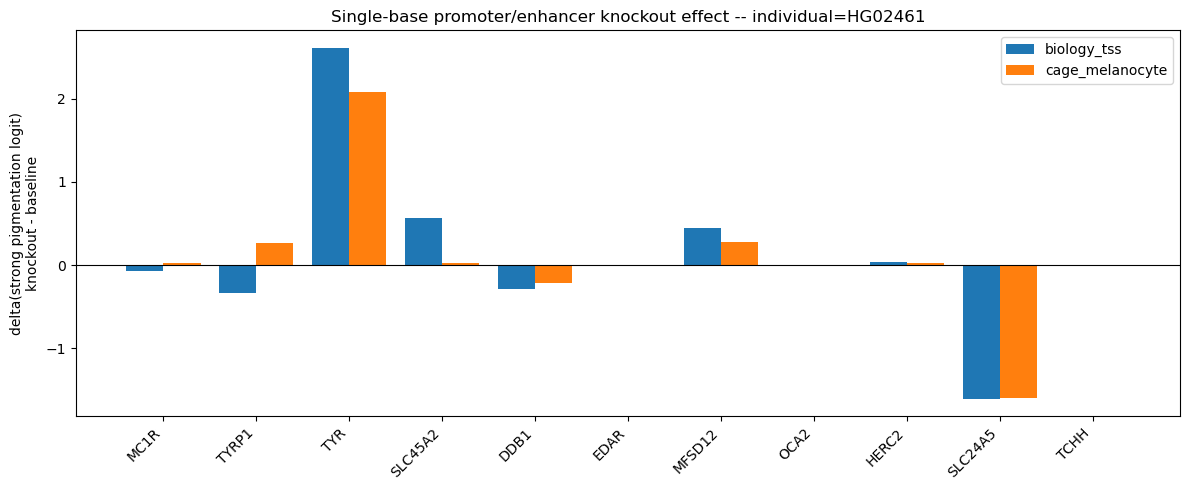

In [94]:
knockout_summary_df = pd.DataFrame([
    {
        "gene": r["gene"], "method": r["method"], "chrom": r["chrom"],
        "scramble_window": r["scramble_window"],
        "h1_offset_from_tss_bp": (
            r["hap_tracks"]["H1"]["marker_local_idx"][r["method"]] - r["hap_tracks"]["H1"]["marker_local_idx"]["biology_tss"]
        ),
        "h2_offset_from_tss_bp": (
            r["hap_tracks"]["H2"]["marker_local_idx"][r["method"]] - r["hap_tracks"]["H2"]["marker_local_idx"]["biology_tss"]
        ),
        "delta_strong_logit": r["delta_strong_logit"],
    }
    for r in knockout_results
])
display(knockout_summary_df)

fig, ax = plt.subplots(figsize=(12, 5))
genes_order = KO_GENES
x = np.arange(len(genes_order))
n_methods = len(KO_METHODS)
width = 0.8 / n_methods
for i, method in enumerate(KO_METHODS):
    sub = knockout_summary_df[knockout_summary_df["method"] == method].set_index("gene").reindex(genes_order)
    offset = (i - (n_methods - 1) / 2) * width
    ax.bar(x + offset, sub["delta_strong_logit"], width, label=method)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(genes_order, rotation=45, ha="right")
ax.set_ylabel(f"delta({class_names[ko_strong_idx]} logit)\nknockout - baseline")
ax.set_title(f"Single-base promoter/enhancer knockout effect -- individual={INDIVIDUAL_ID}")
ax.legend()
fig.tight_layout()
plt.show()

## 10. Bulk knockout results -- comparing location methods across the whole test split

Section 9 walked through the knockout mechanics for a single individual. Separately, the exact same
`knockout_gene_experiment` logic was run as a standalone script (`bulk_knockout.py`, not part of this
notebook) over **all 162 individuals in the test split x all 11 genes x all 3 location methods**
(`biology_tss`, `alphagenome_atac`, `cage_melanocyte`), scrambling a 100 bp window at each candidate
position and recording the baseline and perturbed logits. Results are cached at
`results/genotype_based_predictor/knockout_bulk/pigmentation_test_split_knockout.csv` (5,346 rows, 0
failures).

**ATAC excluded below.** The CSV itself still has all 3 methods, but `alphagenome_atac` rows are
filtered out immediately after loading (and every ATAC-specific dict/list entry further down is
commented out) -- see the "Ontology caveat" in Section 9's intro markdown: AlphaGenome has no
ontology-matched ATAC signal for this pigmentation config. This section compares `biology_tss` vs.
`cage_melanocyte` only: which genes and methods produce the strongest, most consistent knockout
effect.


In [95]:
BULK_RESULTS_PATH = REPO_ROOT / "results" / "genotype_based_predictor" / "knockout_bulk" / "pigmentation_test_split_knockout.csv"
bulk_df = pd.read_csv(BULK_RESULTS_PATH)
# ATAC disabled (see Section 9/10 markdown, "Ontology caveat") -- exclude alphagenome_atac rows
# from every downstream stat/plot in Sections 10-11, so gene_method_stats/box plots/etc. never
# include it.
bulk_df = bulk_df[bulk_df["method"] != "alphagenome_atac"]
print(f"Loaded {len(bulk_df)} rows (ATAC excluded): {bulk_df['sample_id'].nunique()} individuals x "
      f"{bulk_df['gene'].nunique()} genes x {bulk_df['method'].nunique()} methods")

METHOD_COLORS = {
    "biology_tss": "#1f77b4",
    # "alphagenome_atac": "#ff7f0e",  # ATAC disabled
    "cage_melanocyte": "#2ca02c",
}
METHOD_LABELS = {
    "biology_tss": "TSS (biology)",
    # "alphagenome_atac": "ATAC summit",  # ATAC disabled
    "cage_melanocyte": "CAGE summit",
}
BULK_GENES = sorted(bulk_df["gene"].unique(), key=lambda g: KO_GENES.index(g) if g in KO_GENES else 999)
BULK_METHODS = [
    "biology_tss",
    # "alphagenome_atac",  # ATAC disabled
    "cage_melanocyte",
]

gene_method_stats = (
    bulk_df.groupby(["gene", "method"])
    .agg(
        mean_baseline=("baseline_strong_logit", "mean"),
        mean_perturbed=("perturbed_strong_logit", "mean"),
        mean_delta=("delta_strong_logit", "mean"),
        std_delta=("delta_strong_logit", "std"),
        flip_rate=("flipped", "mean"),
        n=("flipped", "size"),
    )
    .reset_index()
)
gene_method_stats["flip_rate_pct"] = gene_method_stats["flip_rate"] * 100
display(gene_method_stats.sort_values("flip_rate", ascending=False).head(15))


Loaded 3564 rows (ATAC excluded): 162 individuals x 11 genes x 2 methods


,gene,method,mean_baseline,mean_perturbed,mean_delta,std_delta,flip_rate,n,flip_rate_pct
12,SLC24A5,biology_tss,0.125281,-1.291005,-1.416285,0.461311,0.685185,162,68.518519
13,SLC24A5,cage_melanocyte,0.125281,-1.282255,-1.407536,0.460260,0.679012,162,67.901235
20,TYRP1,biology_tss,0.125281,-0.435350,-0.560630,0.284311,0.327160,162,32.716049
0,DDB1,biology_tss,0.125281,-0.419403,-0.544683,0.235176,0.308642,162,30.864198
19,TYR,cage_melanocyte,0.125281,1.279924,1.154644,0.672153,0.259259,162,25.925926
18,TYR,biology_tss,0.125281,2.508581,2.383300,0.894233,0.259259,162,25.925926
14,SLC45A2,biology_tss,0.125281,0.789538,0.664258,0.207033,0.222222,162,22.222222
8,MFSD12,biology_tss,0.125281,0.737346,0.612065,0.239844,0.216049,162,21.604938
1,DDB1,cage_melanocyte,0.125281,-0.265968,-0.391248,0.182861,0.209877,162,20.987654
9,MFSD12,cage_melanocyte,0.125281,0.544715,0.419434,0.161636,0.172840,162,17.283951


### 10.1 Population-level arrow plot -- mean baseline -> mean perturbed logit, per gene x method

Each arrow starts at the population-mean `strong pigmentation` logit *before* knocking out a gene's
regulatory region, and points to the mean logit *after*. Longer arrows pointing left (toward negative,
i.e. toward `weak pigmentation`) mean a more effective knockout on average, for that method.

Genes are ranked by **flip rate** (Section 10.2), not raw mean-logit-shift: TYR's logit shift is ~20x
larger than any other gene's (its scrambled-window knockout appears to push the model into an
out-of-distribution / saturating regime -- flagged as an open caveat in Section 9), which would otherwise
dominate the ranking despite not being the most *decisive* knockout (see the flip-rate chart). The x-axis
uses a symlog scale so both TYR's large excursions and the other genes' subtler shifts stay legible in one
plot.


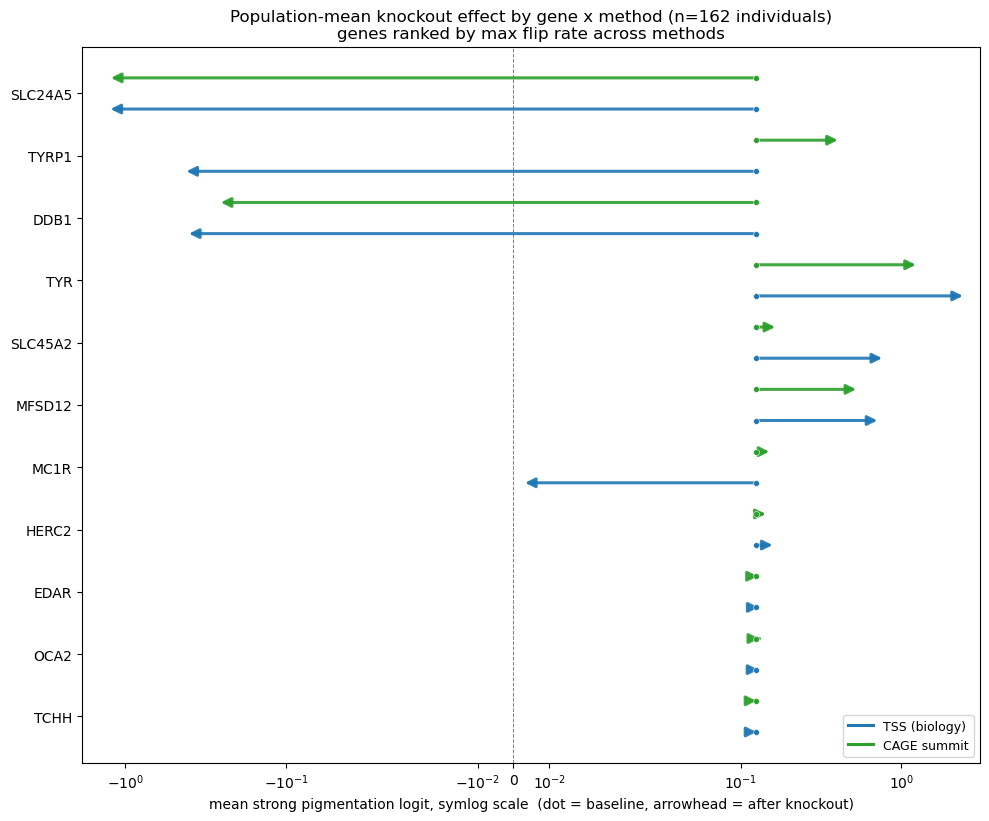

In [96]:
gene_max_flip_rate = gene_method_stats.groupby("gene")["flip_rate"].max().sort_values(ascending=False)
gene_order_by_effect = gene_max_flip_rate.index.tolist()

fig, ax = plt.subplots(figsize=(10, 0.62 * len(gene_order_by_effect) + 1.5))
n_methods = len(BULK_METHODS)
row_height = 0.62
all_x = []
for gi, gene in enumerate(gene_order_by_effect):
    y_base = (len(gene_order_by_effect) - 1 - gi) * row_height * n_methods
    for mi, method in enumerate(BULK_METHODS):
        row = gene_method_stats[(gene_method_stats["gene"] == gene) & (gene_method_stats["method"] == method)]
        if row.empty:
            continue
        row = row.iloc[0]
        y = y_base + mi * row_height
        color = METHOD_COLORS[method]
        ax.annotate(
            "", xy=(row["mean_perturbed"], y), xytext=(row["mean_baseline"], y),
            arrowprops=dict(arrowstyle="-|>", color=color, lw=2.2, alpha=0.9, mutation_scale=14),
        )
        ax.scatter([row["mean_baseline"]], [y], color=color, s=18, zorder=3, edgecolor="white", linewidth=0.4)
        all_x.extend([row["mean_baseline"], row["mean_perturbed"]])
ax.axvline(0, color="black", linewidth=0.7, linestyle="--", alpha=0.5)
yticks = [(len(gene_order_by_effect) - 1 - gi) * row_height * n_methods + row_height * (n_methods - 1) / 2 for gi in range(len(gene_order_by_effect))]
ax.set_yticks(yticks)
ax.set_yticklabels(gene_order_by_effect)
ax.set_xscale("symlog", linthresh=0.05)
x_lo, x_hi = min(all_x), max(all_x)
x_pad = 0.15 * (x_hi - x_lo)
ax.set_xlim(x_lo - x_pad, x_hi + x_pad)
ax.set_xlabel(f"mean {class_names[ko_strong_idx]} logit, symlog scale  (dot = baseline, arrowhead = after knockout)")
ax.set_title(f"Population-mean knockout effect by gene x method (n={bulk_df['sample_id'].nunique()} individuals)\ngenes ranked by max flip rate across methods")
handles = [plt.Line2D([], [], color=METHOD_COLORS[m], lw=2.2, label=METHOD_LABELS[m]) for m in BULK_METHODS]
ax.legend(handles=handles, loc="lower right", fontsize=9)
ax.set_ylim(-row_height, len(gene_order_by_effect) * row_height * n_methods)
fig.tight_layout()
fig.savefig(KNOCKOUT_FIG_DIR / "bulk_arrow_population_mean.png", dpi=140)
plt.show()


### 10.2 Flip rate by gene x method, across all 162 test individuals

The fraction of individuals whose predicted class (`strong pigmentation` vs `weak pigmentation`) actually
flips after the knockout -- the clearest, most interpretable measure of knockout effectiveness.


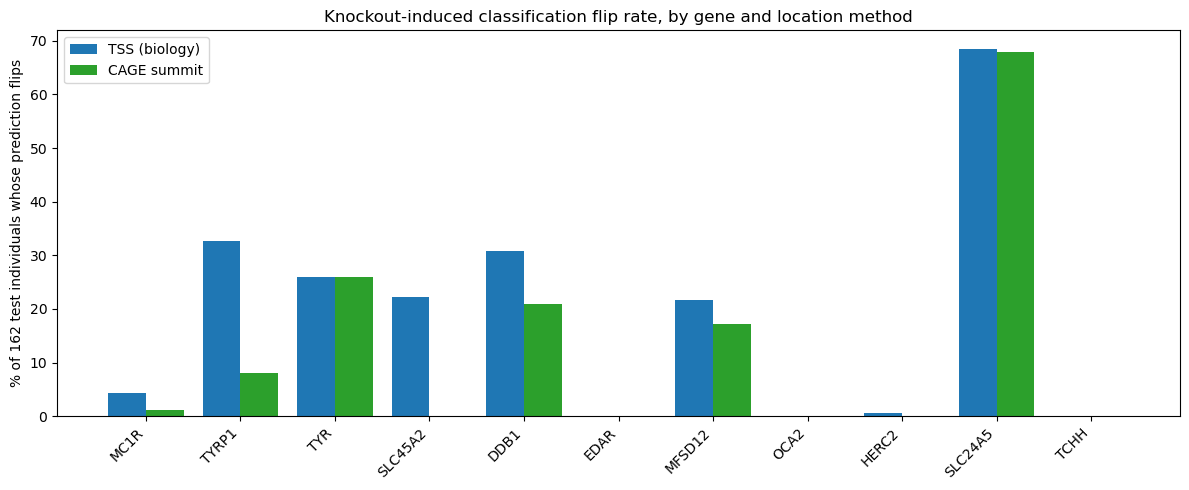

In [97]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(BULK_GENES))
width = 0.8 / len(BULK_METHODS)
for i, method in enumerate(BULK_METHODS):
    sub = gene_method_stats[gene_method_stats["method"] == method].set_index("gene").reindex(BULK_GENES)
    offset = (i - (len(BULK_METHODS) - 1) / 2) * width
    ax.bar(x + offset, sub["flip_rate_pct"], width, label=METHOD_LABELS[method], color=METHOD_COLORS[method])
ax.set_xticks(x)
ax.set_xticklabels(BULK_GENES, rotation=45, ha="right")
ax.set_ylabel("% of 162 test individuals whose prediction flips")
ax.set_title("Knockout-induced classification flip rate, by gene and location method")
ax.legend()
fig.tight_layout()
fig.savefig(KNOCKOUT_FIG_DIR / "bulk_flip_rate_bars.png", dpi=140)
plt.show()


### 10.3 Distribution of the effect (not just the mean) -- box plots of `delta_strong_logit`

The mean can hide a lot: a method might have a large mean delta driven by a few outlier individuals, or a
small but very consistent delta across everyone. Box plots (one box per gene x method) show the spread.


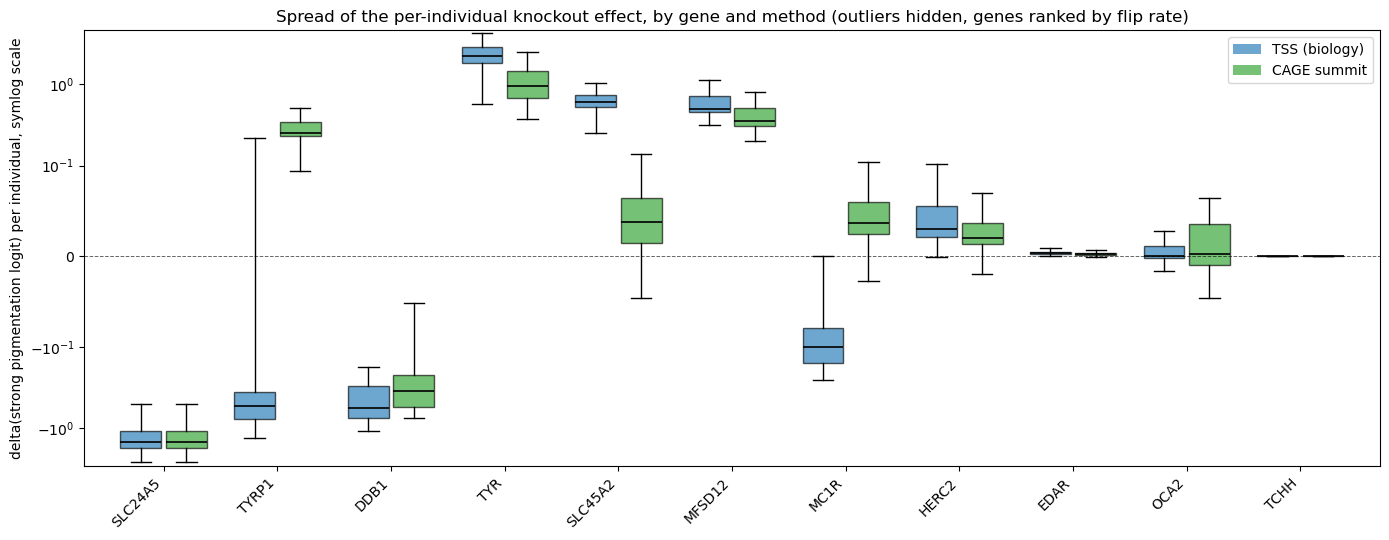

In [98]:
fig, ax = plt.subplots(figsize=(14, 5.5))
box_data, box_positions, box_colors = [], [], []
group_width = 0.8
n_methods = len(BULK_METHODS)
for gi, gene in enumerate(gene_order_by_effect):
    for mi, method in enumerate(BULK_METHODS):
        vals = bulk_df[(bulk_df["gene"] == gene) & (bulk_df["method"] == method)]["delta_strong_logit"].values
        box_data.append(vals)
        box_positions.append(gi + (mi - (n_methods - 1) / 2) * (group_width / n_methods))
        box_colors.append(METHOD_COLORS[method])
bp = ax.boxplot(
    box_data, positions=box_positions, widths=group_width / n_methods * 0.9, patch_artist=True,
    showfliers=False, medianprops=dict(color="black", linewidth=1.2),
)
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)
ax.axhline(0, color="black", linewidth=0.7, linestyle="--", alpha=0.6)
ax.set_xticks(range(len(gene_order_by_effect)))
ax.set_xticklabels(gene_order_by_effect, rotation=45, ha="right")
ax.set_yscale("symlog", linthresh=0.1)
ax.set_ylabel(f"delta({class_names[ko_strong_idx]} logit) per individual, symlog scale")
ax.set_title("Spread of the per-individual knockout effect, by gene and method (outliers hidden, genes ranked by flip rate)")
handles = [Patch(facecolor=METHOD_COLORS[m], alpha=0.65, label=METHOD_LABELS[m]) for m in BULK_METHODS]
ax.legend(handles=handles)
fig.tight_layout()
fig.savefig(KNOCKOUT_FIG_DIR / "bulk_delta_boxplots.png", dpi=140)
plt.show()


### 10.4 Individual-level arrow plots for the top genes -- every one of the 162 individuals

For the genes with the strongest population-level effect, this shows every individual's own
baseline -> perturbed arrow (sorted by baseline logit), one column per method, so patterns like
"only strong-pigmentation individuals flip" or "this method barely moves anyone" are visible directly,
not just in aggregate.


Top 4 genes by max flip rate: ['SLC24A5', 'TYRP1', 'DDB1', 'TYR']


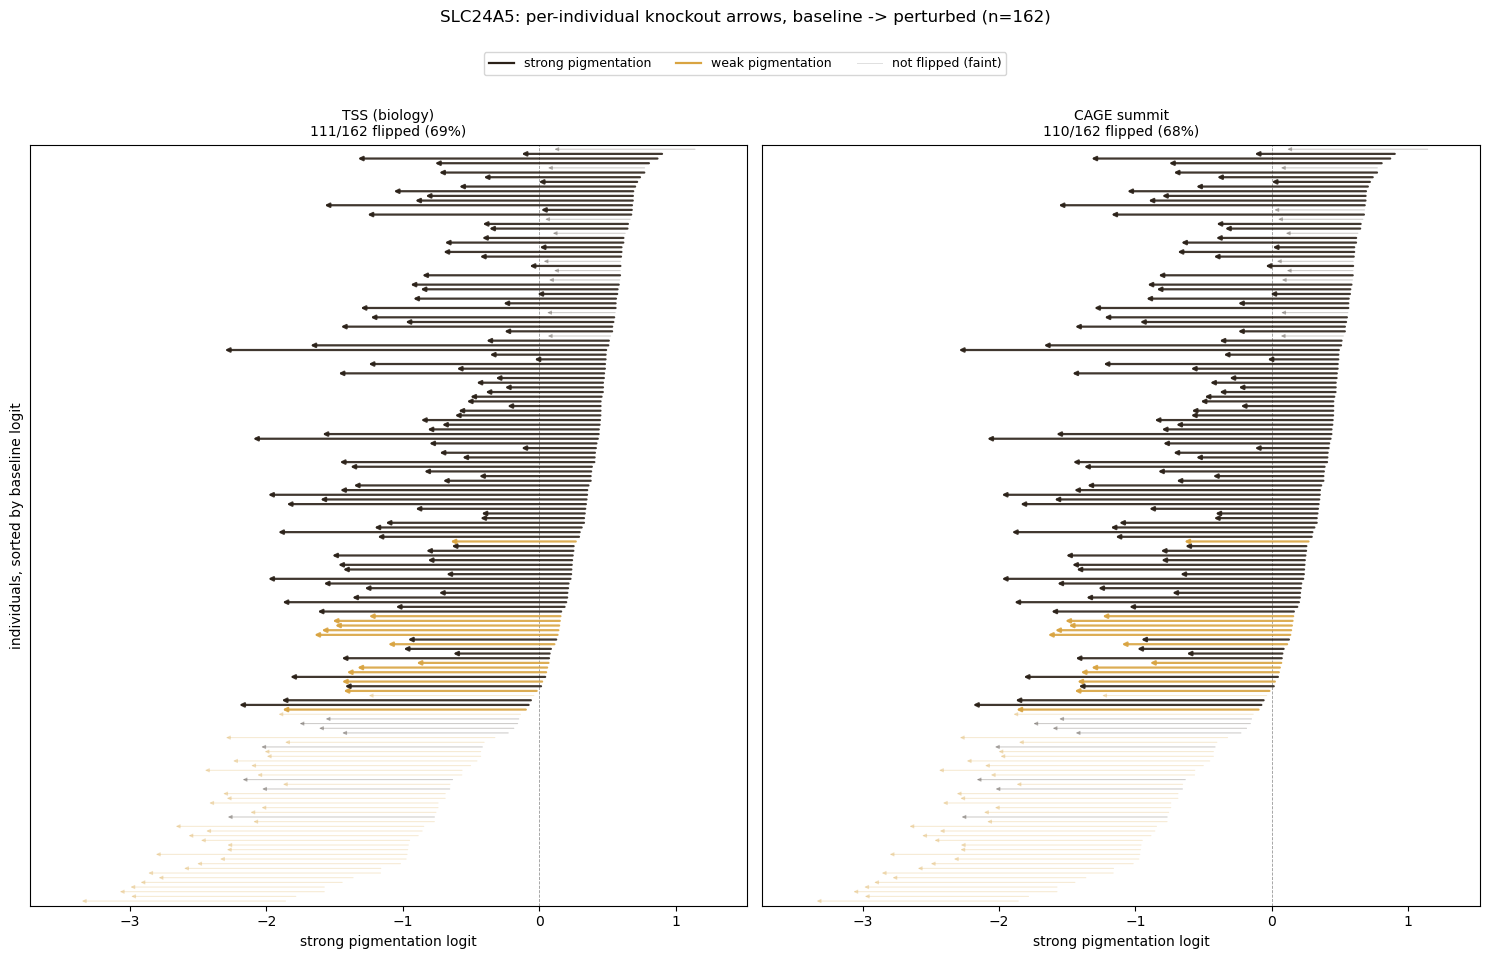

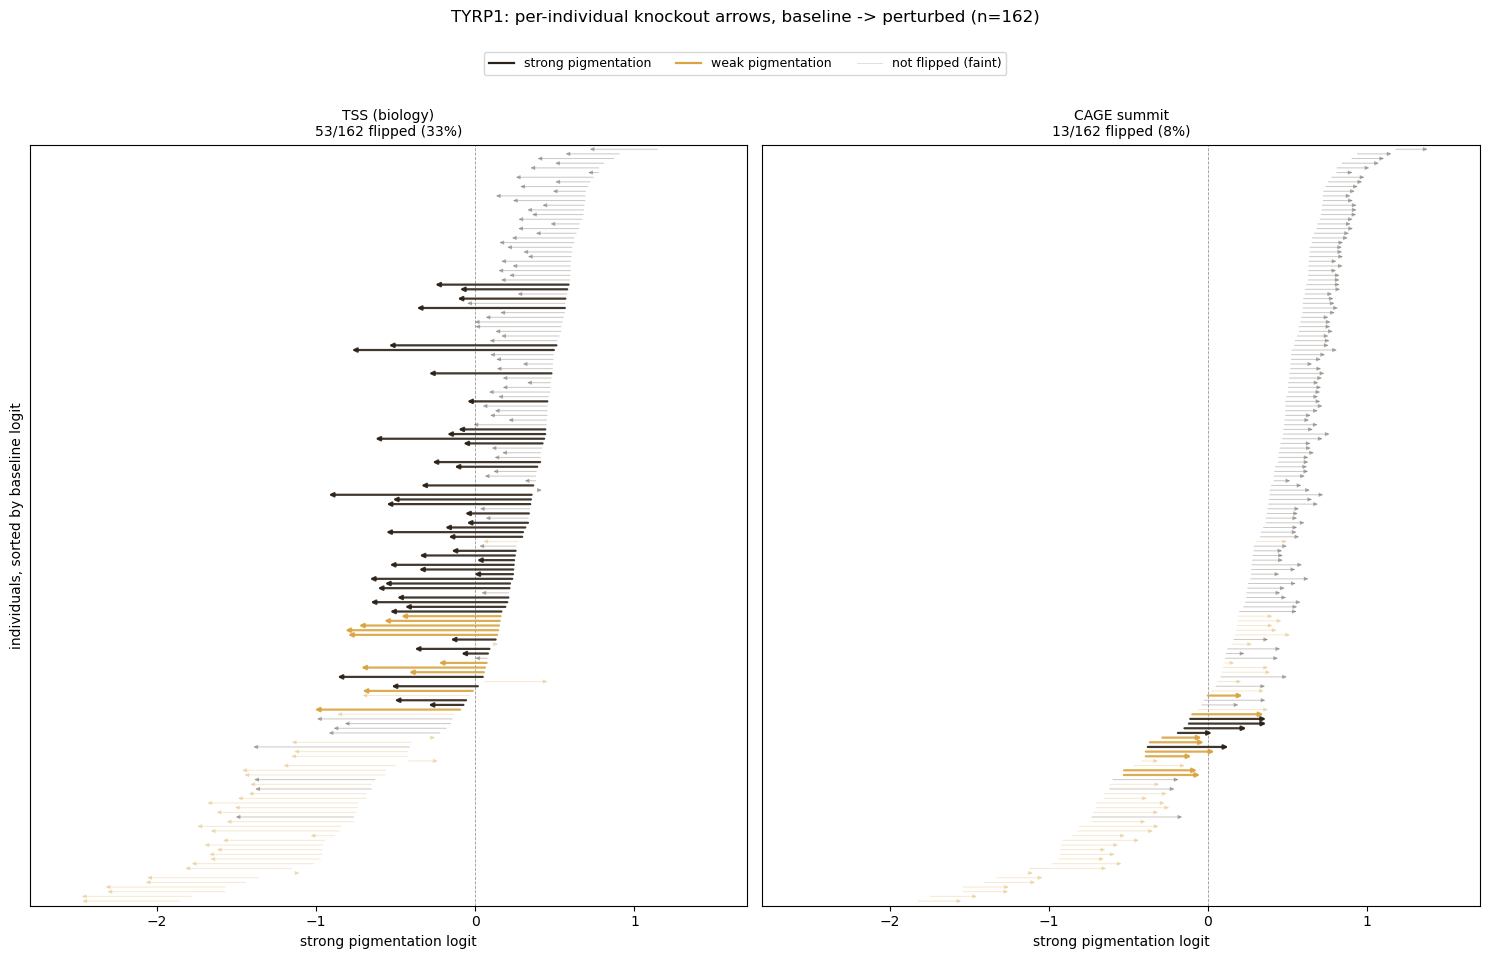

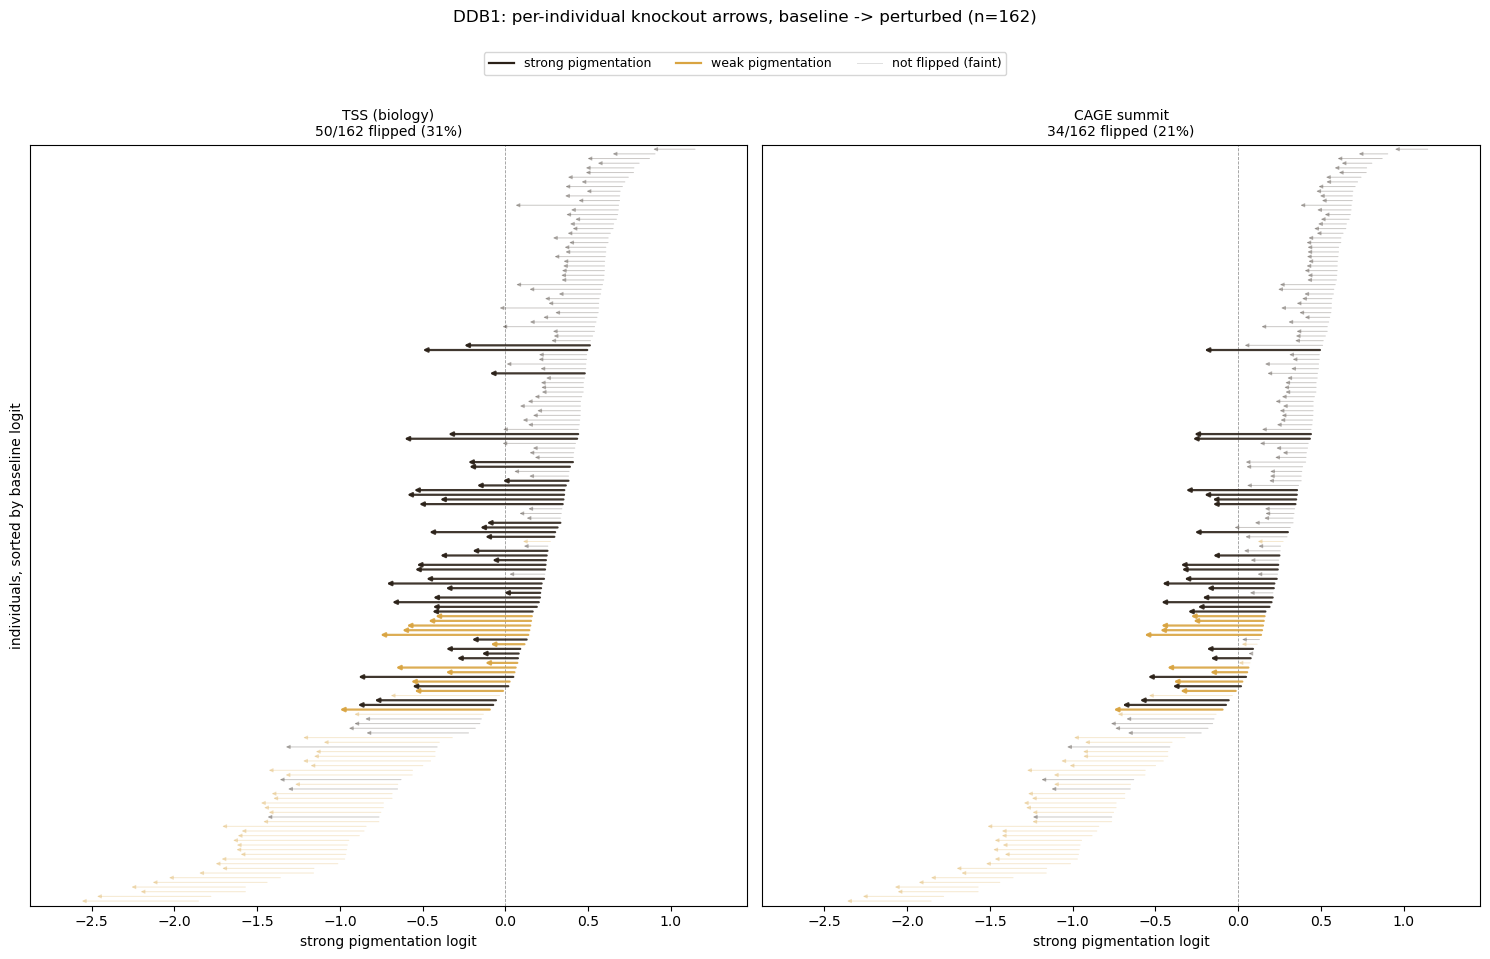

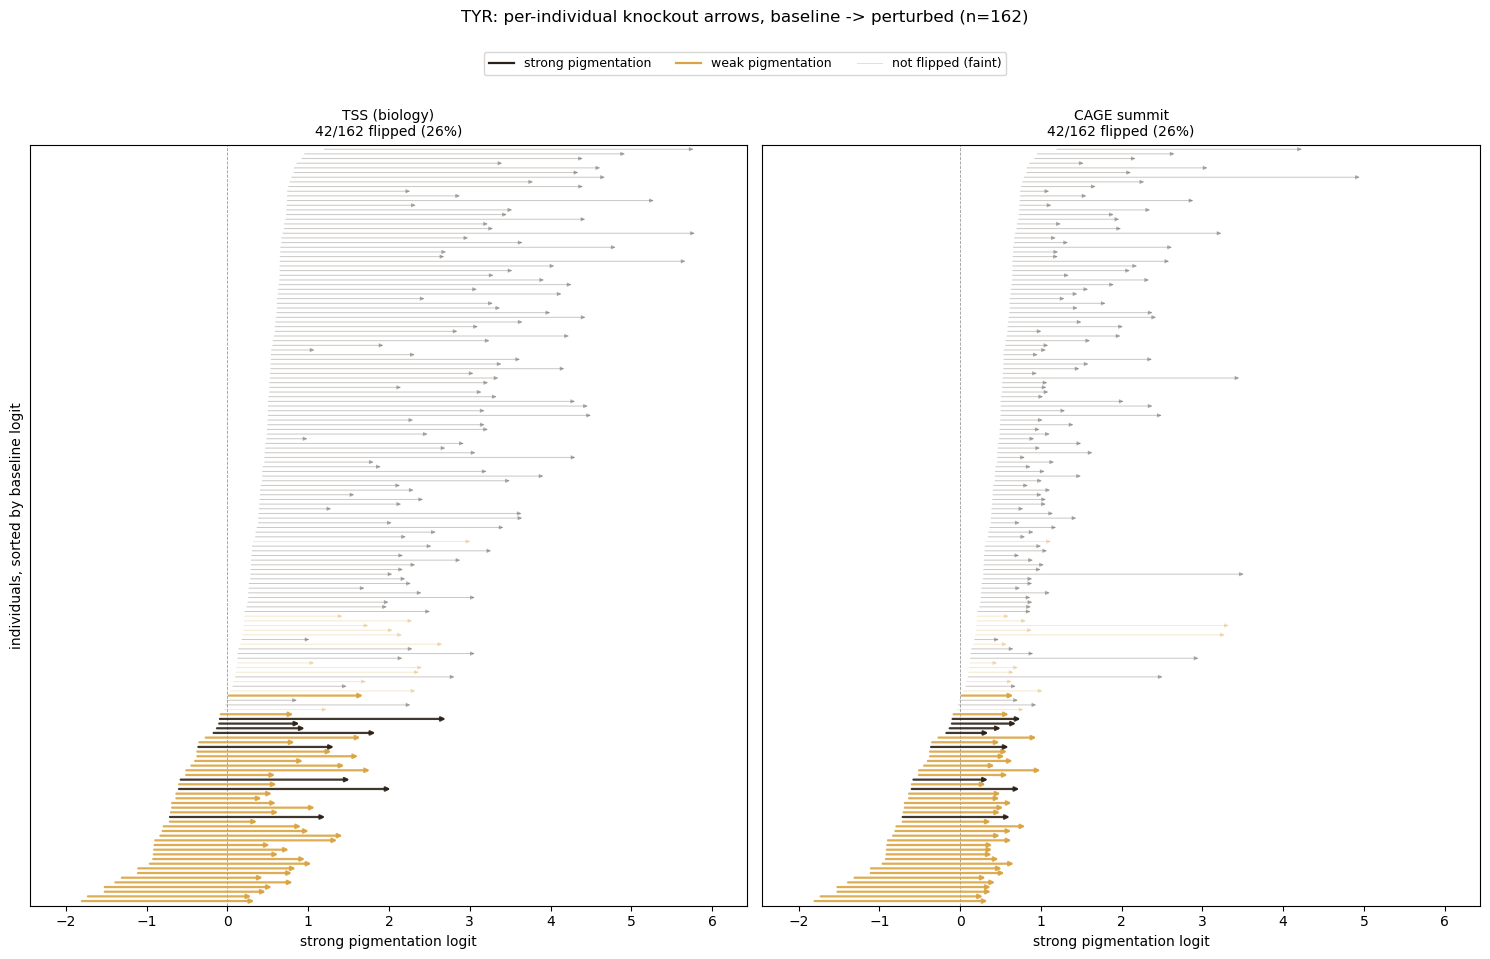

In [99]:
TOP_N_GENES_DETAIL = 4
top_genes_detail = gene_order_by_effect[:TOP_N_GENES_DETAIL]
print(f"Top {TOP_N_GENES_DETAIL} genes by max flip rate: {top_genes_detail}")

# Same dark/light colors as Section 8's CLASS_COLORS (strong = dark, weak = light), so this
# matches every other strong/weak-pigmentation plot in the notebook.
TRUE_LABEL_COLORS = {
    class_names[TARGET_CLASS_IDX]: CLASS_COLORS[TARGET_CLASS_IDX],
    class_names[OTHER_CLASS_IDX]: CLASS_COLORS[OTHER_CLASS_IDX],
}

for gene in top_genes_detail:
    fig, axes = plt.subplots(1, len(BULK_METHODS), figsize=(15, 9), sharey=True)
    gene_df = bulk_df[bulk_df["gene"] == gene]
    gene_x_lo = gene_df[["baseline_strong_logit", "perturbed_strong_logit"]].min().min()
    gene_x_hi = gene_df[["baseline_strong_logit", "perturbed_strong_logit"]].max().max()
    gene_x_pad = 0.08 * (gene_x_hi - gene_x_lo + 1e-6)
    for ax, method in zip(axes, BULK_METHODS):
        sub = gene_df[gene_df["method"] == method].sort_values("baseline_strong_logit").reset_index(drop=True)
        for row_i, row in sub.iterrows():
            color = TRUE_LABEL_COLORS.get(row["true_label"], "gray")
            alpha = 0.9 if row["flipped"] else 0.25
            lw = 1.6 if row["flipped"] else 0.7
            ax.annotate(
                "", xy=(row["perturbed_strong_logit"], row_i), xytext=(row["baseline_strong_logit"], row_i),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, alpha=alpha, mutation_scale=6),
            )
        ax.set_xlim(gene_x_lo - gene_x_pad, gene_x_hi + gene_x_pad)
        ax.set_ylim(-1, len(sub))
        ax.axvline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.4)
        n_flipped = int(sub["flipped"].sum())
        ax.set_title(f"{METHOD_LABELS[method]}\n{n_flipped}/{len(sub)} flipped ({100 * n_flipped / len(sub):.0f}%)", fontsize=10)
        ax.set_xlabel(f"{class_names[ko_strong_idx]} logit")
    axes[0].set_ylabel("individuals, sorted by baseline logit")
    for ax in axes:
        ax.set_yticks([])
    handles = [plt.Line2D([], [], color=c, lw=1.6, label=lbl) for lbl, c in TRUE_LABEL_COLORS.items()]
    handles.append(plt.Line2D([], [], color="gray", lw=0.7, alpha=0.25, label="not flipped (faint)"))
    fig.legend(handles=handles, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02), fontsize=9)
    fig.suptitle(f"{gene}: per-individual knockout arrows, baseline -> perturbed (n={sub['sample_id'].nunique()})", y=1.06)
    fig.tight_layout()
    fig.savefig(KNOCKOUT_FIG_DIR / f"bulk_arrows_individual_{gene}.png", dpi=140, bbox_inches="tight")
    plt.show()

### 10.5 Do the three methods agree? Per-individual delta correlation

If `biology_tss` and `cage_melanocyte` are both correctly finding the same functional promoter, their
per-individual knockout effects on the same person should correlate -- even though the exact scrambled
window differs (different candidate position, possibly different haplotype-local coordinates).


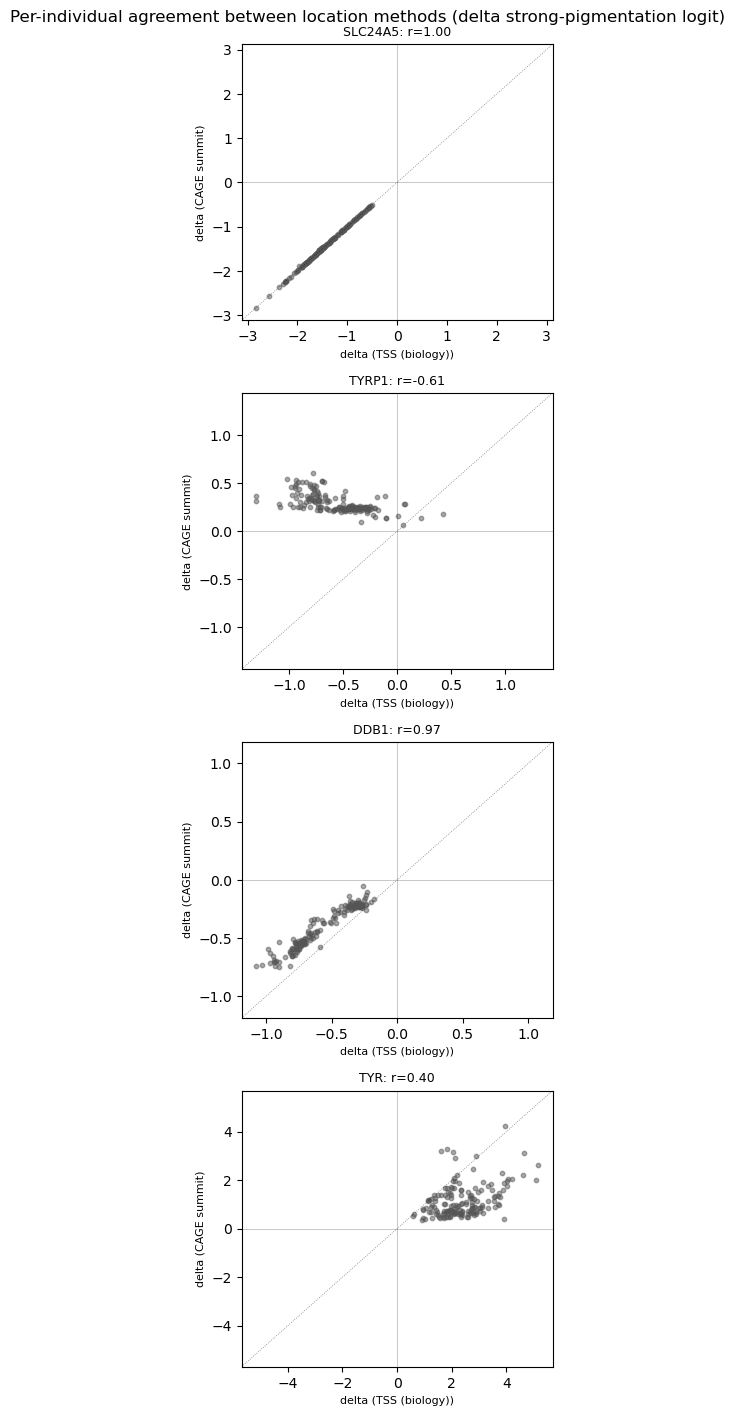

In [100]:
method_pairs = [
    ("biology_tss", "cage_melanocyte"),
    # ("biology_tss", "alphagenome_atac"),  # ATAC disabled
    # ("cage_melanocyte", "alphagenome_atac"),  # ATAC disabled
]
fig, axes = plt.subplots(
    len(top_genes_detail), len(method_pairs), figsize=(4 * len(method_pairs), 3.6 * len(top_genes_detail)),
    squeeze=False,  # only 1 method_pair remains with ATAC disabled -- squeeze=False keeps axes 2D either way
)
for gi, gene in enumerate(top_genes_detail):
    gene_df = bulk_df[bulk_df["gene"] == gene]
    for pi, (m1, m2) in enumerate(method_pairs):
        ax = axes[gi, pi]
        d1 = gene_df[gene_df["method"] == m1].set_index("sample_id")["delta_strong_logit"]
        d2 = gene_df[gene_df["method"] == m2].set_index("sample_id")["delta_strong_logit"]
        common = d1.index.intersection(d2.index)
        x_vals, y_vals = d1.loc[common].values, d2.loc[common].values
        ax.scatter(x_vals, y_vals, s=10, alpha=0.5, color="#555555")
        if len(common) > 1 and x_vals.std() > 0 and y_vals.std() > 0:
            r = np.corrcoef(x_vals, y_vals)[0, 1]
        else:
            r = float("nan")
        lim = max(np.abs(x_vals).max(), np.abs(y_vals).max(), 1e-6) * 1.1
        ax.plot([-lim, lim], [-lim, lim], color="black", linewidth=0.6, linestyle=":", alpha=0.5)
        ax.axhline(0, color="black", linewidth=0.5, alpha=0.3)
        ax.axvline(0, color="black", linewidth=0.5, alpha=0.3)
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_title(f"{gene}: r={r:.2f}", fontsize=9)
        ax.set_xlabel(f"delta ({METHOD_LABELS[m1]})", fontsize=8)
        ax.set_ylabel(f"delta ({METHOD_LABELS[m2]})", fontsize=8)
fig.suptitle("Per-individual agreement between location methods (delta strong-pigmentation logit)")
fig.tight_layout()
fig.savefig(KNOCKOUT_FIG_DIR / "bulk_method_agreement_scatter.png", dpi=140)
plt.show()


### 10.6 Population breakdown for the single strongest gene

If a knockout is genuinely capturing a functional pigmentation mechanism, its effect should track
individual genotype/ancestry (`strong pigmentation` populations should show larger negative deltas), not
be a uniform artifact applied identically regardless of population.


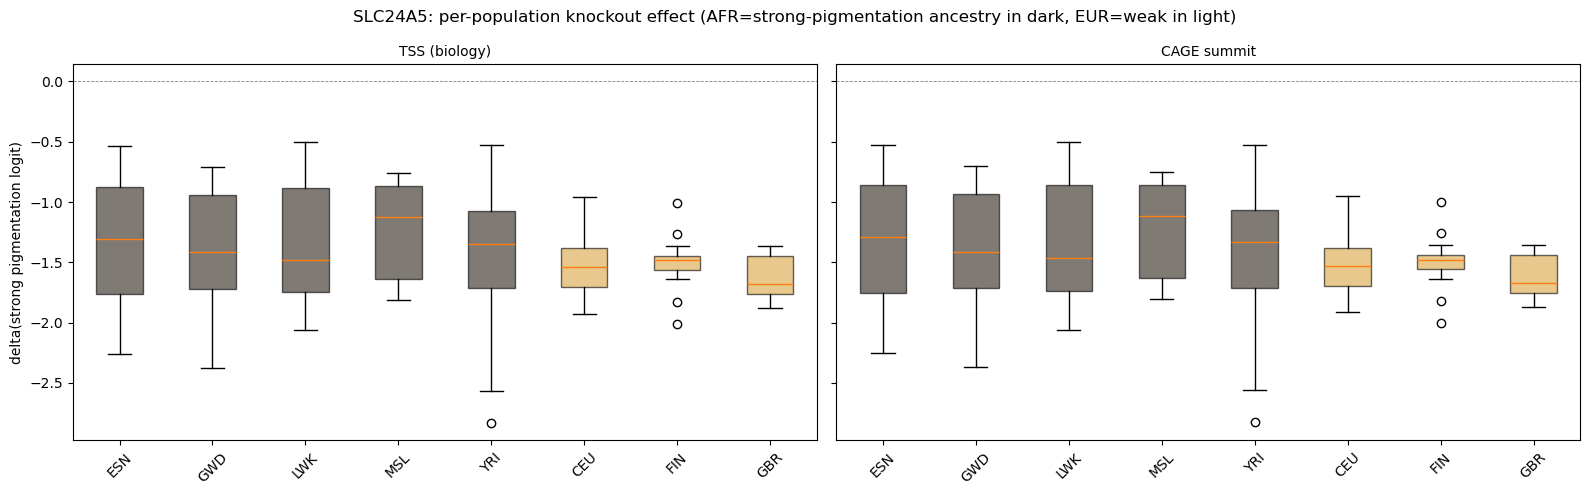

In [101]:
top_gene = gene_order_by_effect[0]
pop_order = (
    bulk_df[["population", "superpopulation"]].drop_duplicates().sort_values(["superpopulation", "population"])["population"].tolist()
)
fig, axes = plt.subplots(1, len(BULK_METHODS), figsize=(16, 5), sharey=True)
for ax, method in zip(axes, BULK_METHODS):
    sub = bulk_df[(bulk_df["gene"] == top_gene) & (bulk_df["method"] == method)]
    data = [sub[sub["population"] == pop]["delta_strong_logit"].values for pop in pop_order]
    bp = ax.boxplot(data, tick_labels=pop_order, patch_artist=True, showfliers=True)
    for patch, pop in zip(bp["boxes"], pop_order):
        superpop = bulk_df[bulk_df["population"] == pop]["superpopulation"].iloc[0]
        # Same dark/light colors as Section 8's CLASS_COLORS (strong = dark, weak = light).
        patch.set_facecolor(CLASS_COLORS[TARGET_CLASS_IDX] if superpop == "AFR" else CLASS_COLORS[OTHER_CLASS_IDX])
        patch.set_alpha(0.6)
    ax.axhline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.5)
    ax.set_title(METHOD_LABELS[method], fontsize=10)
    ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel(f"delta({class_names[ko_strong_idx]} logit)")
fig.suptitle(f"{top_gene}: per-population knockout effect (AFR=strong-pigmentation ancestry in dark, EUR=weak in light)")
fig.tight_layout()
fig.savefig(KNOCKOUT_FIG_DIR / f"bulk_population_breakdown_{top_gene}.png", dpi=140)
plt.show()

## 11. Class-mean RNA-seq signal: baseline vs. knockout, strong vs. weak pigmentation

Sections 9-10 only ever looked at the CNN's scalar output (logits/flip rate). This section looks
at the actual RNA-seq signal AlphaGenome predicted, averaged across every `strong pigmentation` and
`weak pigmentation` test-split individual, both before (`baseline`) and after (`knockout`) the
window-scramble perturbation -- a direct sanity check on whether the knockout result "makes sense"
biologically, independent of what the CNN does with it: does scrambling the promoter/enhancer
actually flatten the signal there, and do the two ancestry groups differ in the direction expected
for a real pigmentation gene?

**Cost note.** This reuses the *cached* AlphaGenome predictions from Sections 9/10's bulk knockout
run (`notebooks/.cache/promoter_knockout_predictions/`) -- no new API calls, no CNN model, no
dataset/tensor cache reload. Restricted to `top_genes_detail` (the same top-4-by-flip-rate genes
from Section 10.4) to keep the file I/O bounded (each gene reads every test-split individual's raw
prediction + cached perturbed prediction, for both haplotypes and all 3 methods).

**Two views, because one plot can't show both.** The scrambled window is only 100bp inside a
~20,000-35,000bp plotted span (set by the CNN's 32,768bp input crop) -- on an absolute-signal plot
that's under 1% of the x-axis, so a real but localized knockout effect is invisible next to
full-scale exon peaks. So this section renders two figures per gene:

1. **Overview** (`class_mean_signal_<gene>.png`) -- solid=`baseline`, dashed=`knockout`, colored by
   true label (same colors as Section 10.4/10.6), full plotted span, absolute signal. Good for
   checking gross track shape and whether the two ancestry groups' *baseline* signal differs at all
   (a real pigmentation-gene signature), but the knockout perturbation itself will look invisible
   here -- that's expected, not a bug.
2. **Delta** (`class_mean_signal_<gene>_delta.png`) -- plots `knockout - baseline` directly (one
   line per class, y-axis autoscaled to whatever the actual difference is), which cancels out the
   shared exon structure and isolates exactly where and how much the scramble changed the signal.
   This is the one that actually answers "did the knockout do anything, and does it look like a
   real regulatory effect" -- a real effect should show a spike/dip concentrated in or immediately
   around the black scrambled-window strip, not scattered noise across the whole span.

In both figures: x=0 is the method's own knockout target for that column; the black shaded strip
marks the exact scrambled window; the thin dotted vertical lines mark the other two methods' target
positions for context; the gray band is the CNN's actual 32,768bp input crop. Each row is one of
the 6 signal tracks (3 ontology terms x 2 strands).


In [102]:
SCRAMBLE_WINDOW = 100
assert (bulk_df["scramble_window"] == SCRAMBLE_WINDOW).all(), "scramble_window mismatch vs bulk CSV"

GLOBAL_TRACK_ORDER = [(term, strand) for term in KO_ONTOLOGY_TERMS for strand in ("+", "-")]
GLOBAL_TRACK_LABELS = [f"{term} ({strand})" for term, strand in GLOBAL_TRACK_ORDER]


def gene_markers(gene):
    window_meta = json.loads((DATASET_DIR / "references" / "windows" / gene / "window_metadata.json").read_text())
    chrom = window_meta["chromosome"]
    start_1based = int(window_meta["start"])
    full_ref_length = int(window_meta["end"]) - start_1based + 1
    interval = genome.Interval(chromosome=chrom, start=start_1based - 1, end=start_1based - 1 + full_ref_length)
    _, tss_pos_0based, _ = get_gene_tss(gene)
    tss_local_idx = tss_pos_0based - (start_1based - 1)
    # atac_local_idx = find_atac_summit(gene)["summit_local_idx"]  # ATAC disabled
    cage_local_idx = find_cage_promoter(gene)["summit_local_idx"]
    ref_idx_by_method = {
        "biology_tss": tss_local_idx,
        # "alphagenome_atac": atac_local_idx,  # ATAC disabled
        "cage_melanocyte": cage_local_idx,
    }
    genomic_pos_by_method = {m: start_1based + idx for m, idx in ref_idx_by_method.items()}
    return chrom, start_1based, full_ref_length, interval, ref_idx_by_method, genomic_pos_by_method


def get_perturbed_track(cache_key, sample_id, gene, haplotype, hap_target_idx, interval, canonical_order):
    cache_path = ATAC_SUMMIT_CACHE_DIR / f"seq_{cache_key}.npz"
    meta_cache_path = ATAC_SUMMIT_CACHE_DIR / f"seq_{cache_key}_meta.json"
    if cache_path.exists() and meta_cache_path.exists():
        mod_values = np.load(cache_path)["values"]
        mod_meta_records = json.loads(meta_cache_path.read_text())
    else:
        # Cache miss (shouldn't happen for anything the bulk run already covered) -- fall back to
        # recomputing the scrambled sequence and calling AlphaGenome, exactly like Section 9.
        seq = load_haplotype_fasta(sample_id, gene, haplotype)
        modified_seq, _orig_seg, _scr_seg, _s, _e = apply_scramble(seq, hap_target_idx, window_size=SCRAMBLE_WINDOW)
        mod_values, mod_meta_records = predict_modified_sequence(cache_key, modified_seq, interval)
    return reorder_to_canonical(mod_values, pd.DataFrame(mod_meta_records), canonical_order)


def collect_gene_class_mean_signal(gene, methods, marker_margin=1000):
    chrom, start_1based, full_ref_length, interval, ref_idx_by_method, genomic_pos_by_method = gene_markers(gene)
    crop_lo, crop_hi = cnn_crop_bounds(full_ref_length, KO_CONFIG.dataset_input.window_center_size)
    ref_markers = list(ref_idx_by_method.values())
    win_lo = min([crop_lo] + [m - marker_margin for m in ref_markers if m < crop_lo])
    win_hi = max([crop_hi] + [m + marker_margin for m in ref_markers if m >= crop_hi])
    win_span = win_hi - win_lo

    gene_rows = bulk_df[bulk_df["gene"] == gene][["sample_id", "true_label"]].drop_duplicates()
    sample_labels = dict(zip(gene_rows["sample_id"], gene_rows["true_label"]))

    baseline_by_label = {method: {label: [] for label in class_names} for method in methods}
    perturbed_by_label = {method: {label: [] for label in class_names} for method in methods}
    n_skipped = 0

    for sample_id, label in sample_labels.items():
        if label not in class_names:
            continue
        hap_base_by_method = {method: [] for method in methods}
        hap_mod_by_method = {method: [] for method in methods}
        skip_sample = False
        for haplotype in ("H1", "H2"):
            orig_array, orig_meta = load_raw_prediction(sample_id, gene, haplotype)
            base_reordered = reorder_to_canonical(orig_array, pd.DataFrame(orig_meta), GLOBAL_TRACK_ORDER)
            for method in methods:
                hap_target_idx = haplotype_local_idx(
                    sample_id, gene, haplotype, start_1based, genomic_pos_by_method[method],
                )
                lo = hap_target_idx + (win_lo - ref_idx_by_method[method])
                hi = lo + win_span
                if lo < 0 or hi > base_reordered.shape[0]:
                    skip_sample = True
                    break
                cache_key = f"{sample_id}_{gene}_{haplotype}_{method}_{hap_target_idx}_scramble{SCRAMBLE_WINDOW}"
                mod_reordered = get_perturbed_track(
                    cache_key, sample_id, gene, haplotype, hap_target_idx, interval, GLOBAL_TRACK_ORDER,
                )
                hap_base_by_method[method].append(base_reordered[lo:hi])
                hap_mod_by_method[method].append(mod_reordered[lo:hi])
            if skip_sample:
                break
        if skip_sample:
            n_skipped += 1
            continue
        for method in methods:
            baseline_by_label[method][label].append(np.mean(hap_base_by_method[method], axis=0))
            perturbed_by_label[method][label].append(np.mean(hap_mod_by_method[method], axis=0))

    by_method = {}
    for method in methods:
        mean_baseline = {l: np.mean(v, axis=0) for l, v in baseline_by_label[method].items() if v}
        mean_perturbed = {l: np.mean(v, axis=0) for l, v in perturbed_by_label[method].items() if v}
        n_by_label = {l: len(v) for l, v in baseline_by_label[method].items()}
        by_method[method] = {"mean_baseline": mean_baseline, "mean_perturbed": mean_perturbed, "n_by_label": n_by_label}

    return {
        "win_lo": win_lo, "win_hi": win_hi, "win_span": win_span,
        "crop_lo": crop_lo, "crop_hi": crop_hi, "ref_idx_by_method": ref_idx_by_method,
        "by_method": by_method, "n_skipped": n_skipped,
    }

print("collect_gene_class_mean_signal ready.")


collect_gene_class_mean_signal ready.


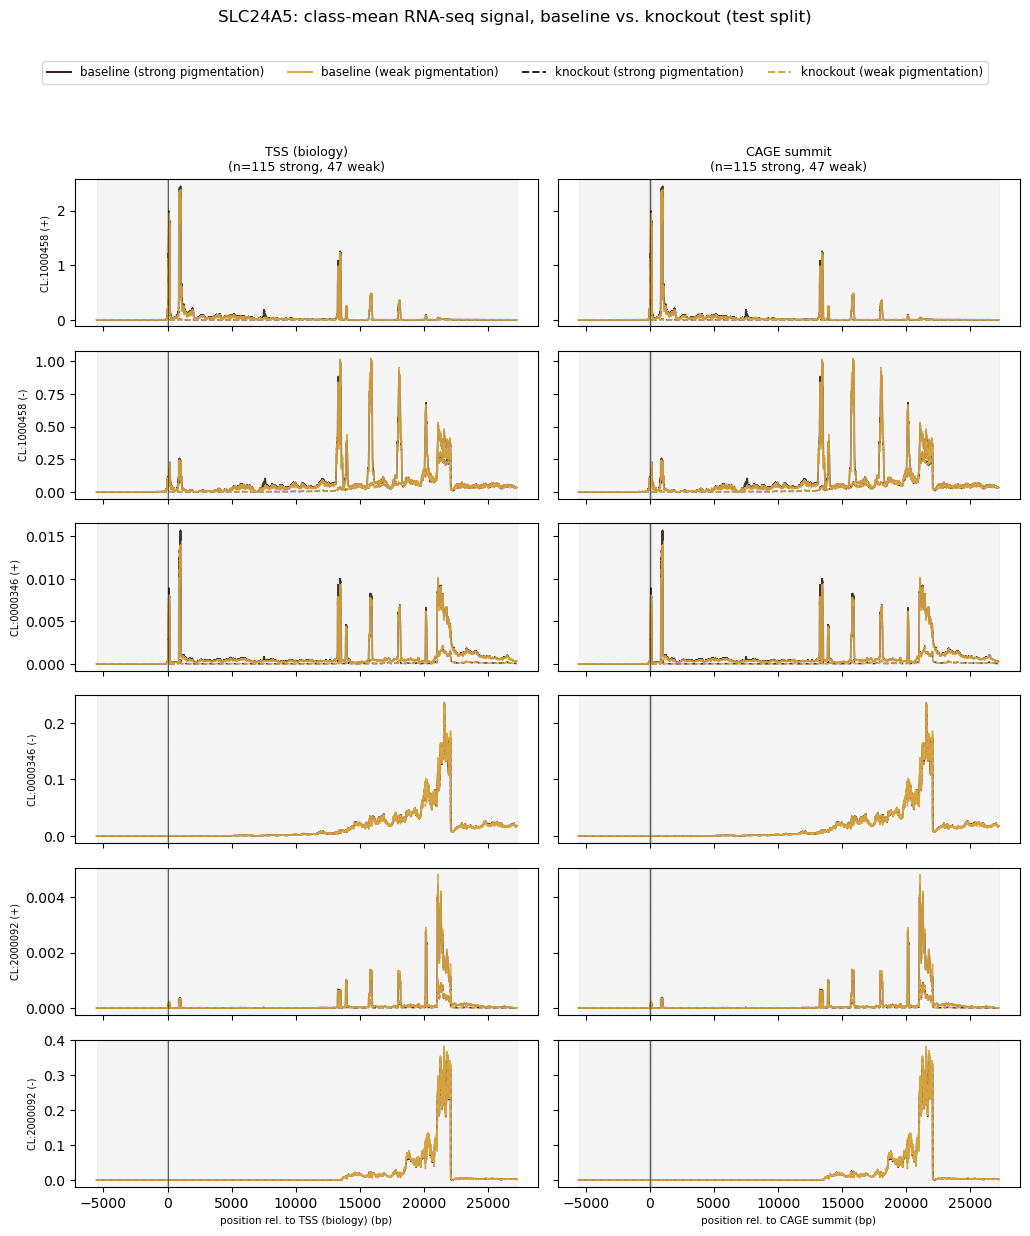

saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/class_mean_signal_SLC24A5.png


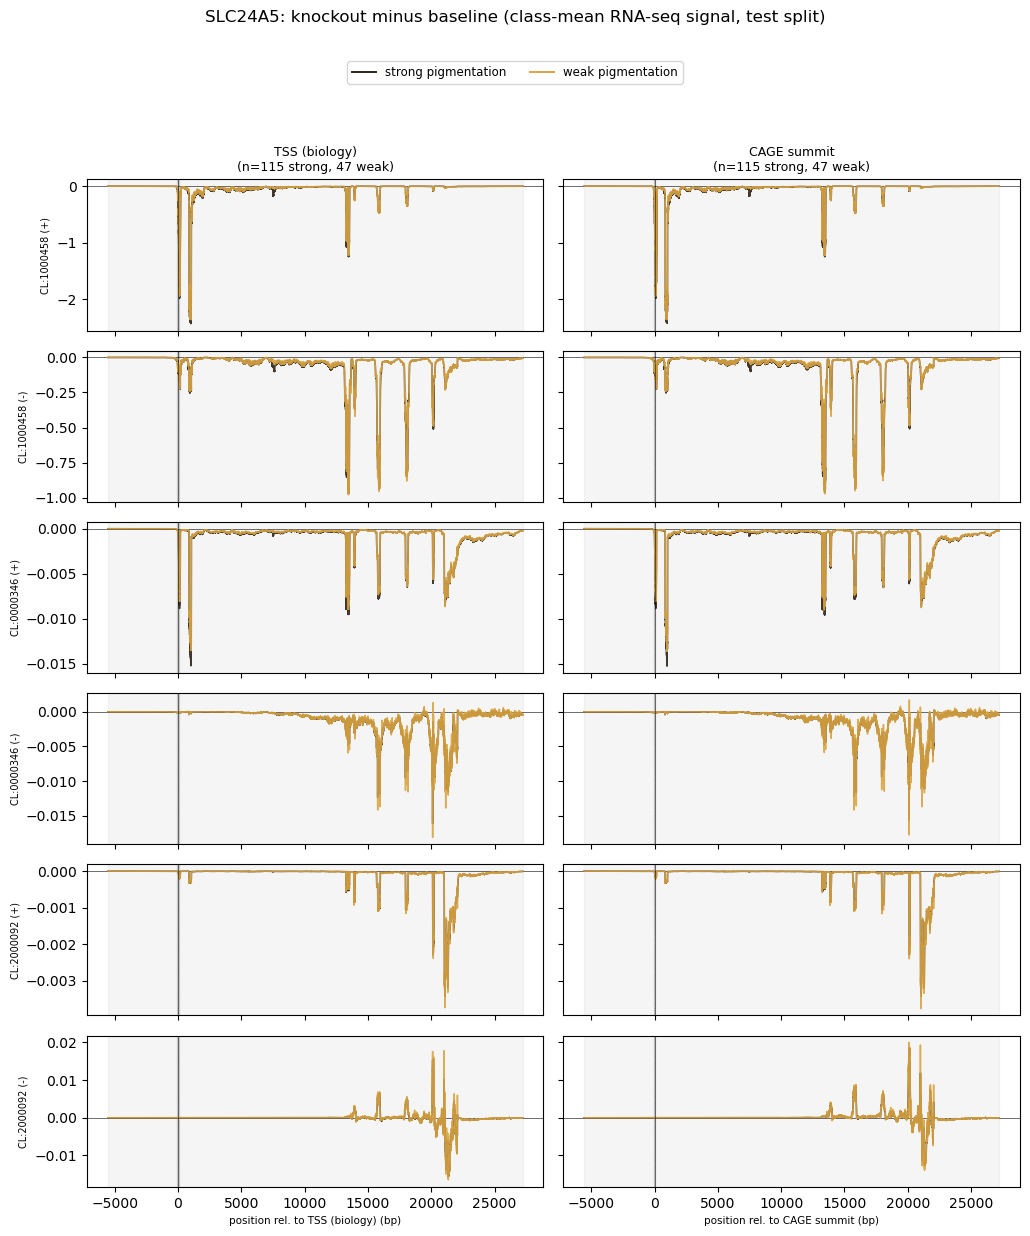

saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/class_mean_signal_SLC24A5_delta.png


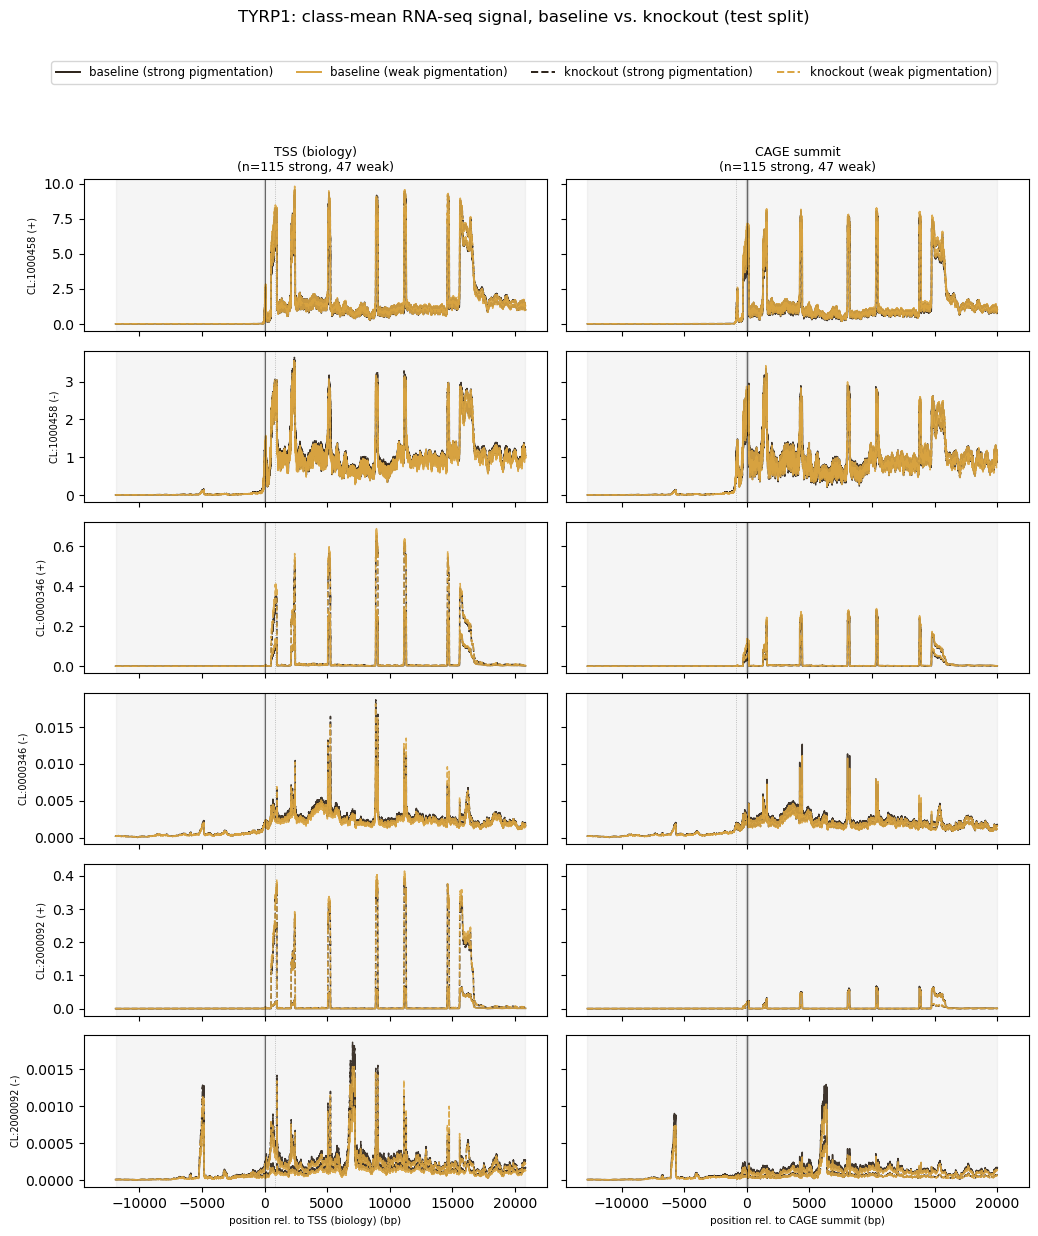

saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/class_mean_signal_TYRP1.png


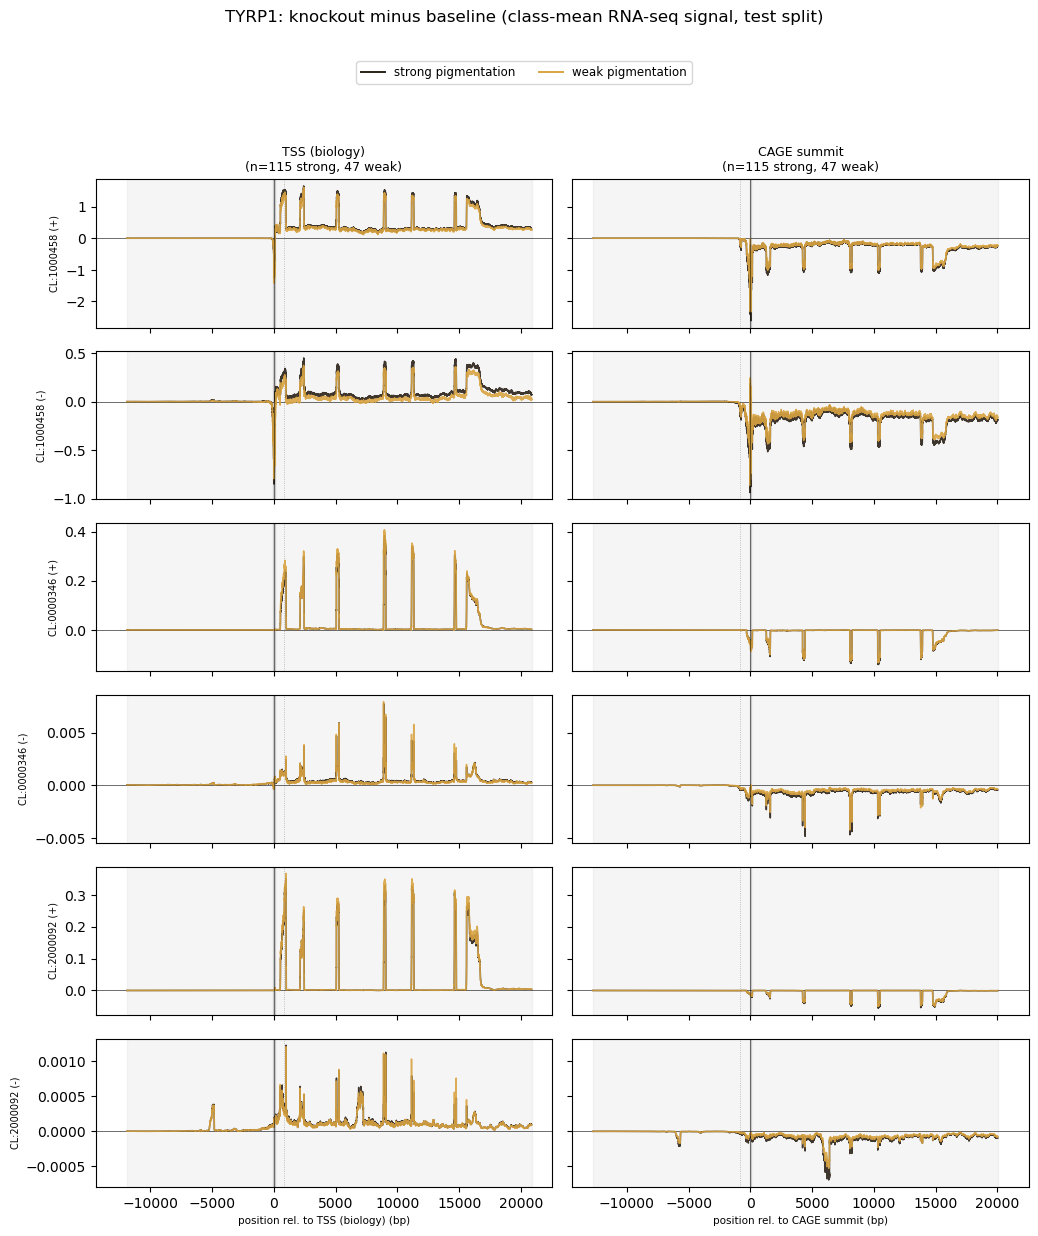

saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/class_mean_signal_TYRP1_delta.png


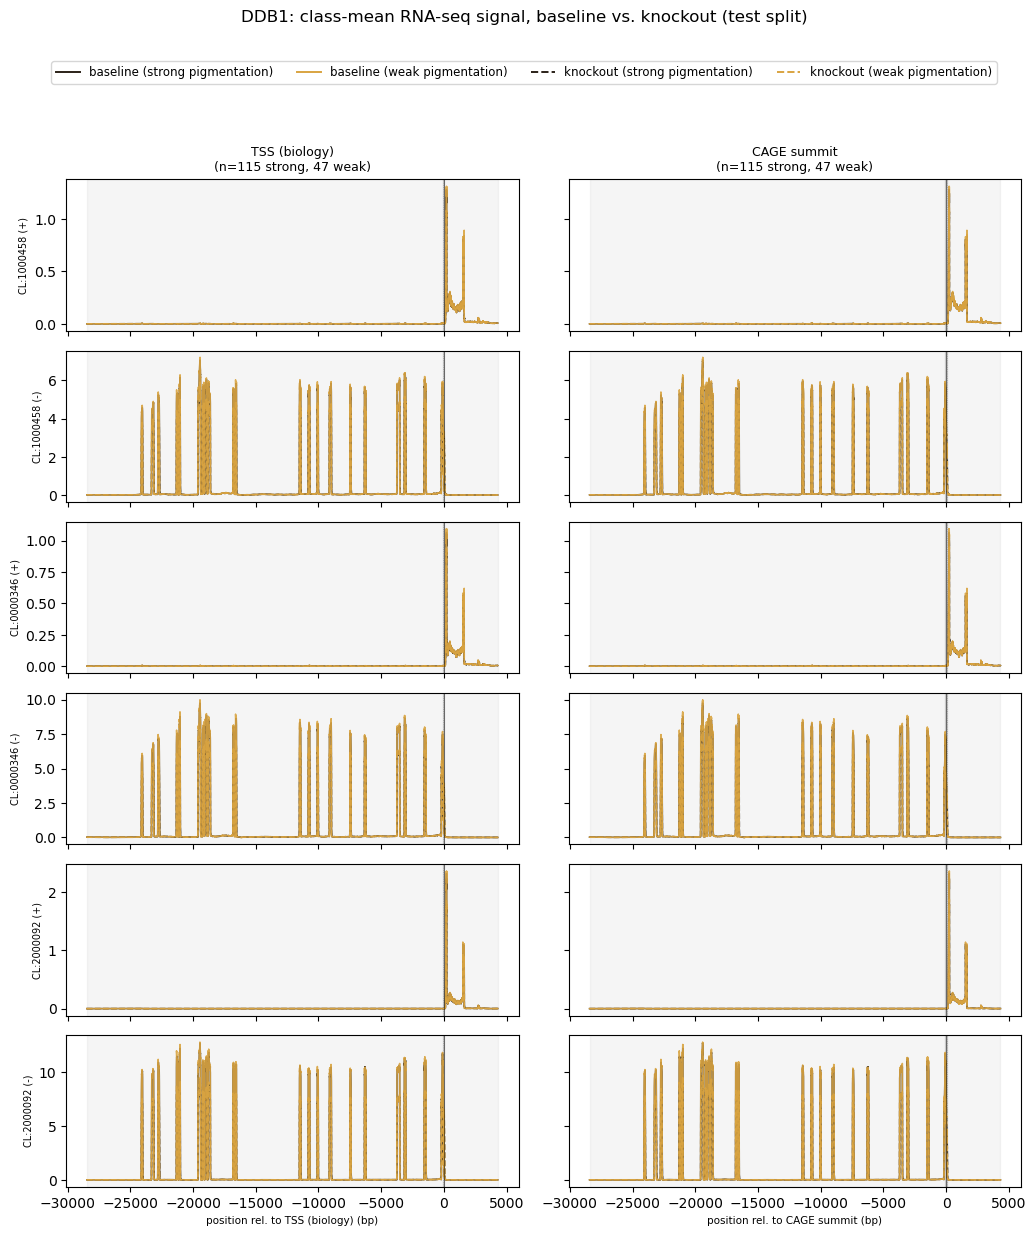

saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/class_mean_signal_DDB1.png


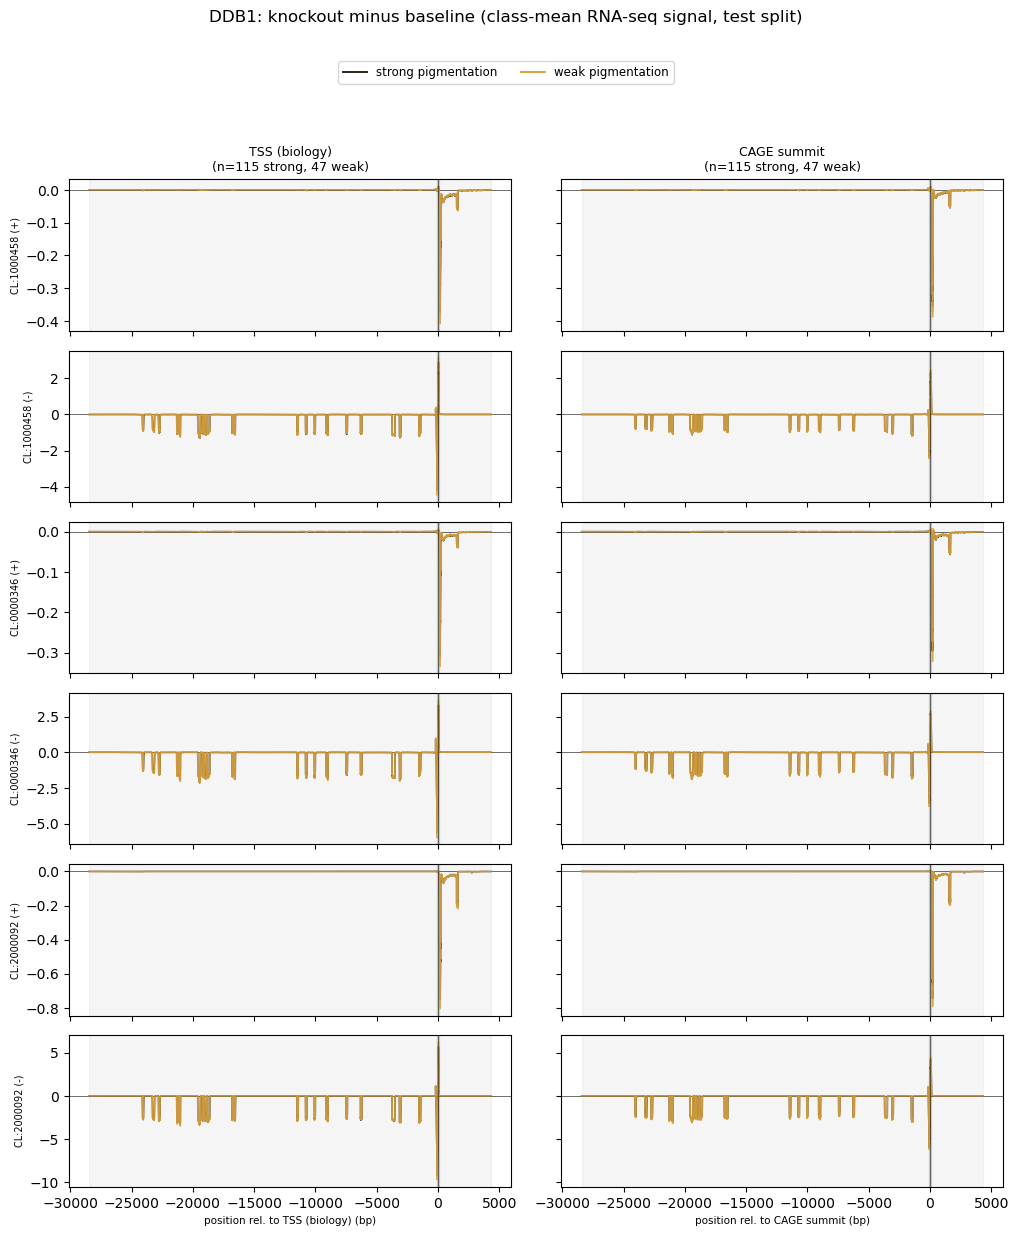

saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/class_mean_signal_DDB1_delta.png


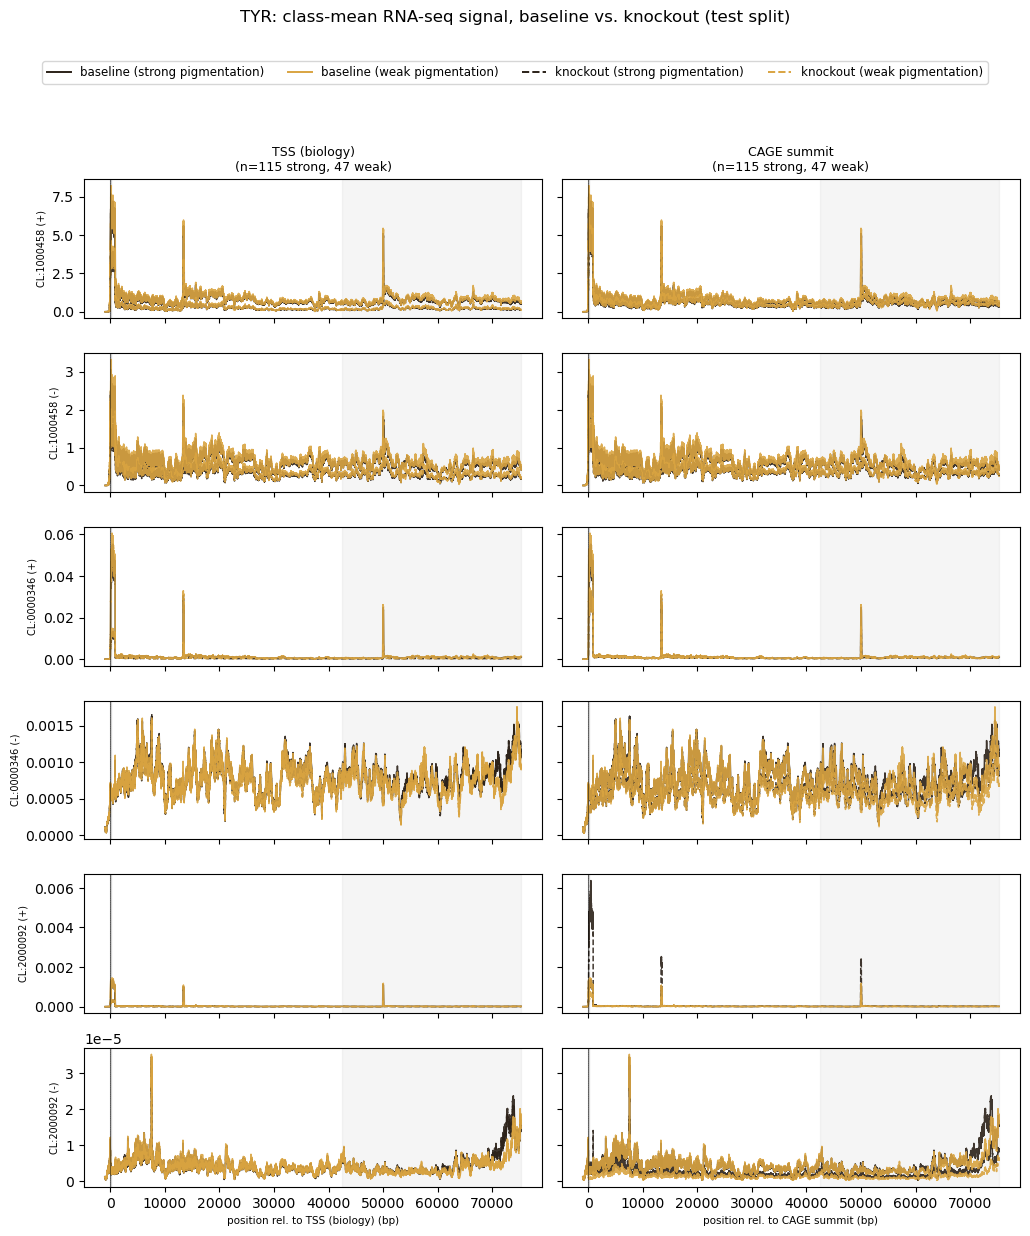

saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/class_mean_signal_TYR.png


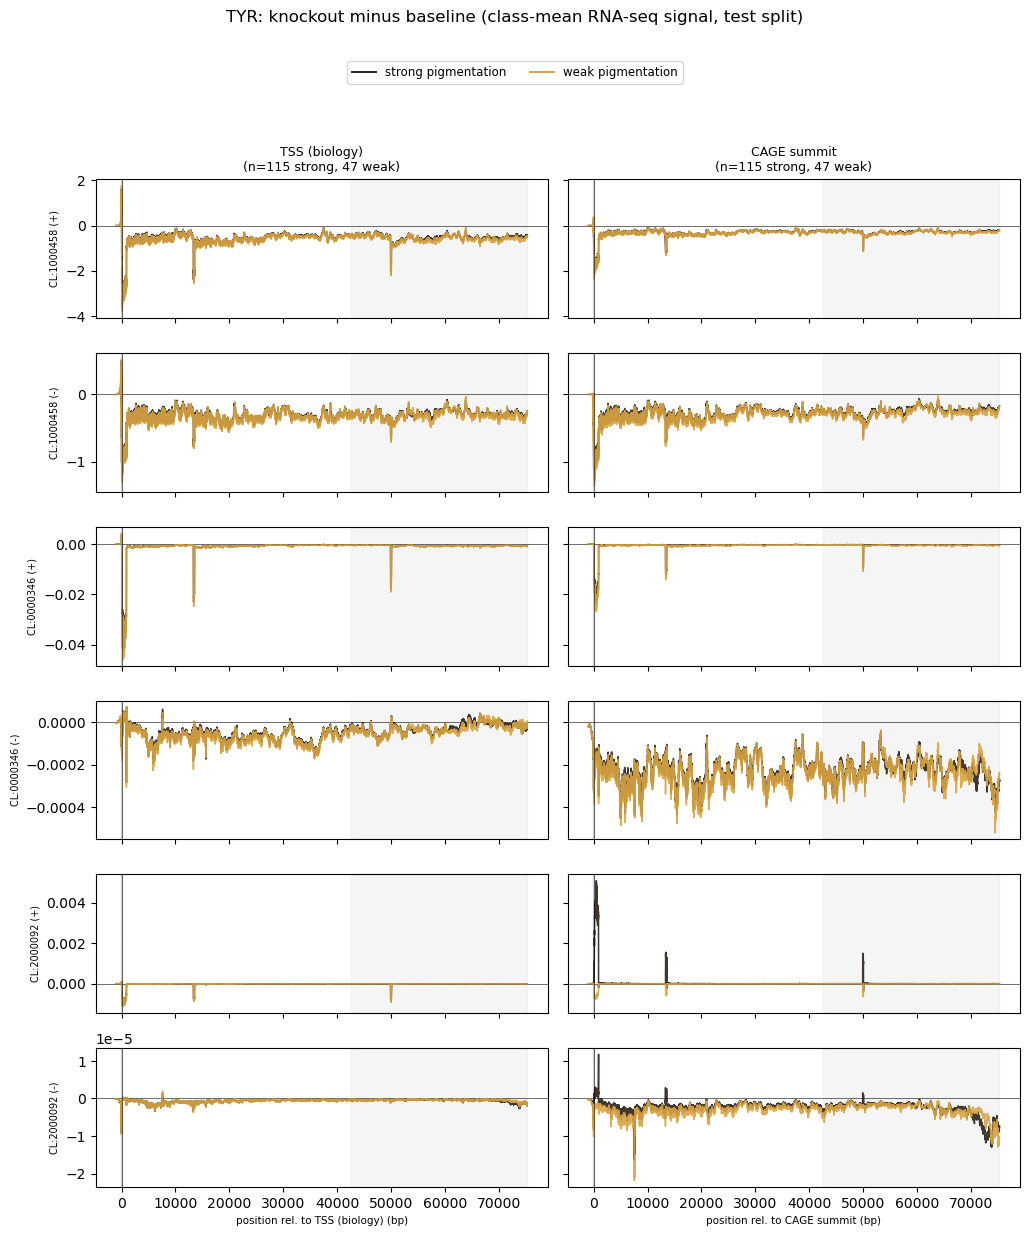

saved /home/breno/I2CA/genomics/notebooks/.cache/genotype_cnn_alignment_deeplift/class_mean_signal_TYR_delta.png


In [103]:
def _class_mean_signal_grid(gene, data, methods, value_fn, title, out_suffix, legend_handles):
    win_lo, win_span = data["win_lo"], data["win_span"]
    crop_lo, crop_hi = data["crop_lo"], data["crop_hi"]
    ref_idx_by_method = data["ref_idx_by_method"]

    n_tracks = len(GLOBAL_TRACK_LABELS)
    fig, axes = plt.subplots(
        n_tracks, len(methods), figsize=(5.2 * len(methods), 1.9 * n_tracks), sharex=True, sharey="row",
    )
    for col, method in enumerate(methods):
        by_method = data["by_method"][method]
        target = ref_idx_by_method[method]
        x = np.arange(win_span) - (target - win_lo)
        for row in range(n_tracks):
            ax = axes[row, col]
            ax.axvspan(crop_lo - target, crop_hi - target, color="gray", alpha=0.08, zorder=0)
            ax.axvspan(-SCRAMBLE_WINDOW / 2, SCRAMBLE_WINDOW / 2, color="black", alpha=0.12, zorder=0)
            for other_method, other_idx in ref_idx_by_method.items():
                if other_method != method:
                    ax.axvline(other_idx - target, color="gray", linewidth=0.6, linestyle=":", alpha=0.6)
            for label, color in TRUE_LABEL_COLORS.items():
                base_curve = by_method["mean_baseline"].get(label)
                mod_curve = by_method["mean_perturbed"].get(label)
                if base_curve is None:
                    continue
                value_fn(ax, x, base_curve[:, row], mod_curve[:, row], color)
            ax.axvline(0, color="black", linewidth=0.7, alpha=0.5)
            if col == 0:
                ax.set_ylabel(GLOBAL_TRACK_LABELS[row], fontsize=7)
            if row == 0:
                n_strong = by_method["n_by_label"].get("strong pigmentation", 0)
                n_weak = by_method["n_by_label"].get("weak pigmentation", 0)
                ax.set_title(f"{METHOD_LABELS[method]}\n(n={n_strong} strong, {n_weak} weak)", fontsize=9)
            if row == n_tracks - 1:
                ax.set_xlabel(f"position rel. to {METHOD_LABELS[method]} (bp)", fontsize=7.5)

    fig.legend(handles=legend_handles, loc="upper center", ncol=len(legend_handles), bbox_to_anchor=(0.5, 1.04), fontsize=8.5)
    fig.suptitle(f"{gene}: {title}", y=1.08)
    fig.tight_layout()
    out_path = KNOCKOUT_FIG_DIR / f"class_mean_signal_{gene}{out_suffix}.png"
    fig.savefig(out_path, dpi=140, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"saved {out_path}")


def plot_class_mean_signal(gene, methods=BULK_METHODS, marker_margin=1000):
    '''Renders both views for one gene from a single data collection pass: (1) overview -- solid
    baseline / dashed knockout, absolute signal, full plotted span (group differences visible,
    knockout itself not); (2) delta -- knockout-minus-baseline, y-axis autoscaled (isolates the
    localized knockout effect). See Section 11 markdown for why both are needed.'''
    data = collect_gene_class_mean_signal(gene, methods, marker_margin=marker_margin)
    if data["n_skipped"]:
        print(f"{gene}: skipped {data['n_skipped']} individuals (marker window ran off the edge of the raw prediction)")

    def _overview(ax, x, base, mod, color):
        ax.plot(x, base, color=color, linewidth=1.1, alpha=0.9, linestyle="-")
        ax.plot(x, mod, color=color, linewidth=1.1, alpha=0.9, linestyle="--")

    overview_handles = (
        [plt.Line2D([], [], color=c, lw=1.4, linestyle="-", label=f"baseline ({l})") for l, c in TRUE_LABEL_COLORS.items()]
        + [plt.Line2D([], [], color=c, lw=1.4, linestyle="--", label=f"knockout ({l})") for l, c in TRUE_LABEL_COLORS.items()]
    )
    _class_mean_signal_grid(
        gene, data, methods, _overview,
        "class-mean RNA-seq signal, baseline vs. knockout (test split)", "", overview_handles,
    )

    def _delta(ax, x, base, mod, color):
        ax.axhline(0, color="black", linewidth=0.6, alpha=0.4)
        ax.plot(x, mod - base, color=color, linewidth=1.1, alpha=0.9)

    delta_handles = [plt.Line2D([], [], color=c, lw=1.4, label=l) for l, c in TRUE_LABEL_COLORS.items()]
    _class_mean_signal_grid(
        gene, data, methods, _delta,
        "knockout minus baseline (class-mean RNA-seq signal, test split)", "_delta", delta_handles,
    )


for gene in top_genes_detail:
    plot_class_mean_signal(gene)
